In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL, seasonal_decompose

In [4]:
dfs = pd.read_csv("./data/5793-2022MayNov-Speed_lane.csv")
dfv = pd.read_csv("./data/5793-2022MayNov-vol_lane.csv")          #volume is flow in vehicles per 2 min

In [5]:
detector = "AID01101_lane1"

# dfs.loc[:,'Time'] = dfs['Time'].str.strip()
dfs.loc[:,'Time'] = pd.to_datetime(dfs['Time'], errors='coerce')
dfs.set_index("Time",inplace=True)

dfv.loc[:,'Time'] = pd.to_datetime(dfv['Time'], errors='coerce')
dfv.set_index("Time",inplace=True)



c:\PROGRAM FILES\PYTHON311\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
c:\PROGRAM FILES\PYTHON311\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [6]:
# Create dfk by multiplying dfv by 30 and then dividing by dfs
dfk = 30 * dfv / dfs

# Replace infinity values with NaN
dfk.replace([float('inf'), float('-inf')], float('nan'), inplace=True)

# Display the new DataFrame dfk
print(dfk)

                     AID01101_lane1  AID01101_lane2  AID01101_lane3  \
Time                                                                  
2022-05-01 00:00:00        1.134459        3.638632        1.666667   
2022-05-01 00:02:00        2.727273        3.713733        3.378378   
2022-05-01 00:04:00        0.441176        4.487049        1.395349   
2022-05-01 00:06:00        2.842120        4.090909        2.909091   
2022-05-01 00:08:00        2.307692        5.178339        0.476190   
...                             ...             ...             ...   
2022-11-30 23:50:00        1.975309        2.873563        3.478261   
2022-11-30 23:52:00        3.609023        5.990089        0.991736   
2022-11-30 23:54:00        1.000000        4.615385        1.363636   
2022-11-30 23:56:00        1.516862        4.362649        0.833333   
2022-11-30 23:58:00        1.356791        5.203415        2.580645   

                     AID01102_lane1  AID01102_lane2  AID01102_lane3  \
Time 

# Self Detector Analysis

In [7]:
def plot_timeseries(df, detector, type):
    plt.figure(figsize=(12, 6))  # Set the figure size
    plt.plot(df.index, df[detector], label='Value', color='blue')  # Plot the time series data
    
    # Calculate the mean value
    mean_value = df[detector].mean()
    
    # Annotate the mean value on the plot
    plt.axhline(y=mean_value, color='red', linestyle='--', label=f'Mean: {mean_value:.2f}')
    
    plt.title('Time Series Plot of ' + type + ' for ' + detector)  # Set the title
    plt.xlabel('Timestamp')  # Set the x-axis label
    plt.ylabel(type)  # Set the y-axis label
    plt.legend()  # Show the legend (if you have multiple lines on the plot)
    plt.grid(True)  # Add a grid
    plt.show()  # Display the plot

In [8]:
def plot_speed_vs_flow(speed_df, flow_df, column_name):
    plt.figure(figsize=(8, 6))  # Set the figure size
    plt.scatter(flow_df[column_name], speed_df[column_name], color='blue', alpha=0.5, s=5)  # Plot the scatter plot
    plt.title('Speed vs Flow Scatter Plot for ' + column_name)  # Set the title
    plt.xlabel('Flow')  # Set the x-axis label
    plt.ylabel('Speed')  # Set the y-axis label
    plt.grid(True)  # Add a grid
    plt.show()  # Display the plot

def plot_speed_vs_density(speed_df, density_df, column_name):
    plt.figure(figsize=(8, 6))  # Set the figure size
    plt.scatter(density_df[column_name], speed_df[column_name], color='blue', alpha=0.5, s=5)  # Plot the scatter plot
    plt.title('Speed vs Density Scatter Plot for '+column_name)  # Set the title
    plt.xlabel('Density')  # Set the x-axis label
    plt.ylabel('Speed')  # Set the y-axis label
    plt.grid(True)  # Add a grid
    plt.show()  # Display the plot

def plot_flow_vs_density(flow_df, density_df, column_name):
    plt.figure(figsize=(8, 6))  # Set the figure size
    plt.scatter(density_df[column_name], flow_df[column_name], color='blue', alpha=0.5, s=5)  # Plot the scatter plot
    plt.title('Flow vs Density Scatter Plot for '+column_name)  # Set the title
    plt.xlabel('Density')  # Set the x-axis label
    plt.ylabel('Flow')  # Set the y-axis label
    plt.grid(True)  # Add a grid
    plt.show()  # Display the plot

def plot_hist(df,detector, type):
  plt.figure(figsize=(12, 6))
  plt.hist(df[detector], bins=150 ,range = (0,160), edgecolor='black', color='skyblue')
  plt.title('Histogram of '+ type + ' for ' + detector)
  plt.xlabel(type)
  plt.ylabel('Frequency')

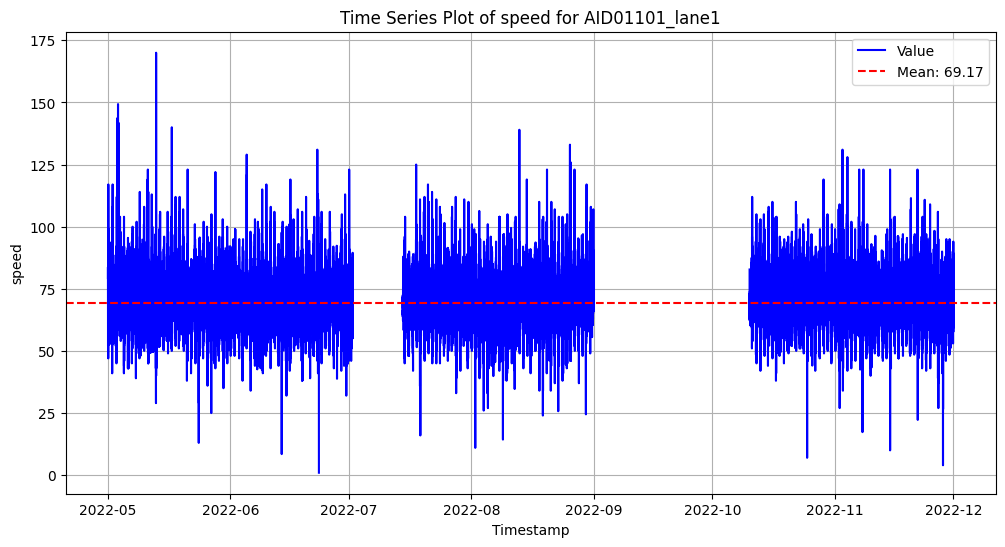

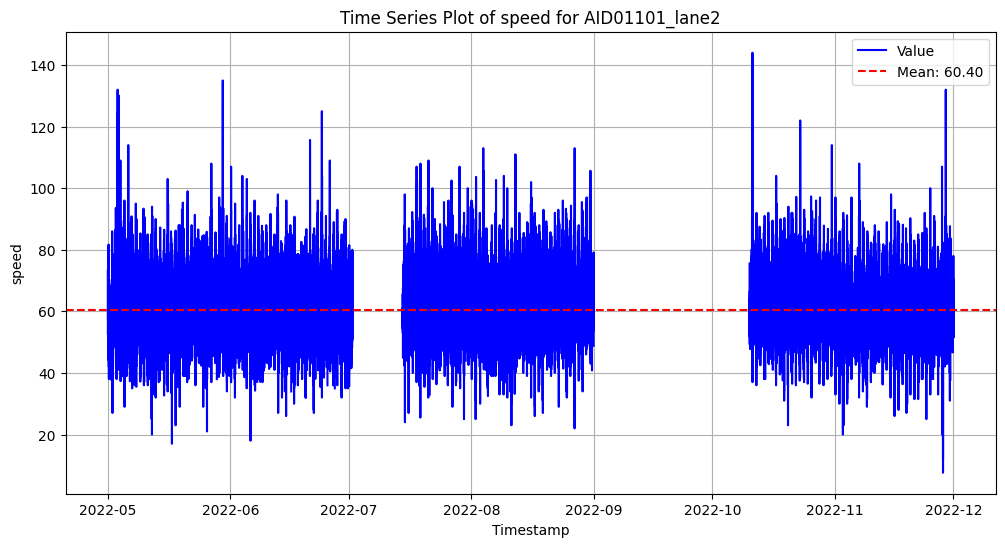

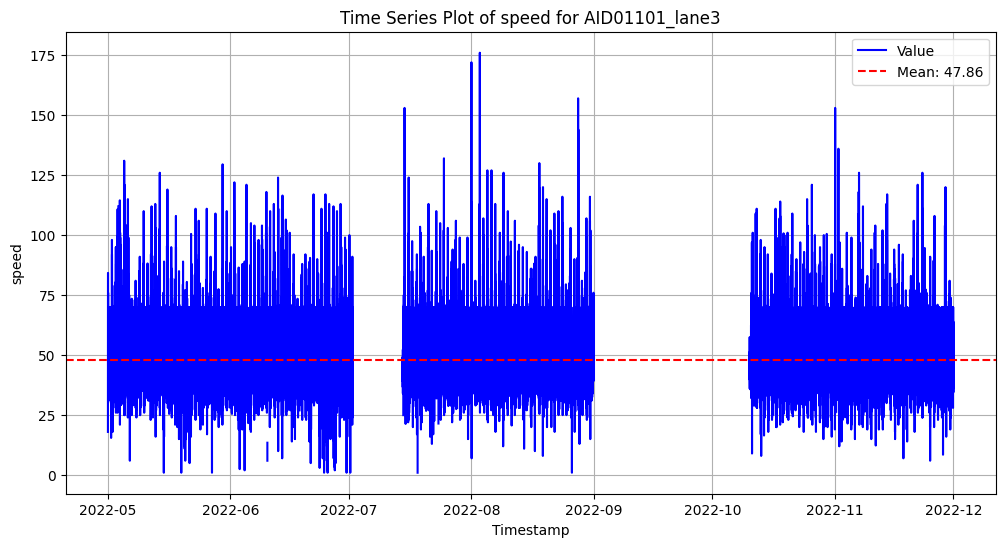

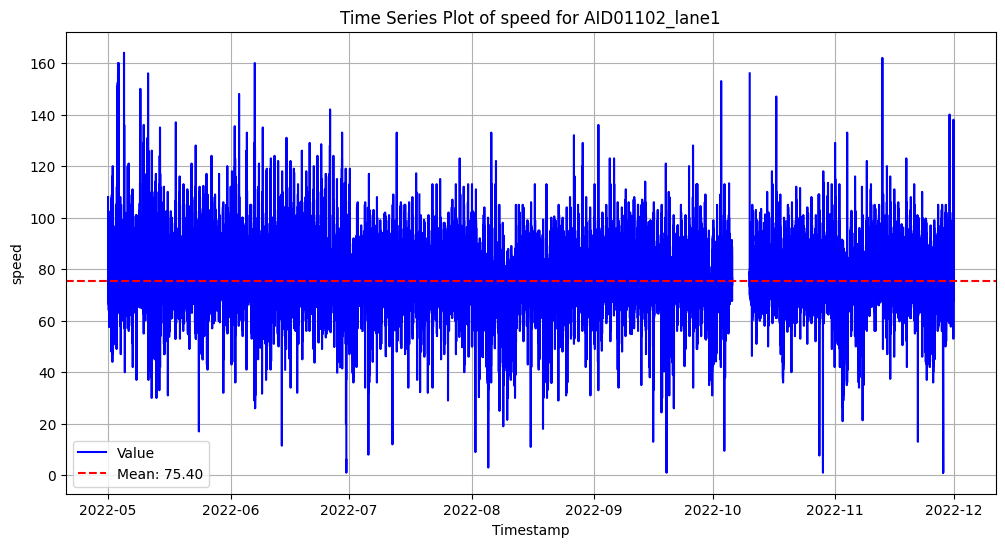

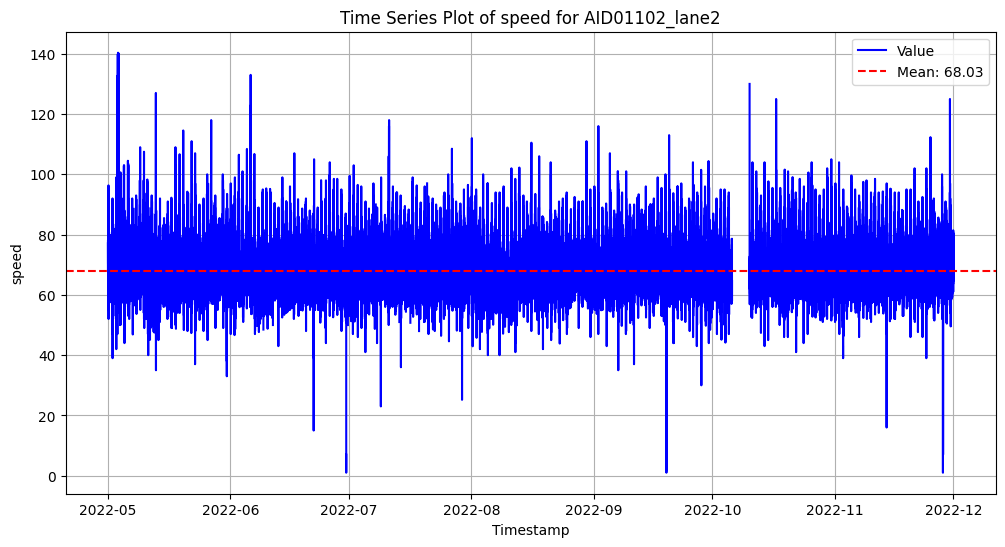

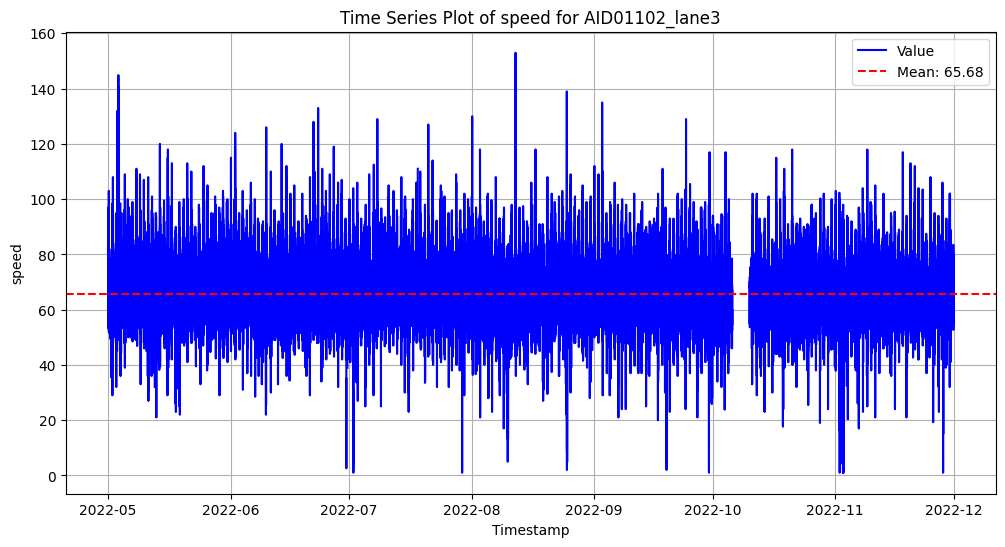

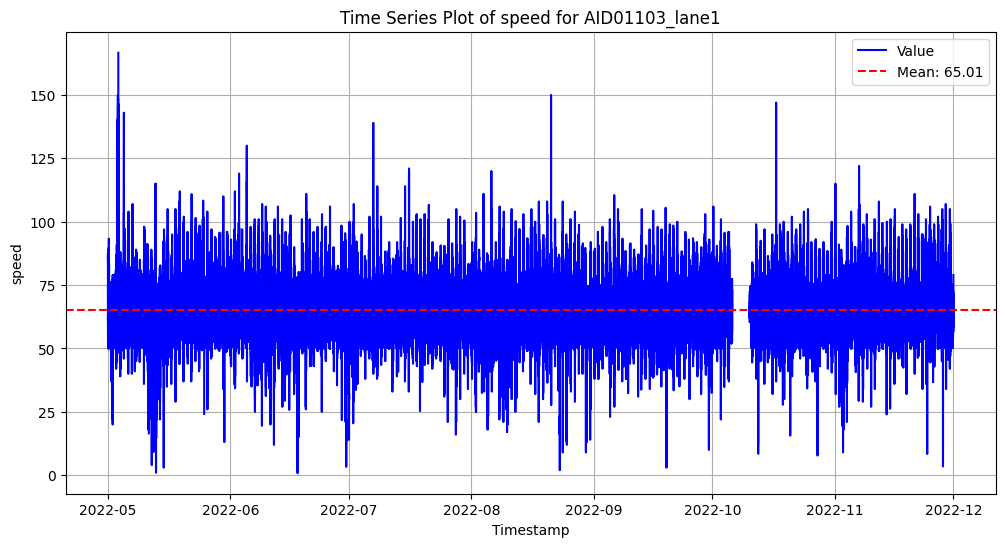

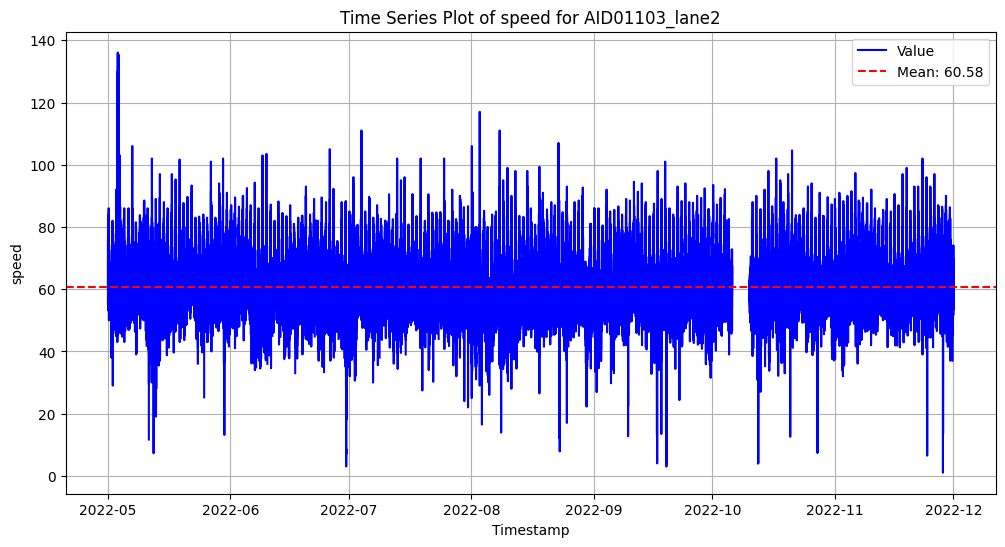

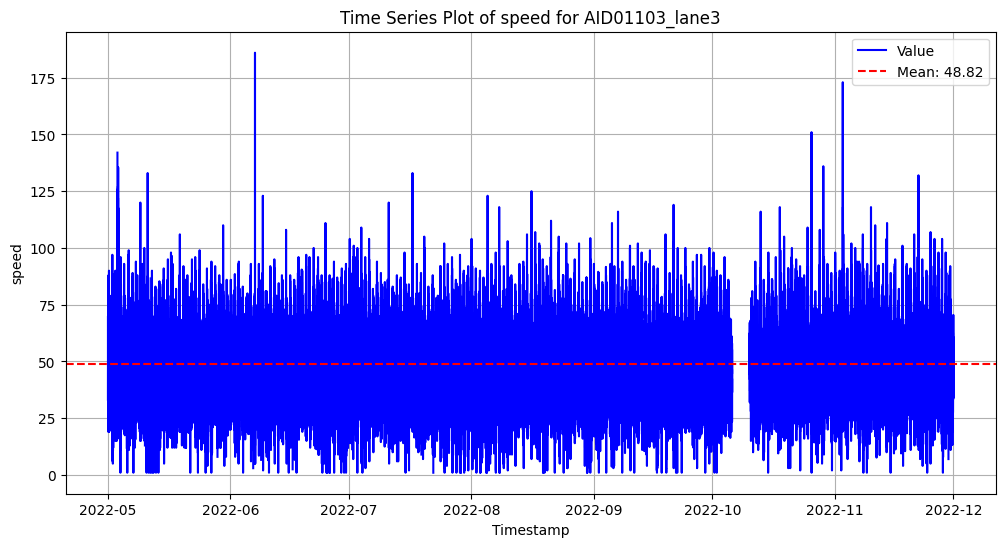

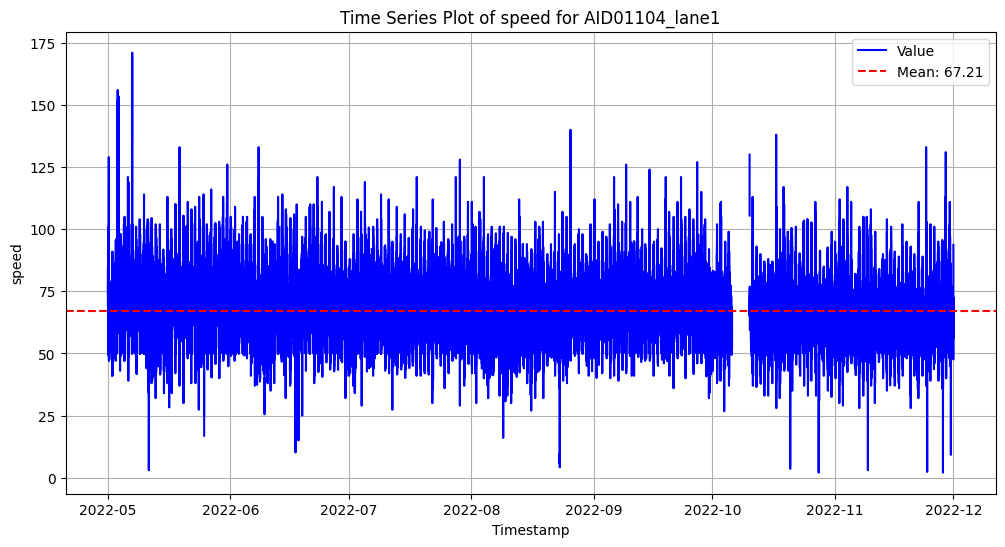

In [9]:
for i in range(10):
    plot_timeseries(dfs,dfs.columns[i],'speed')

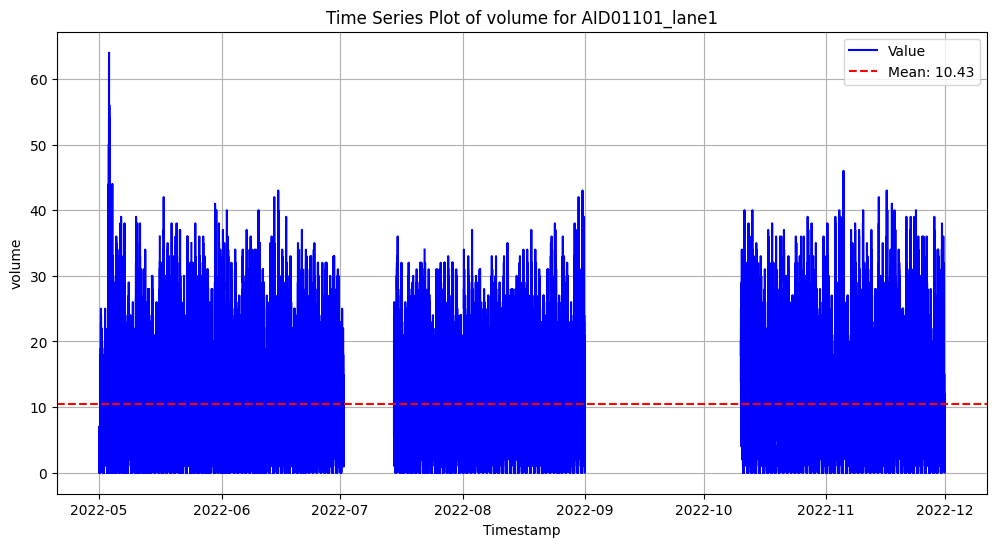

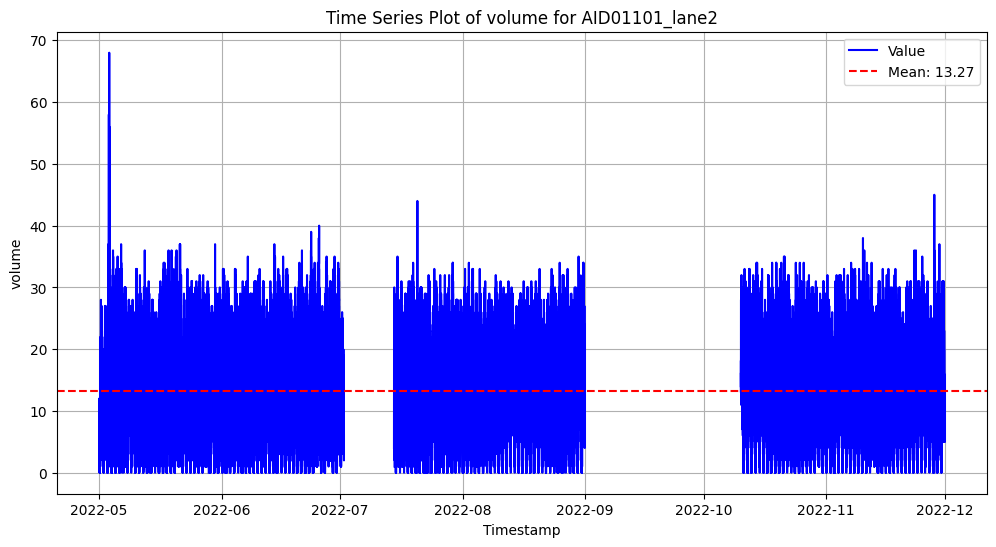

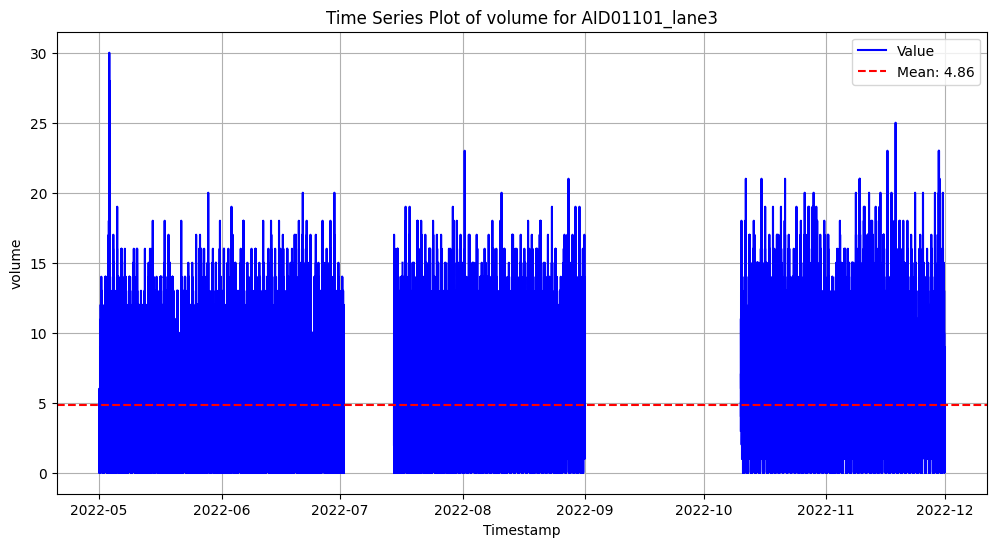

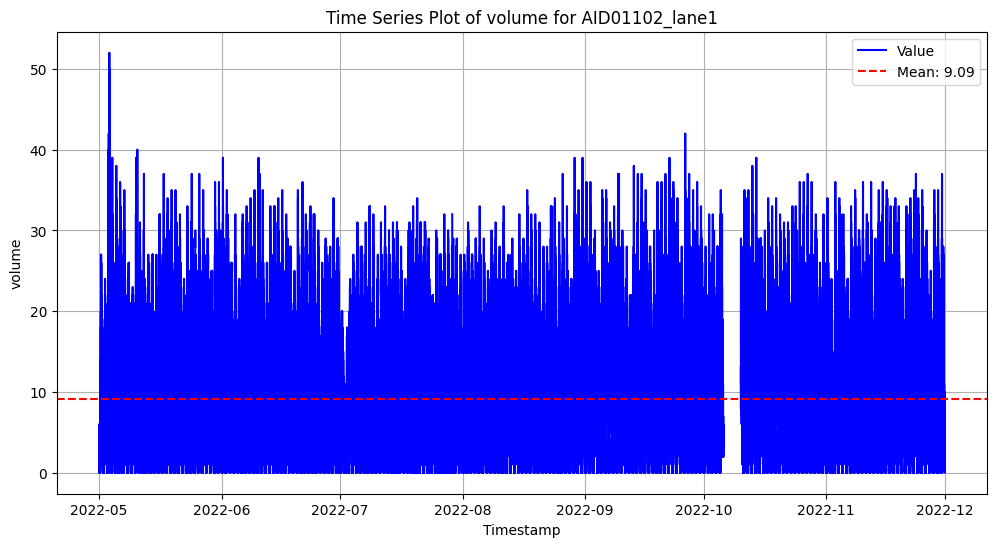

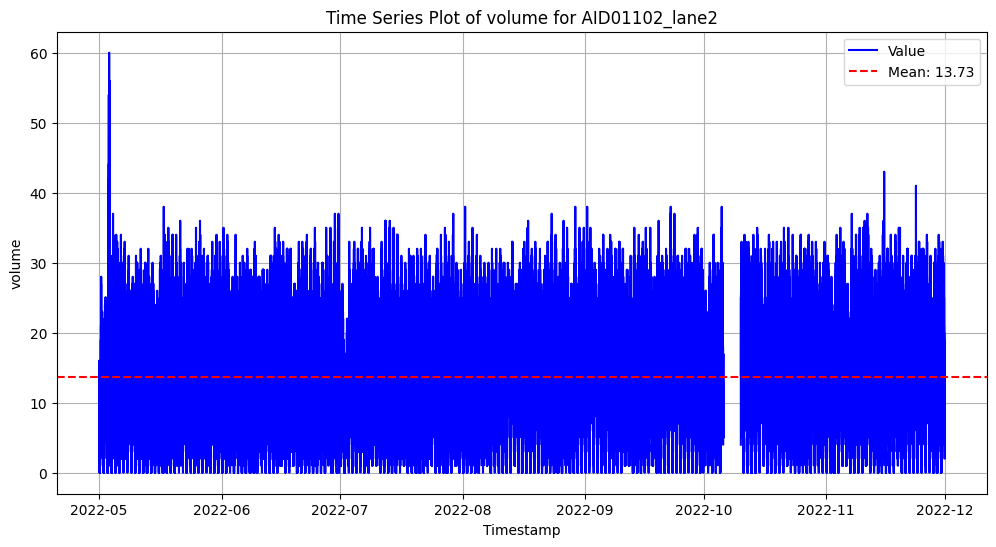

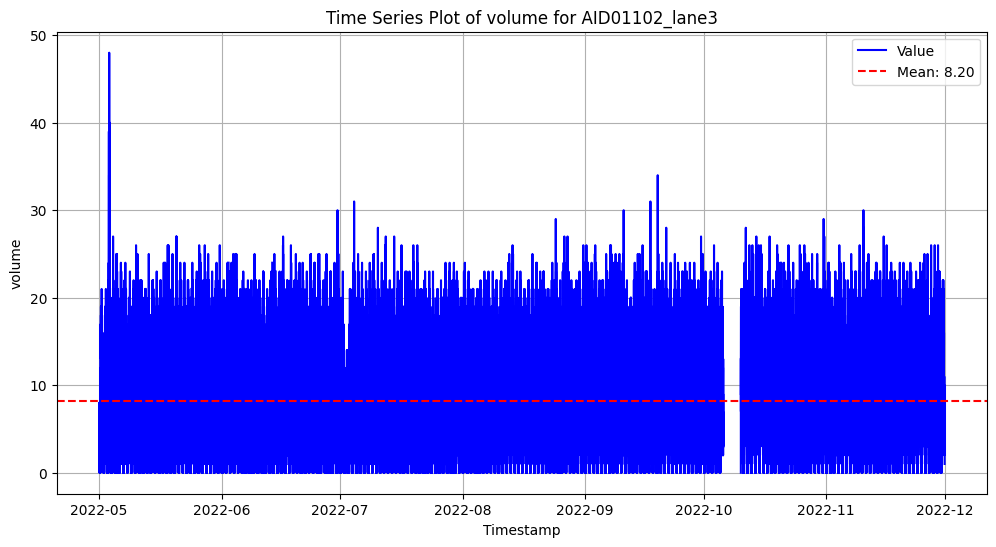

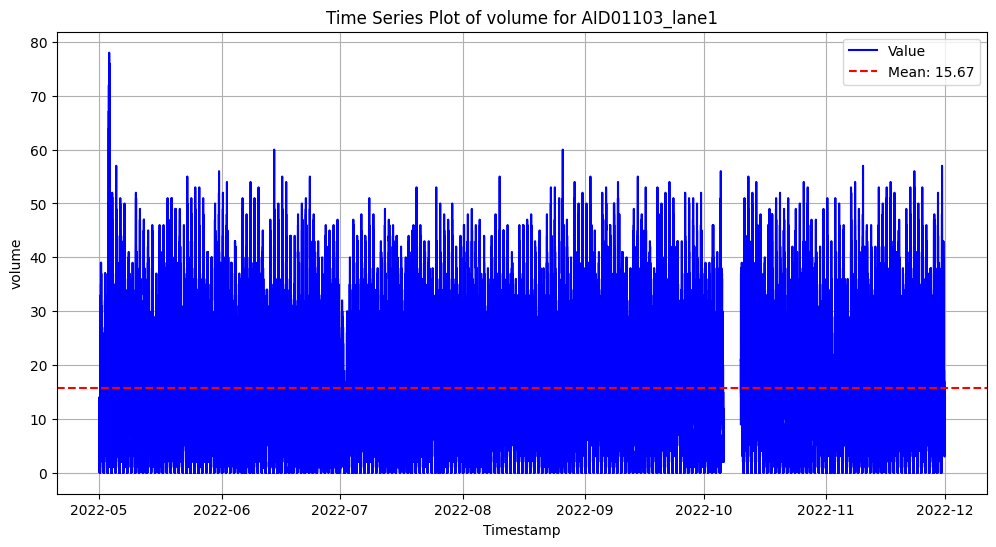

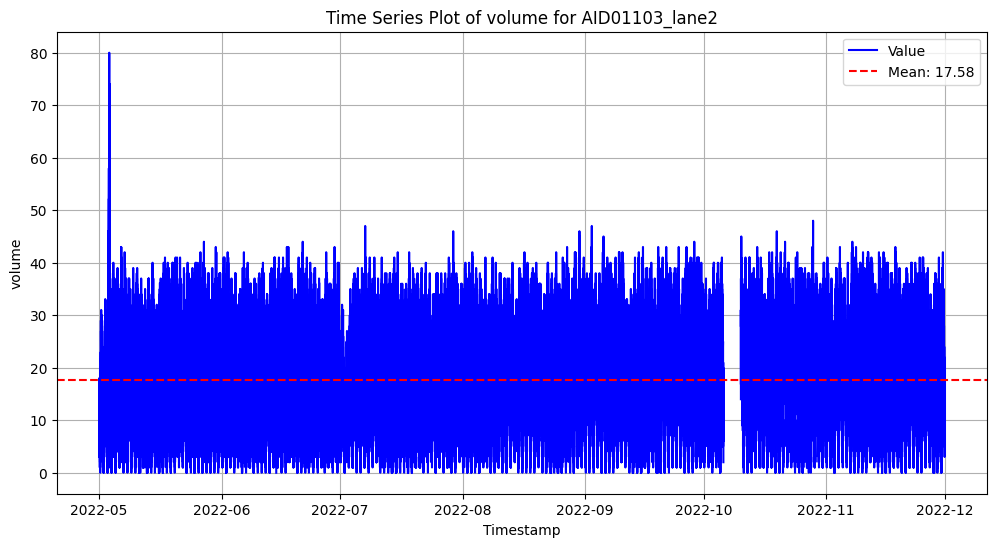

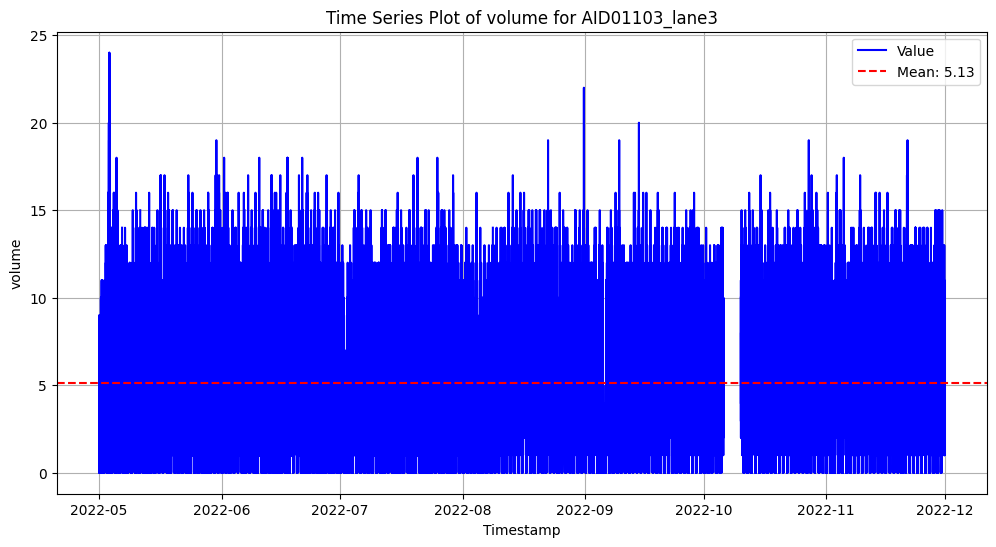

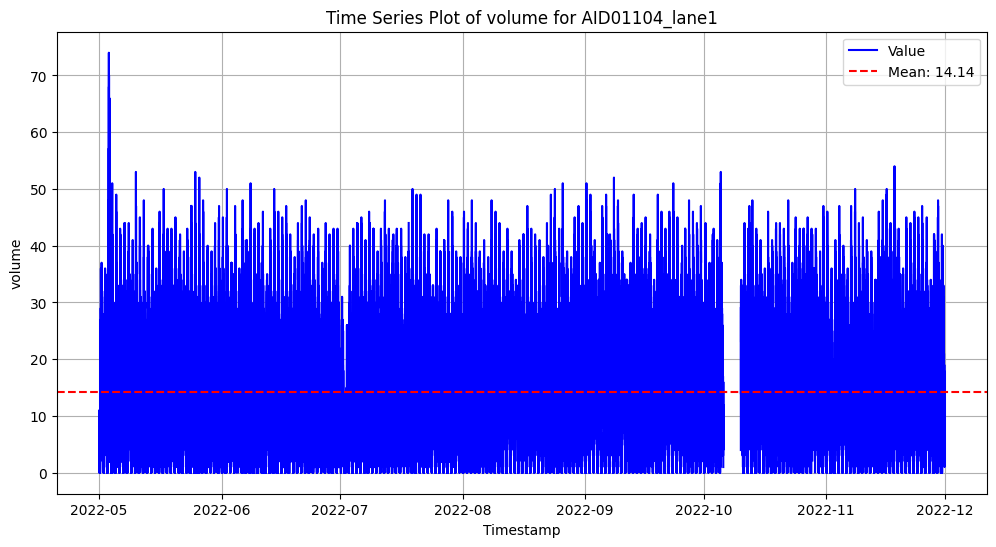

In [10]:
for i in range(10):
    plot_timeseries(dfv,dfv.columns[i],'volume')

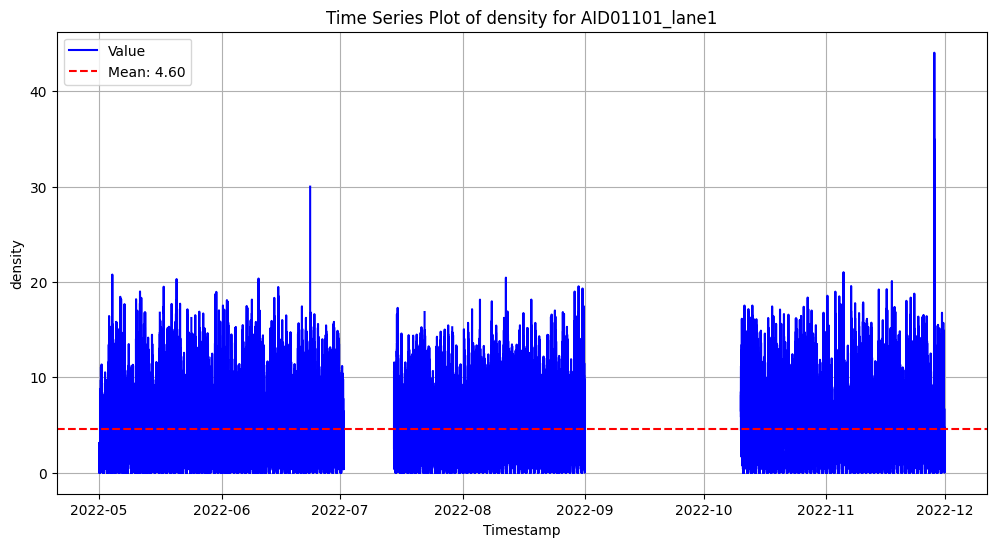

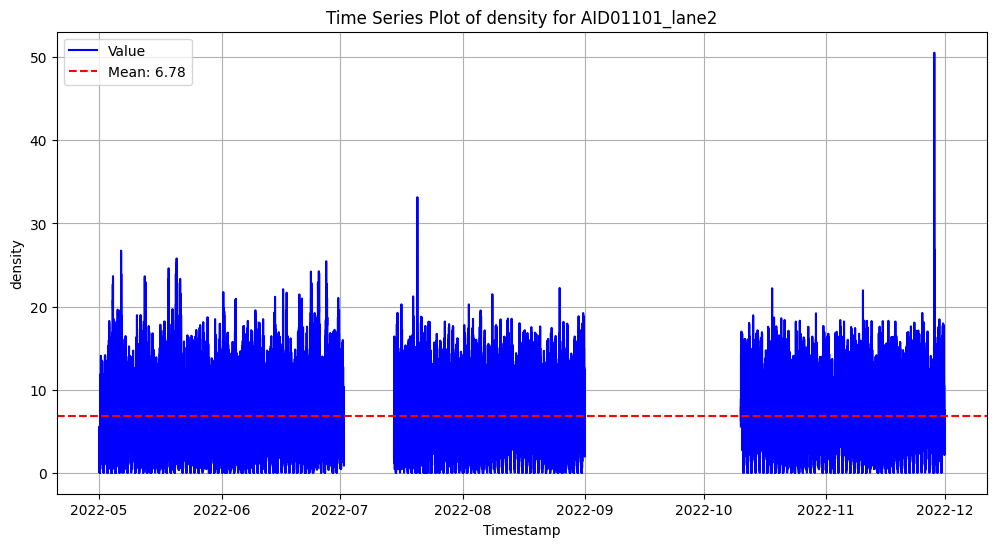

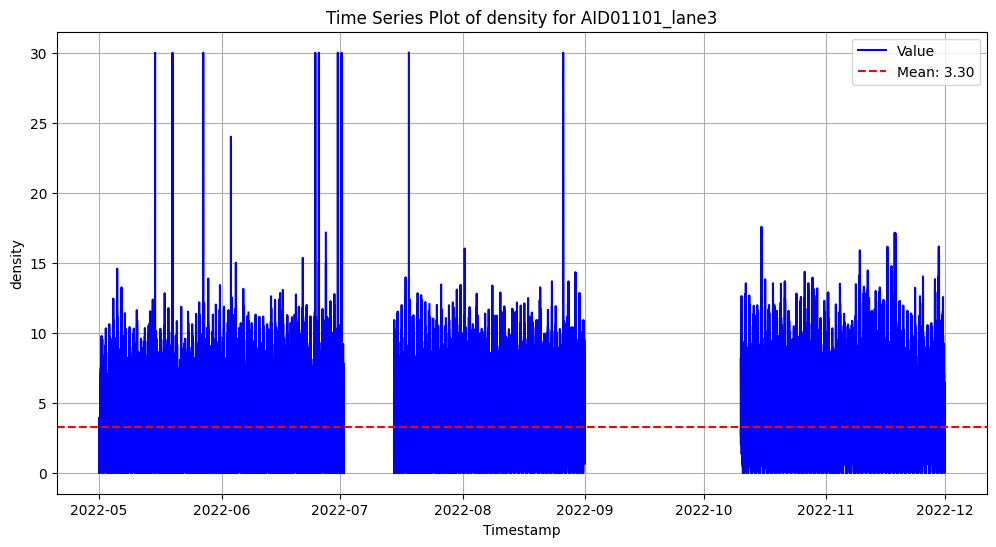

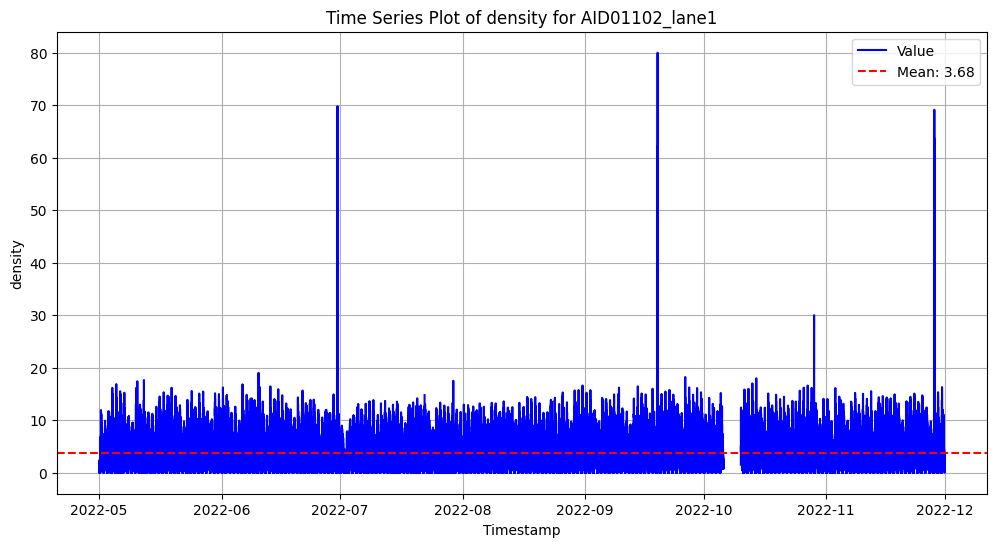

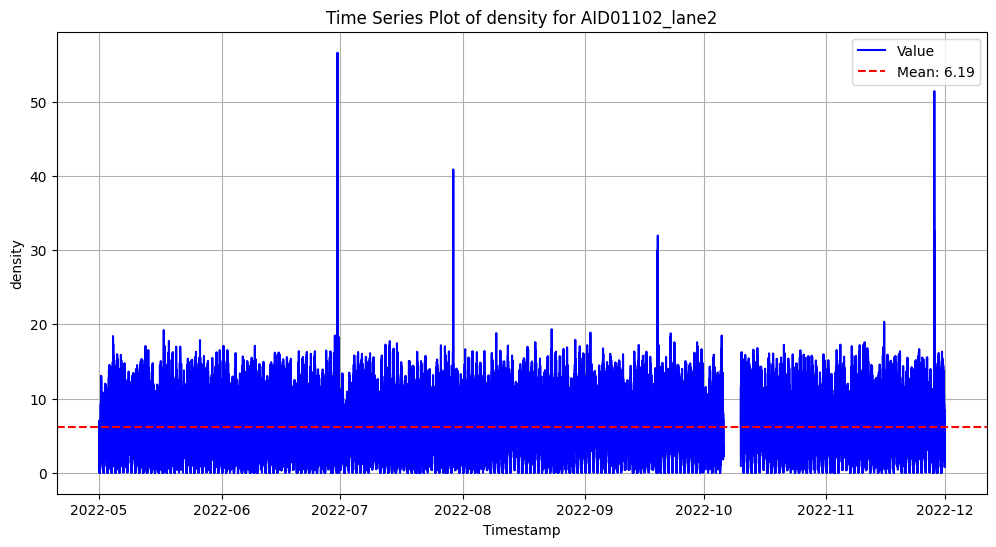

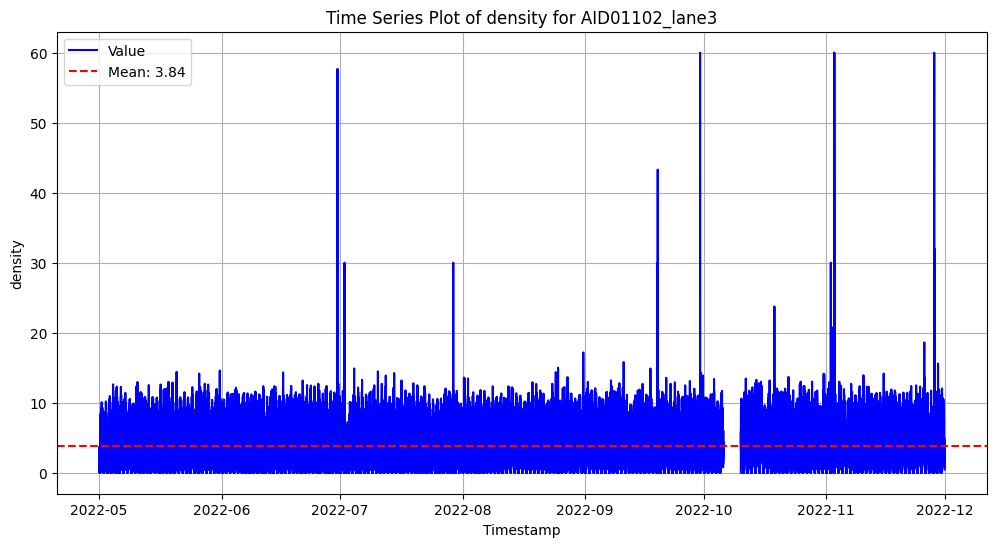

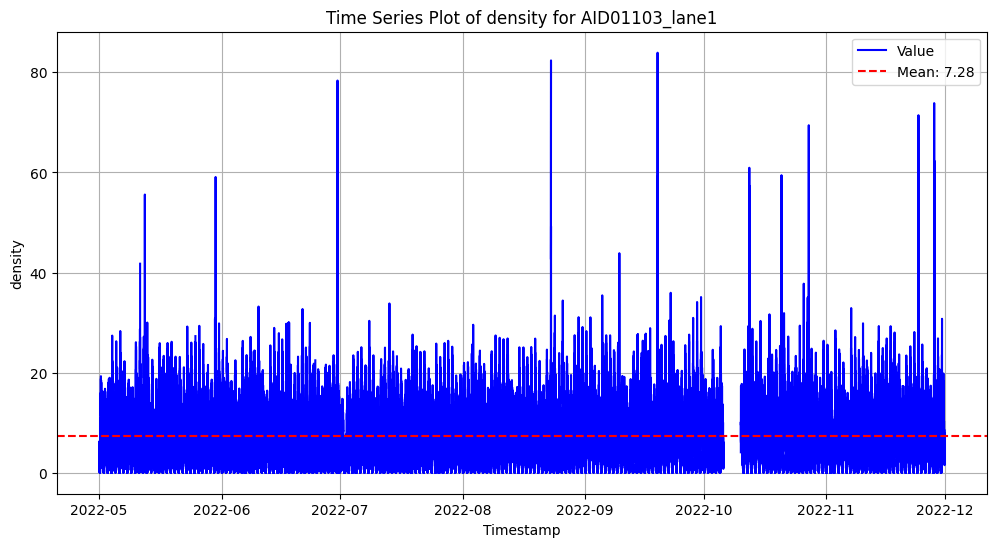

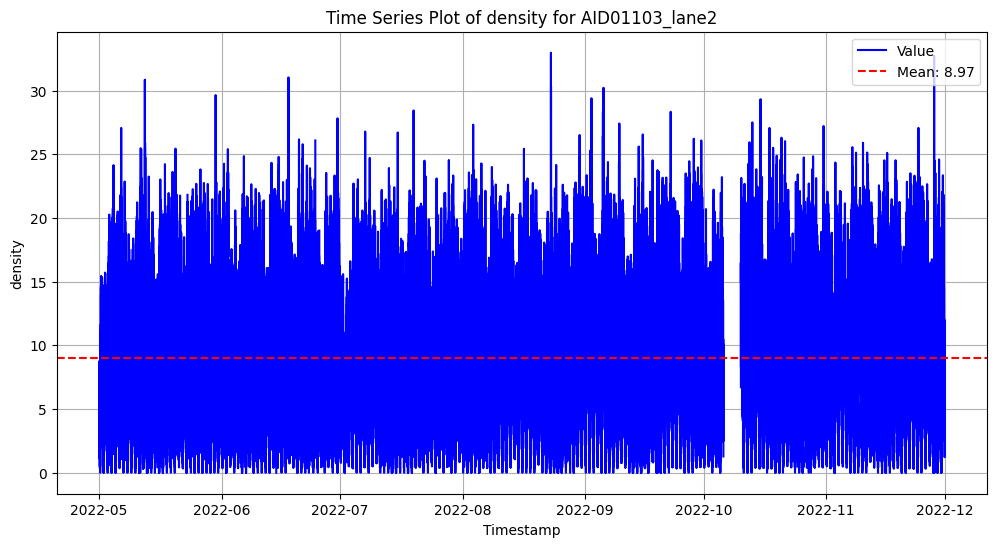

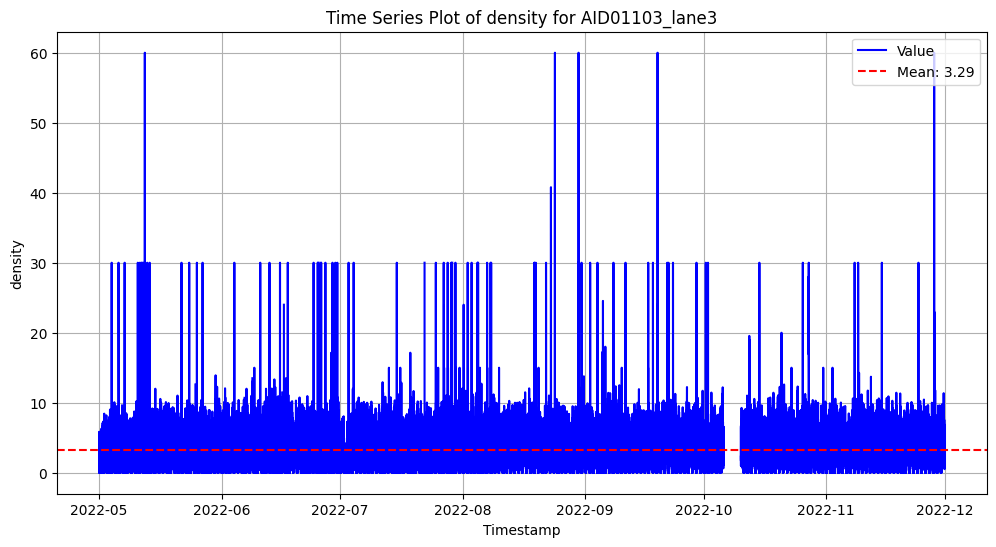

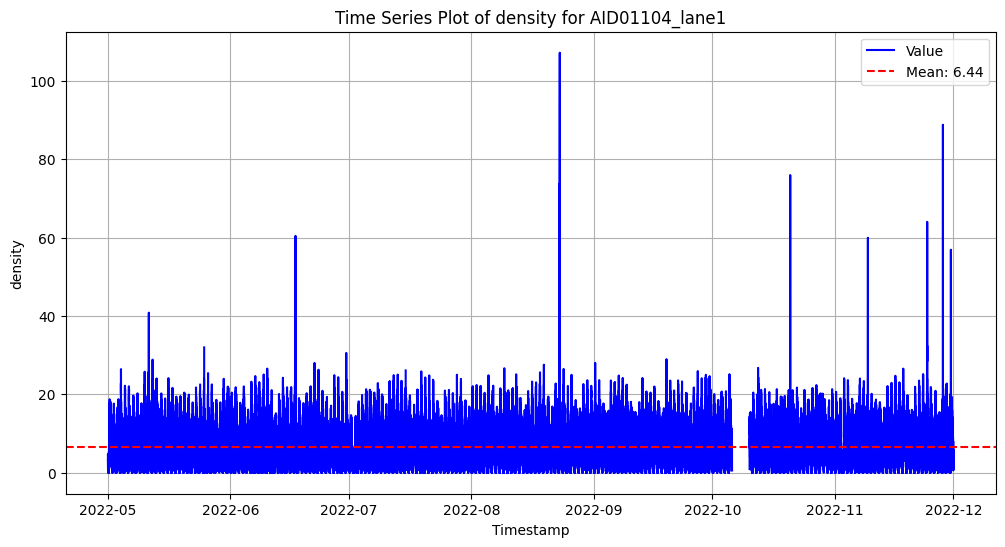

In [11]:
for i in range(10):
    plot_timeseries(dfk,dfk.columns[i],'density')

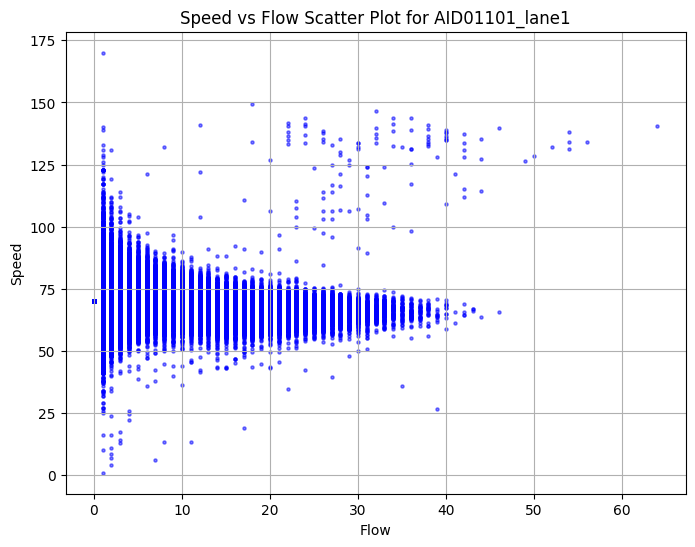

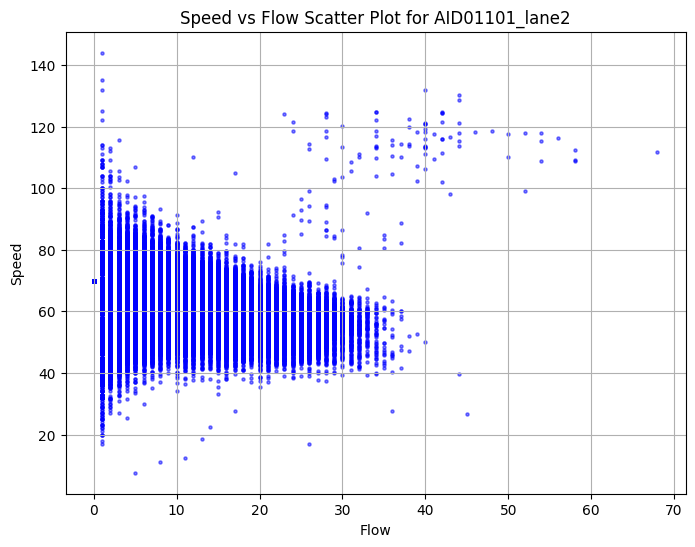

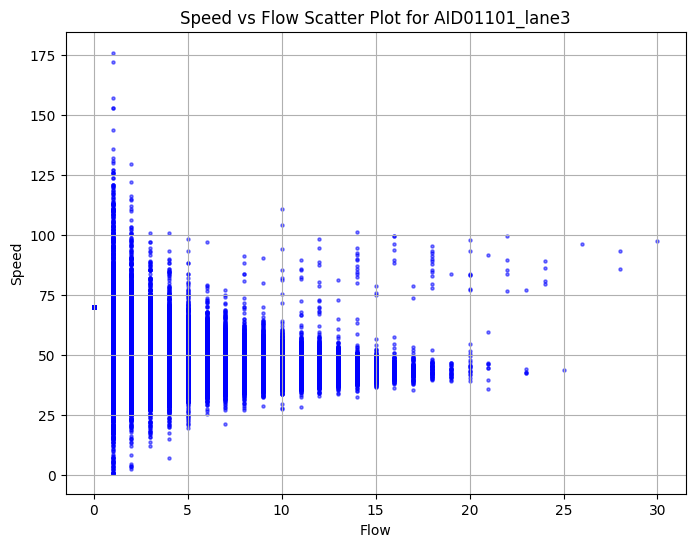

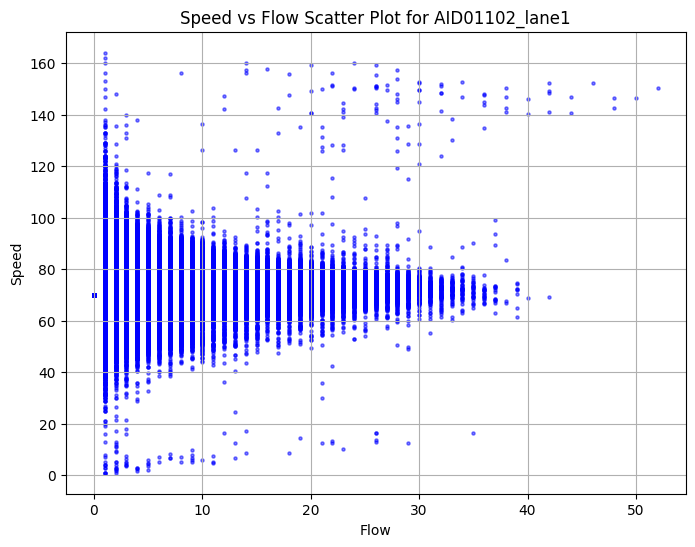

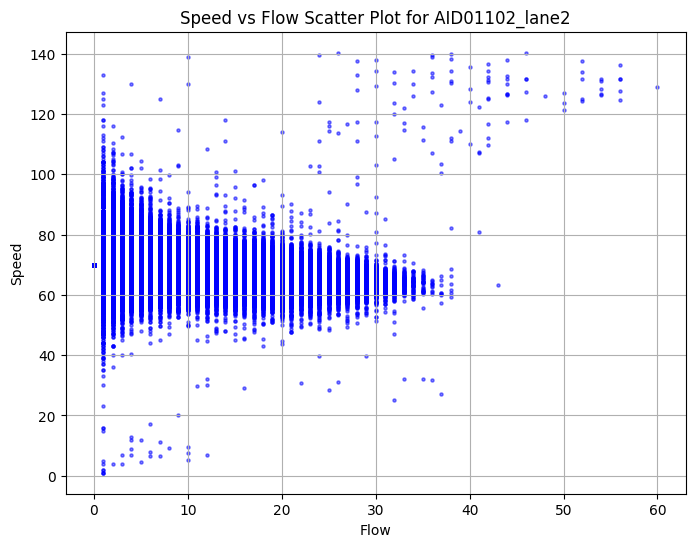

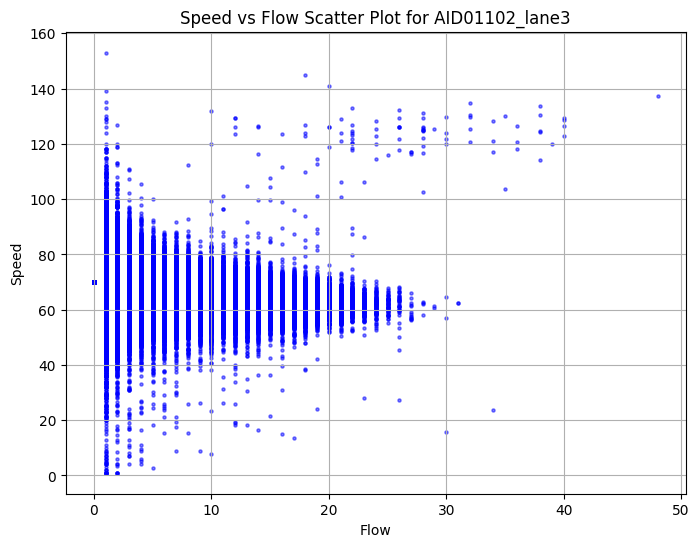

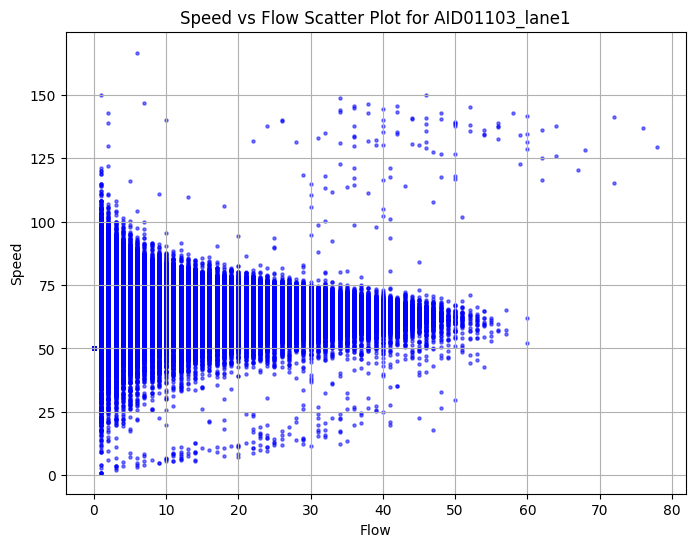

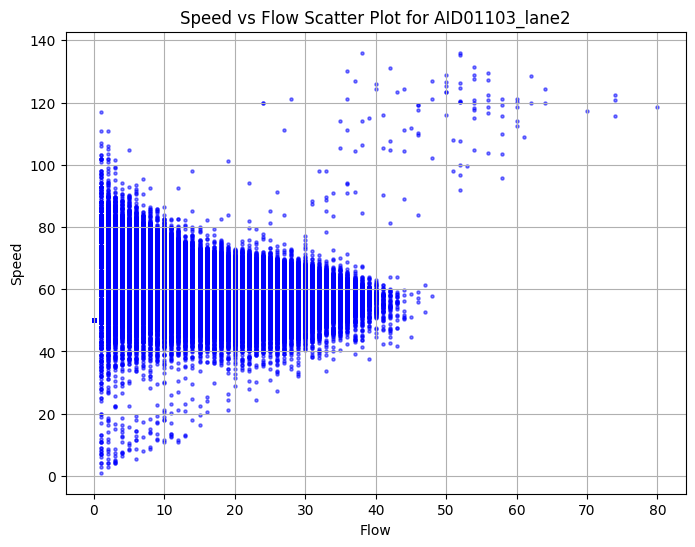

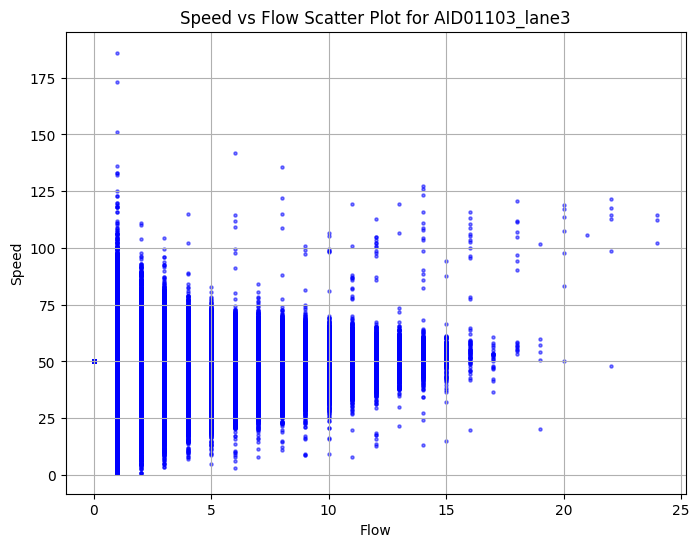

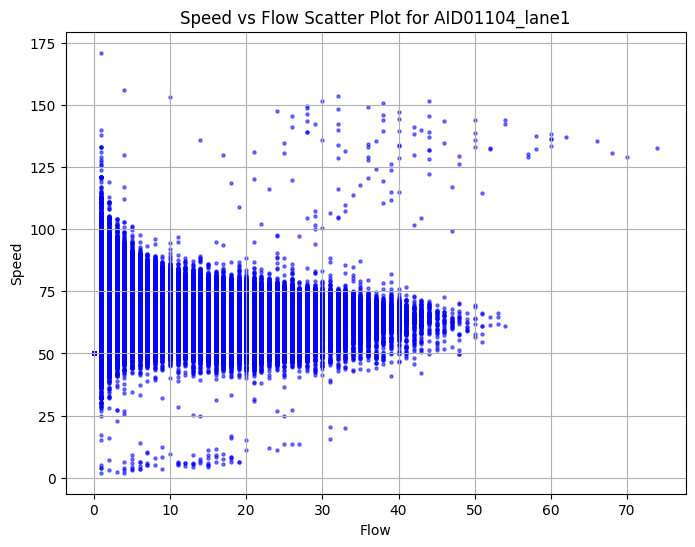

In [12]:
for i in range(10):
    plot_speed_vs_flow(dfs,dfv,dfs.columns[i])

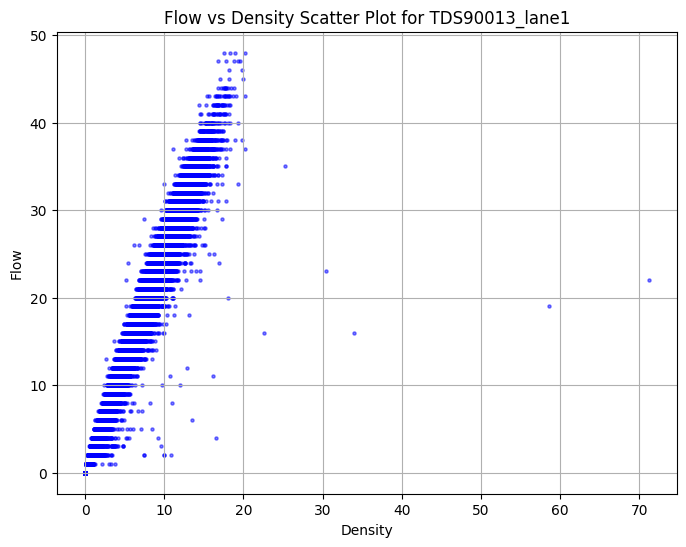

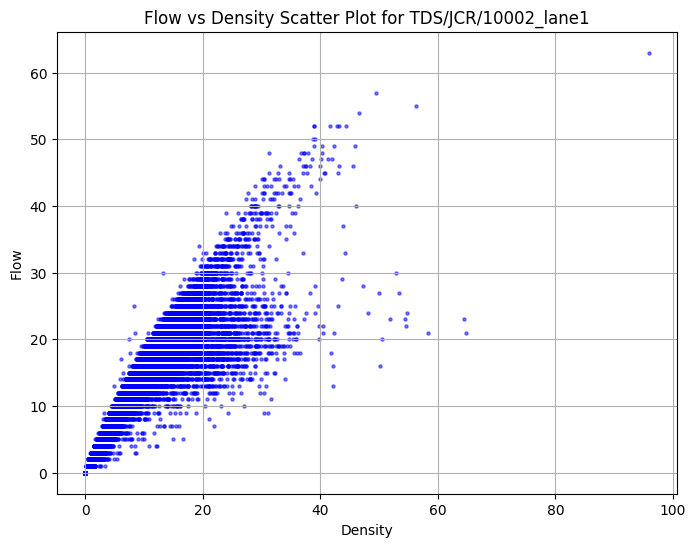

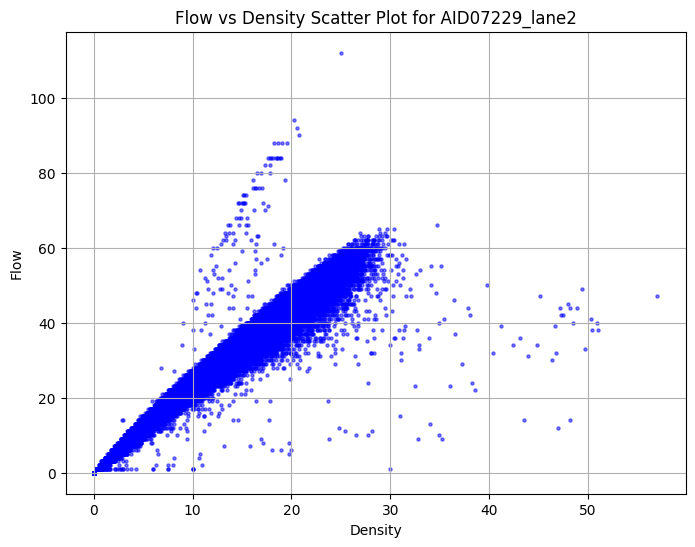

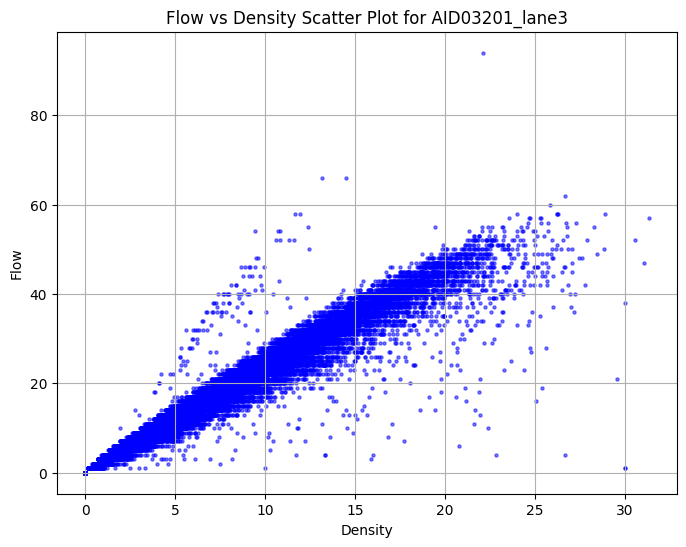

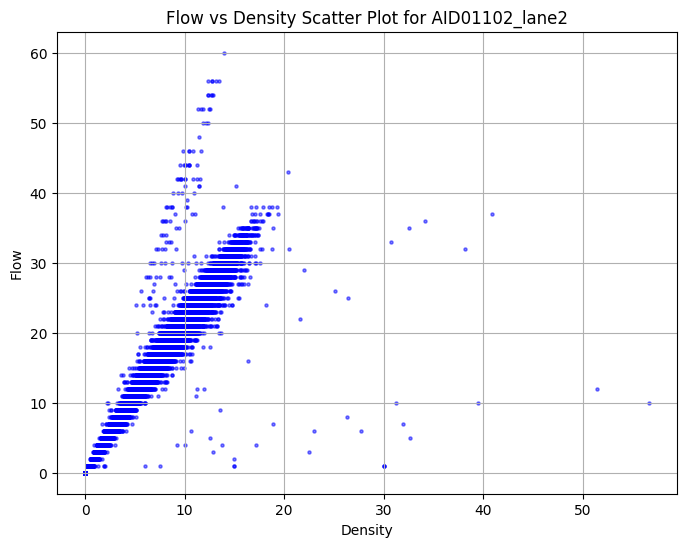

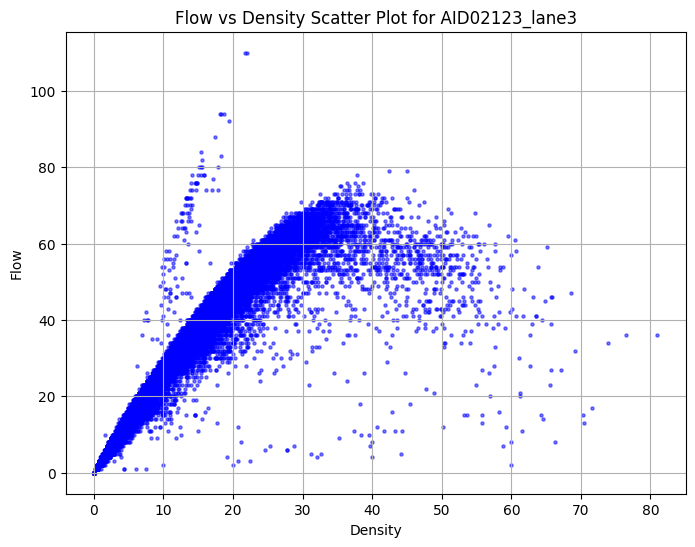

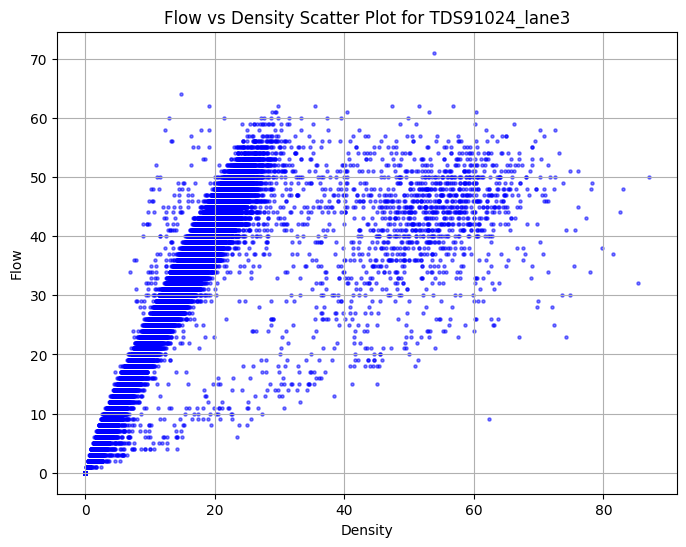

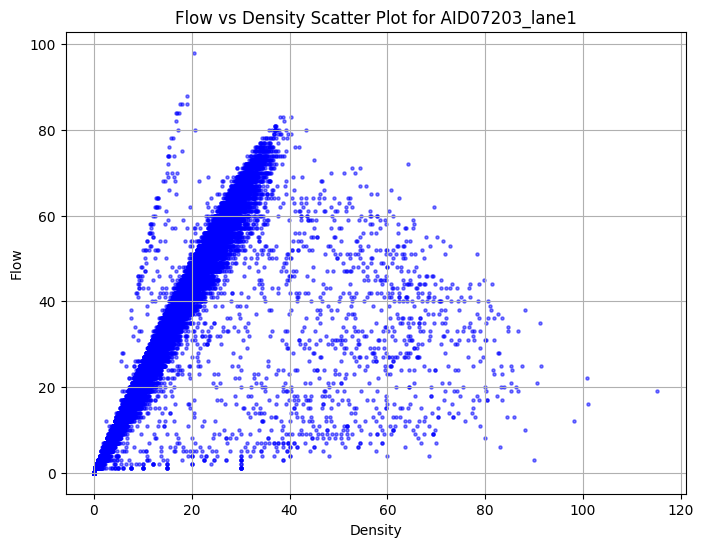

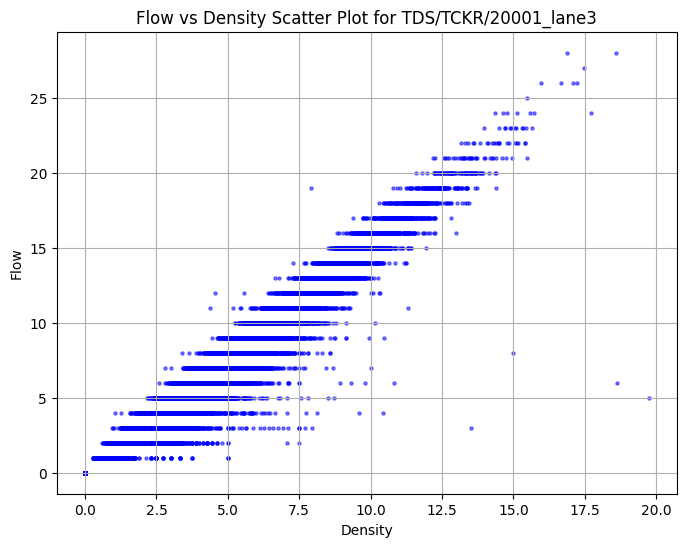

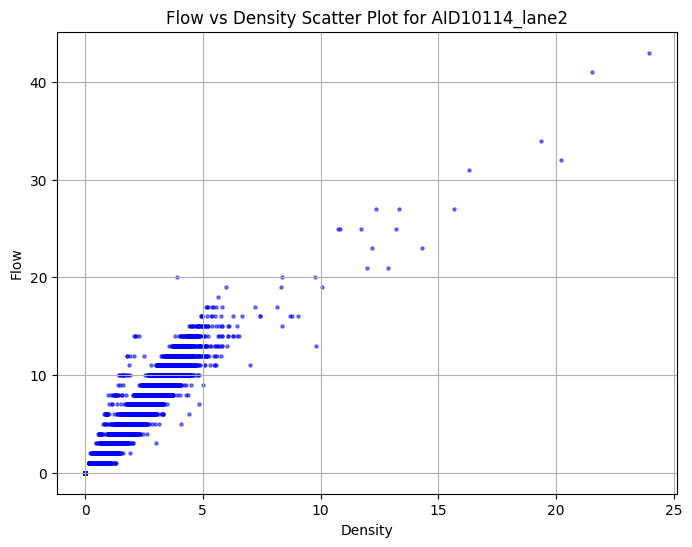

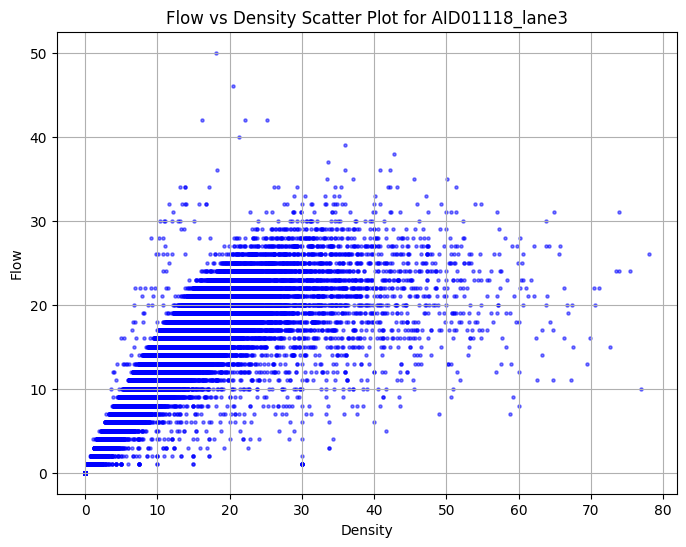

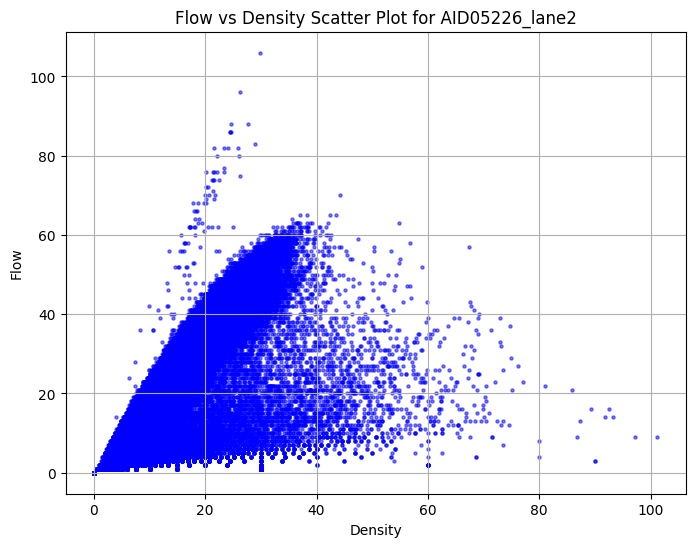

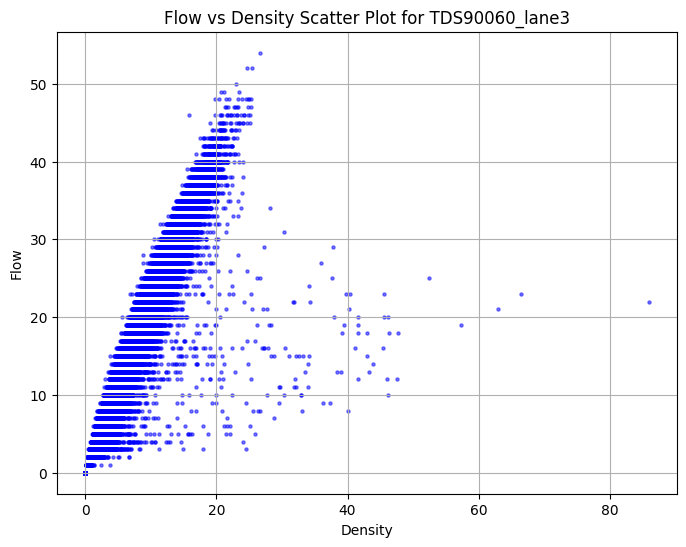

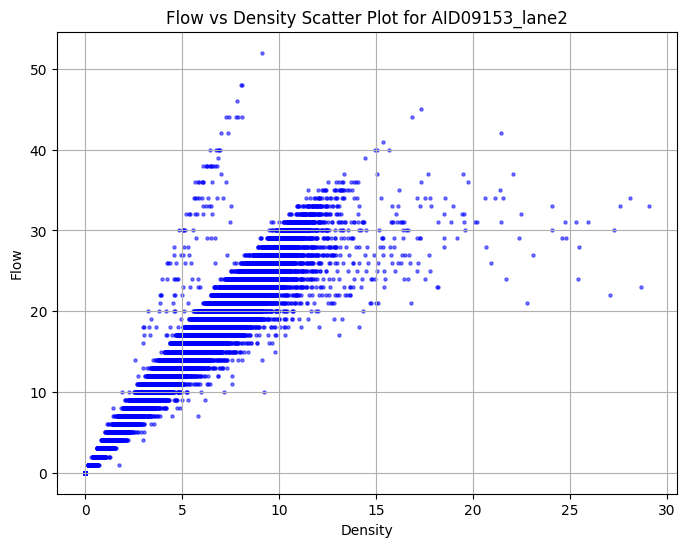

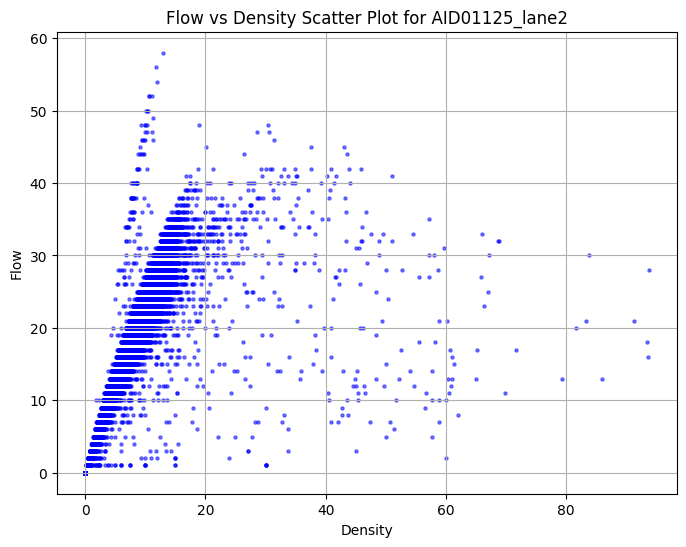

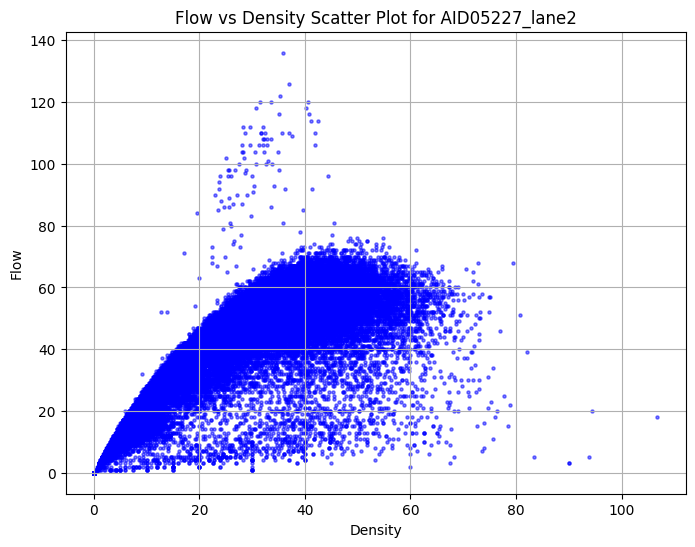

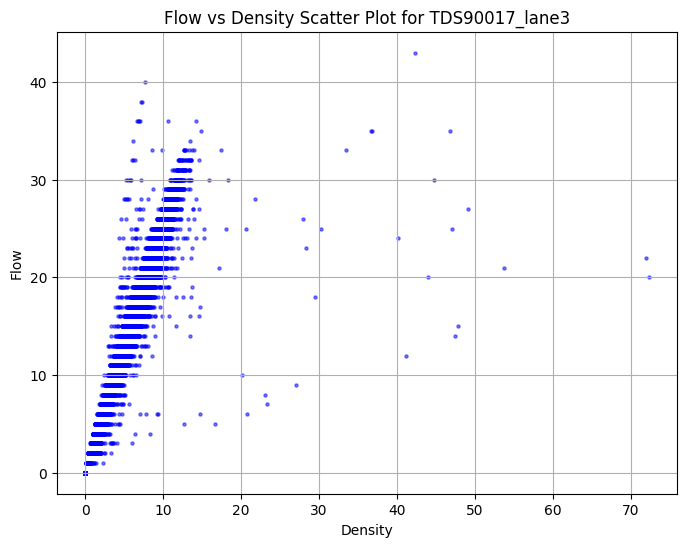

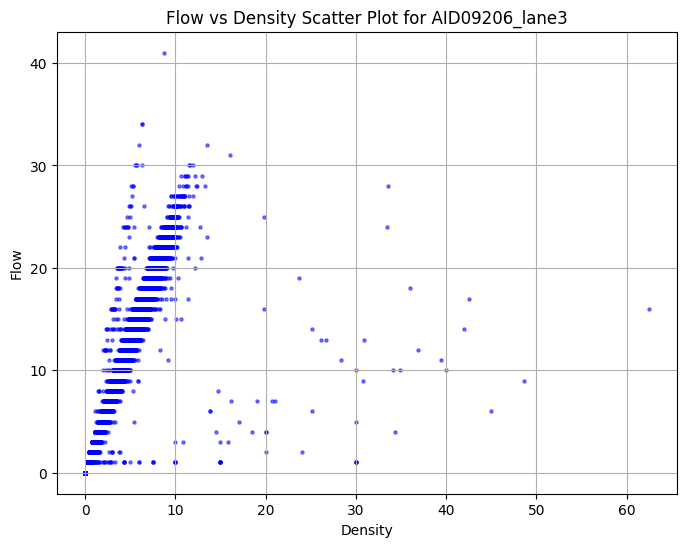

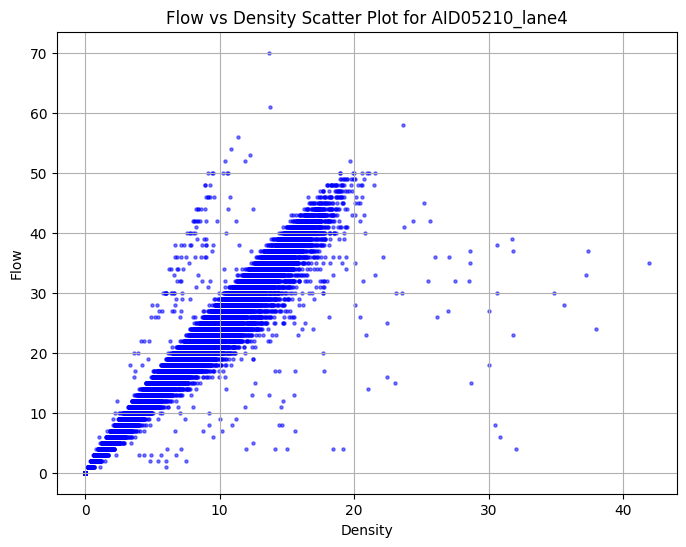

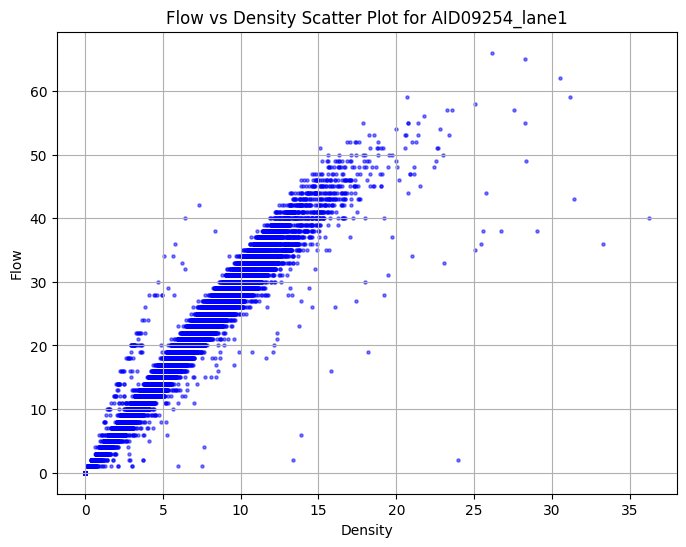

In [13]:
import random 
random_numbers = [random.randint(1, 2000) for _ in range(20)]
for i in random_numbers:
    plot_flow_vs_density(dfv,dfk,dfv.columns[i])

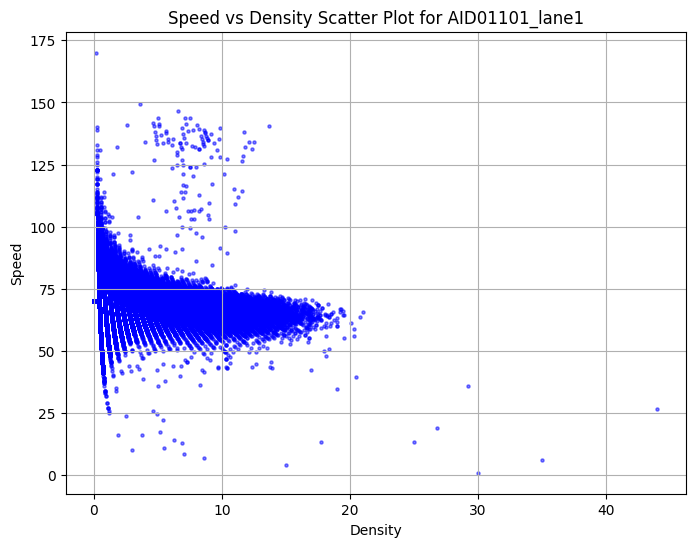

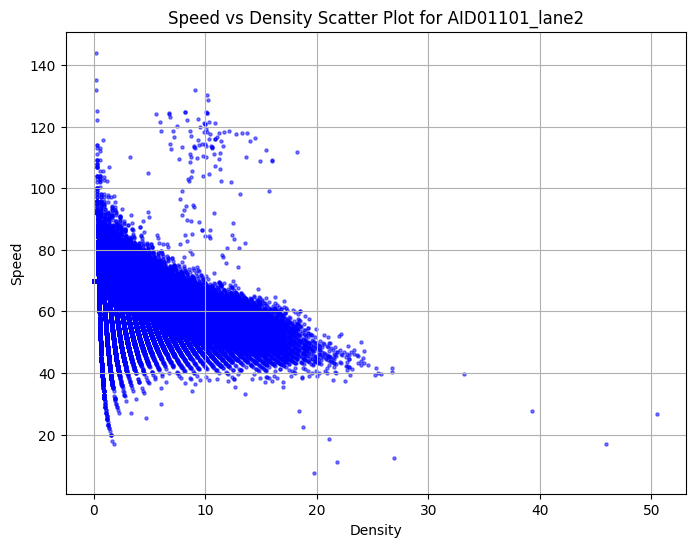

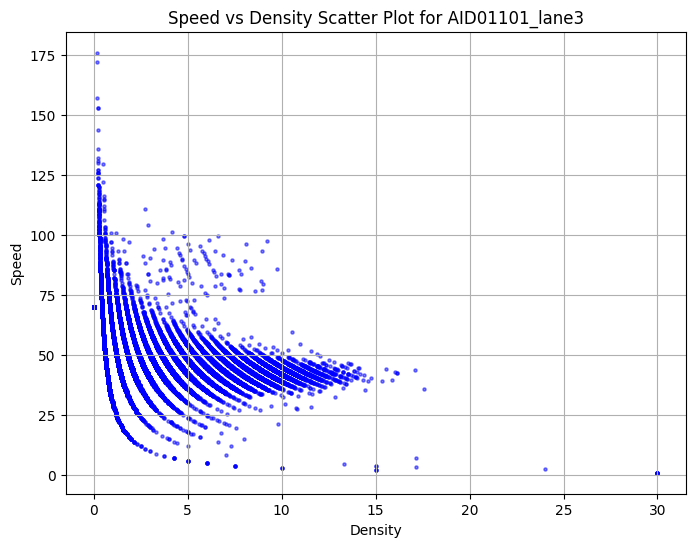

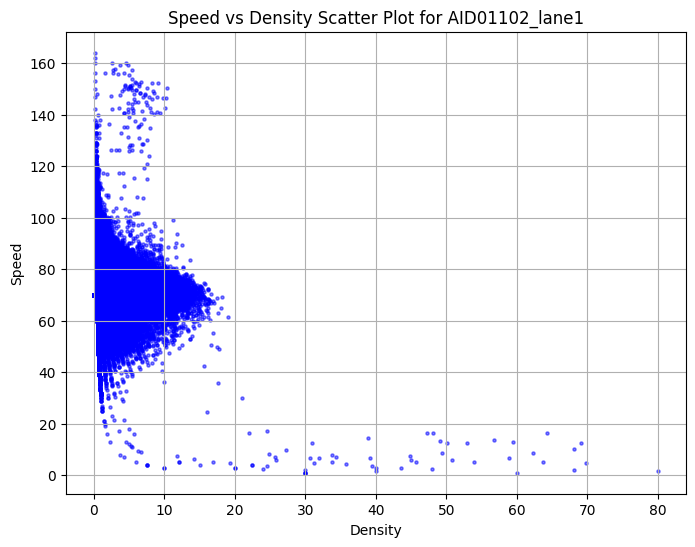

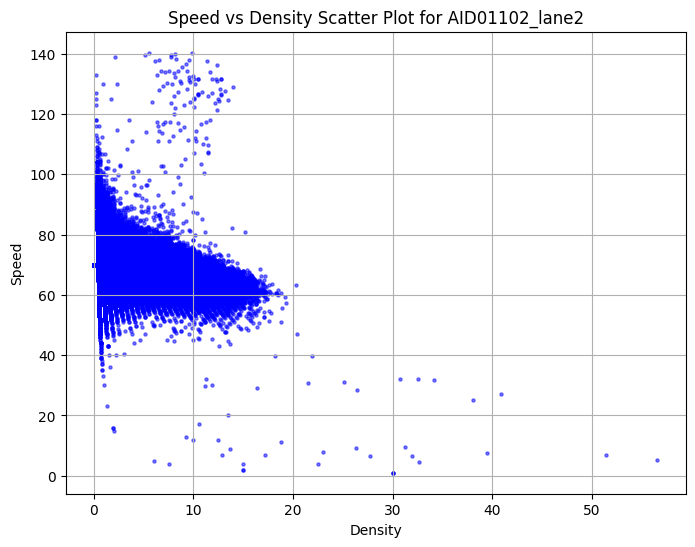

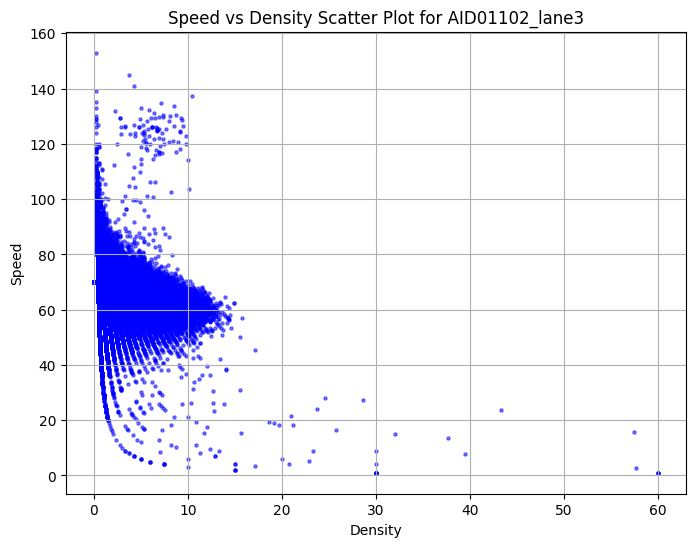

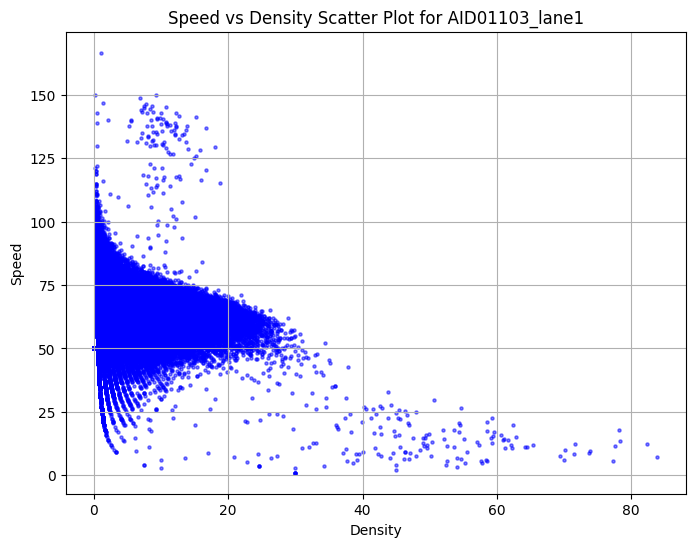

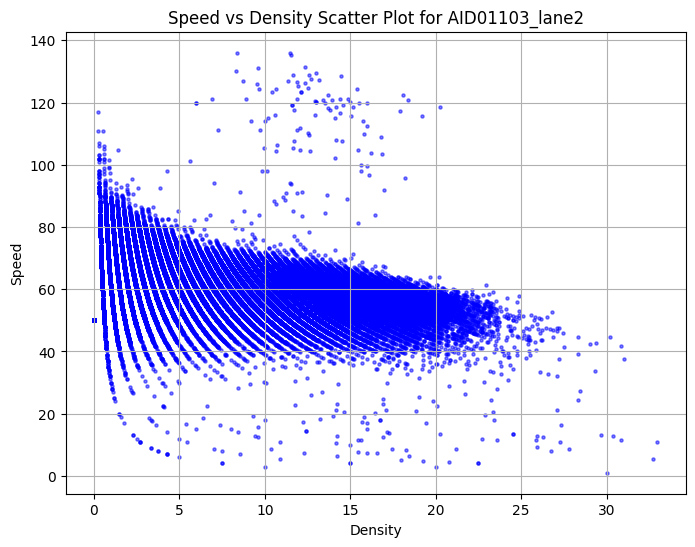

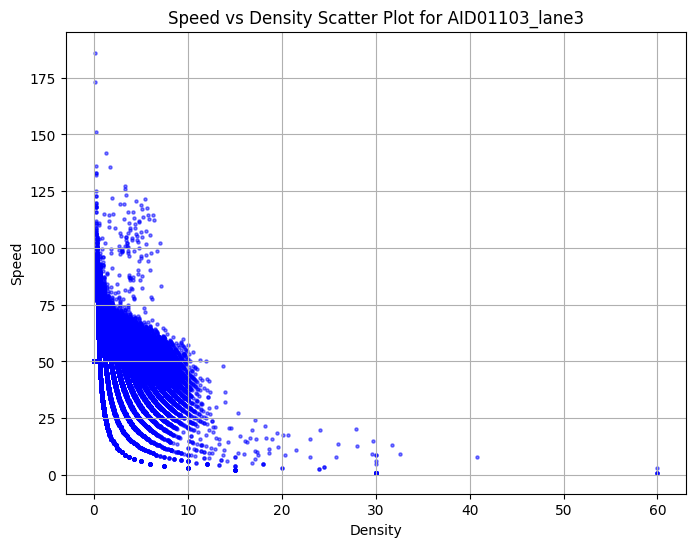

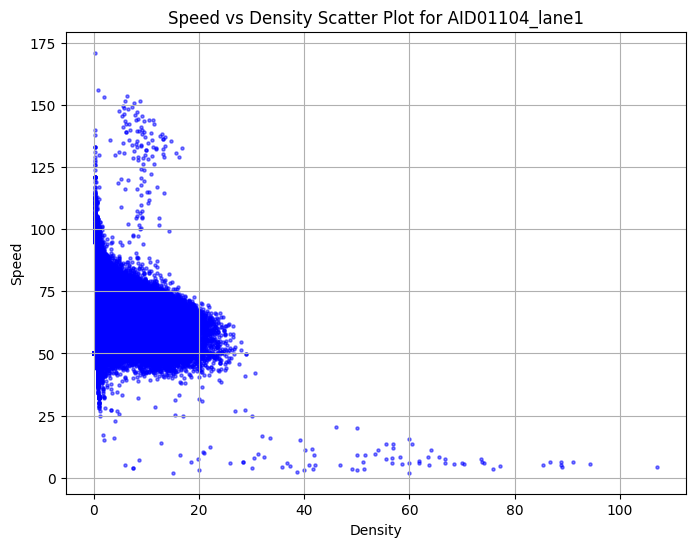

In [14]:
for i in range(10):
    plot_speed_vs_density(dfs,dfk,dfs.columns[i])

C:\Users\Nahush\AppData\Local\Temp\ipykernel_32120\1447317671.py:29: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12, 6))


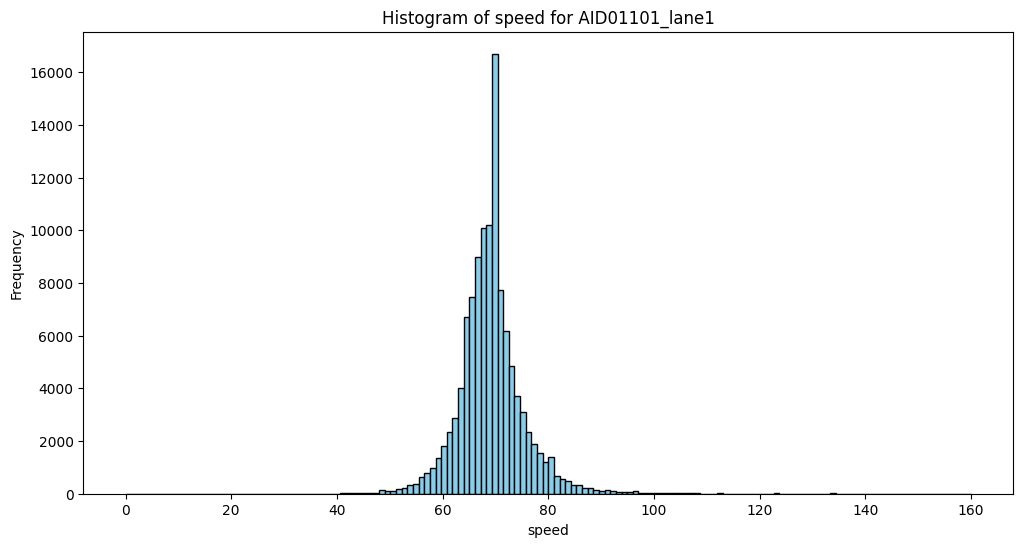

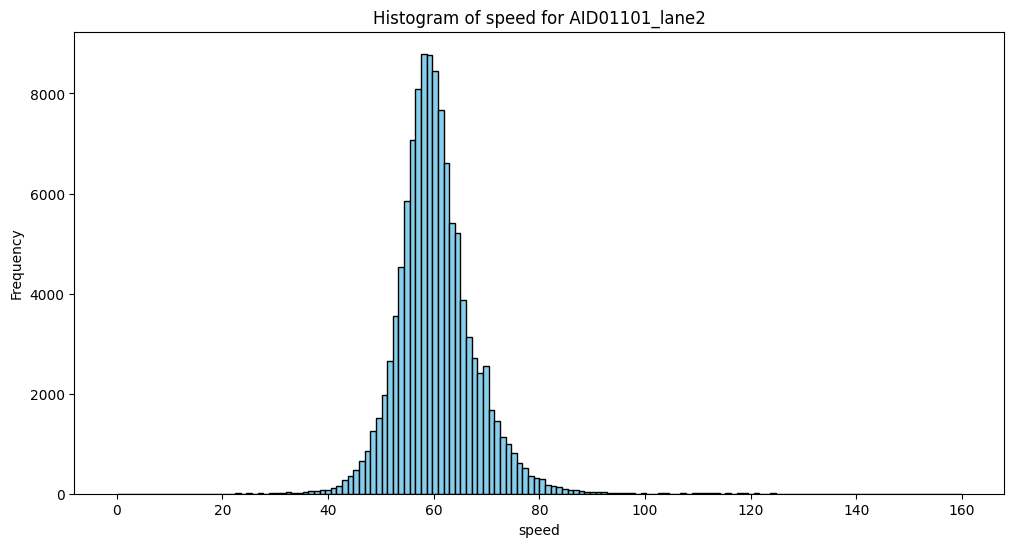

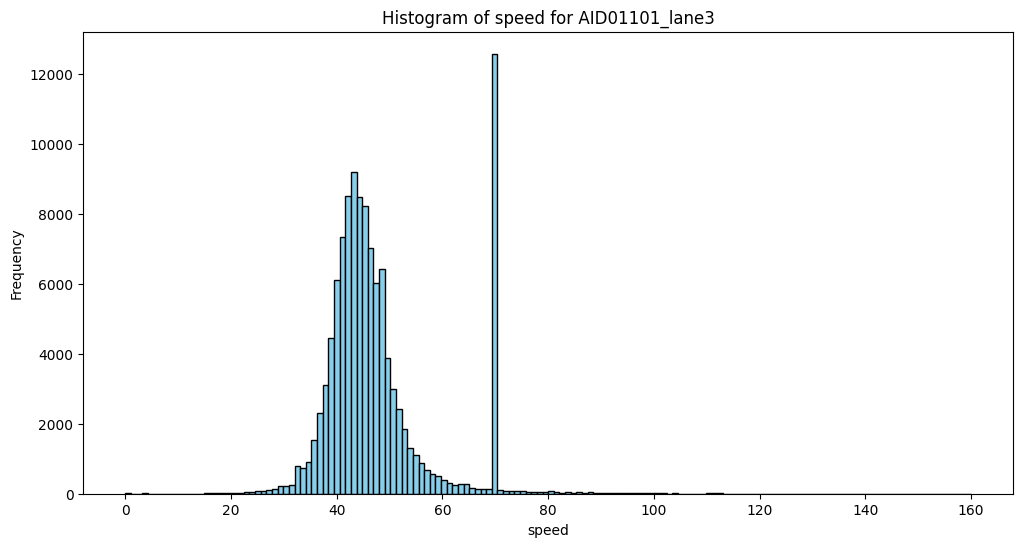

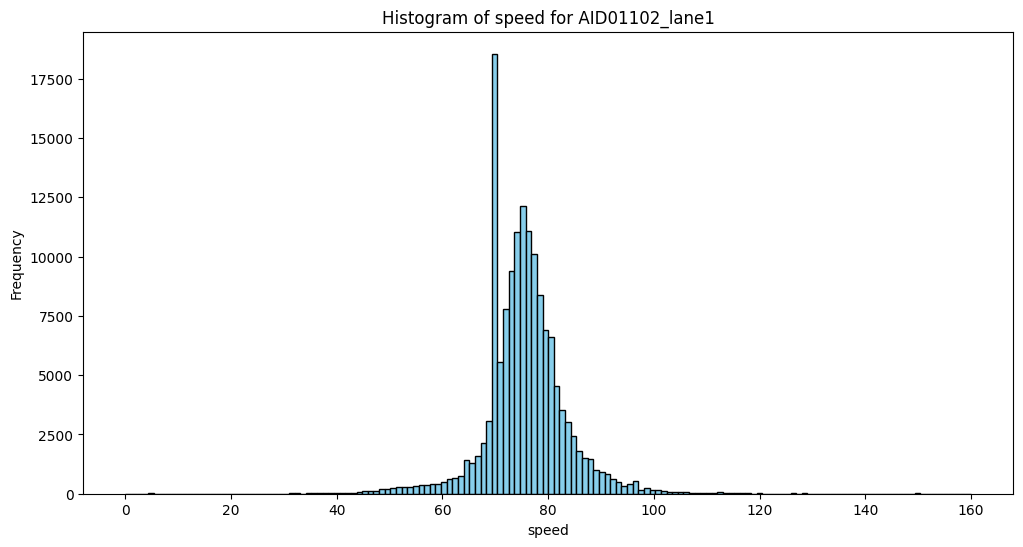

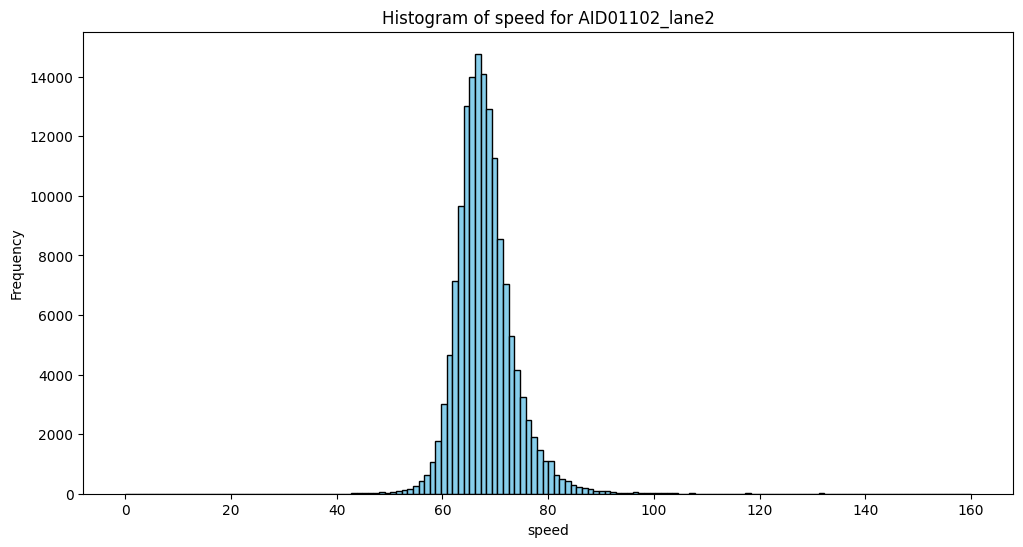

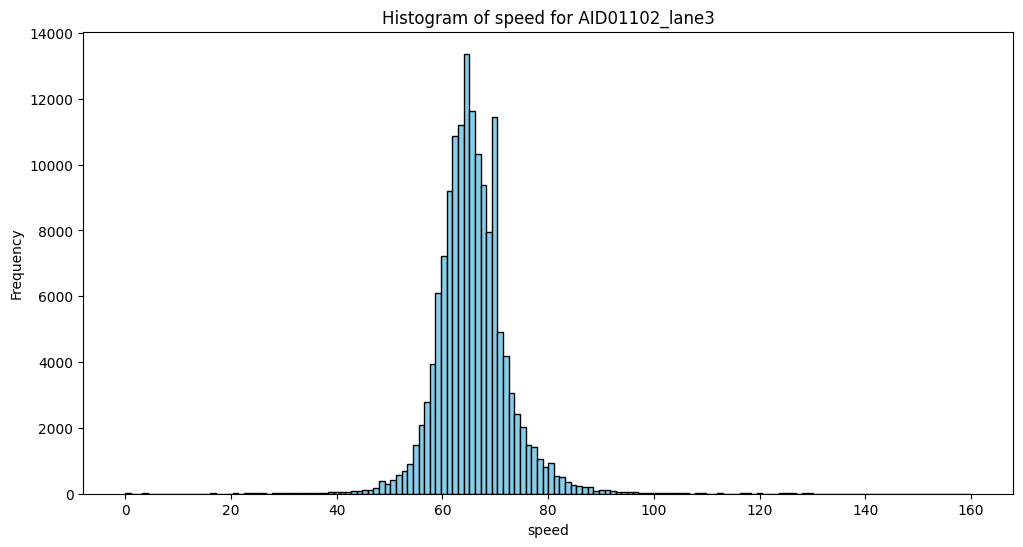

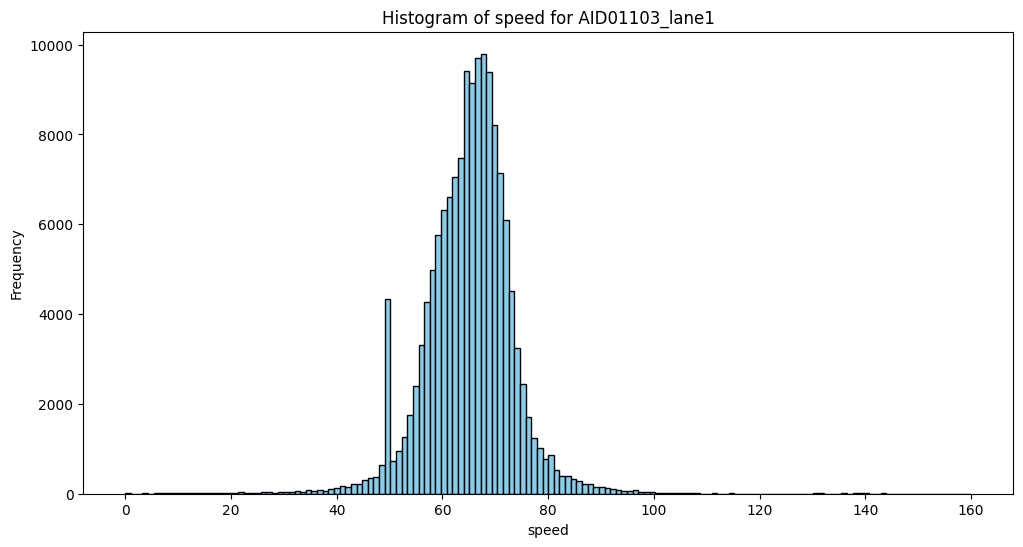

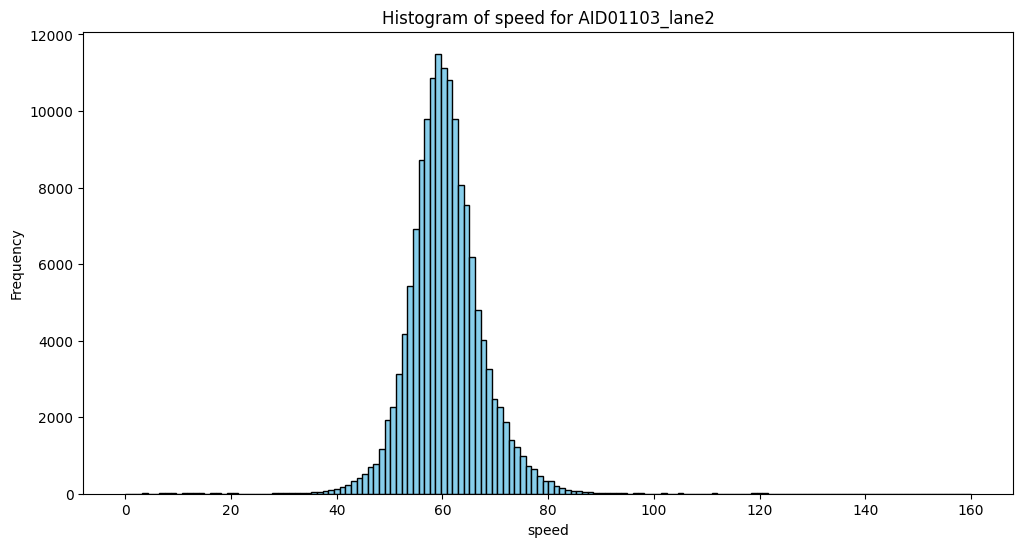

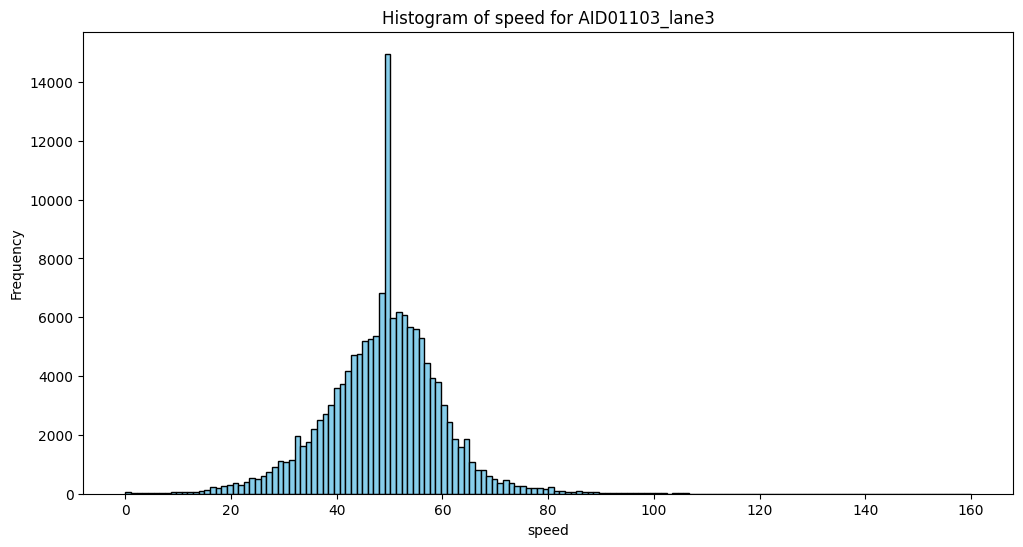

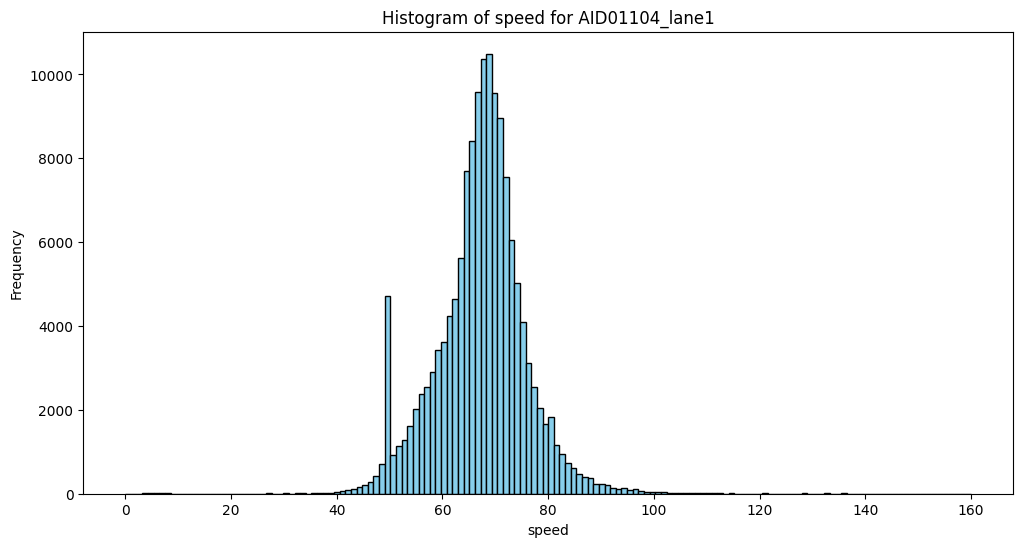

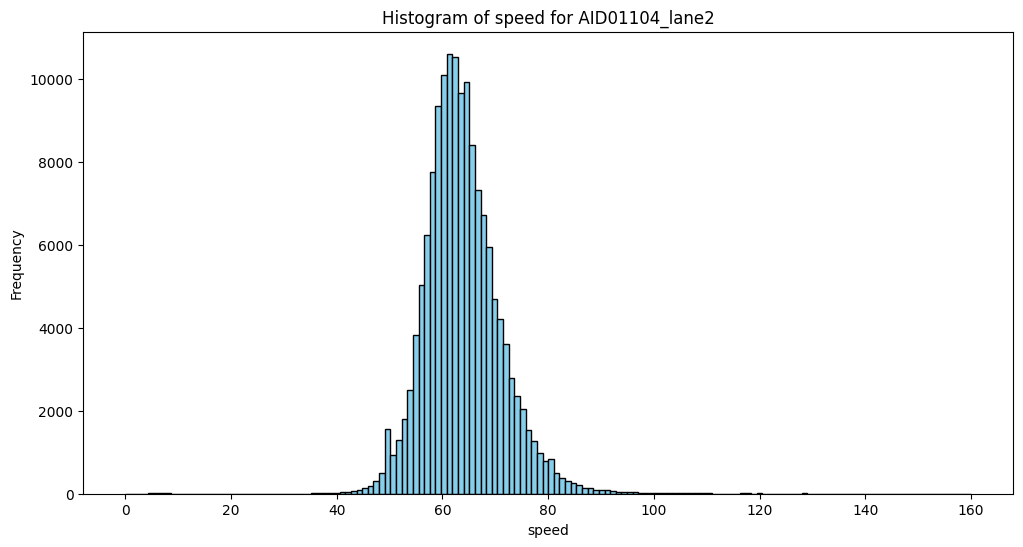

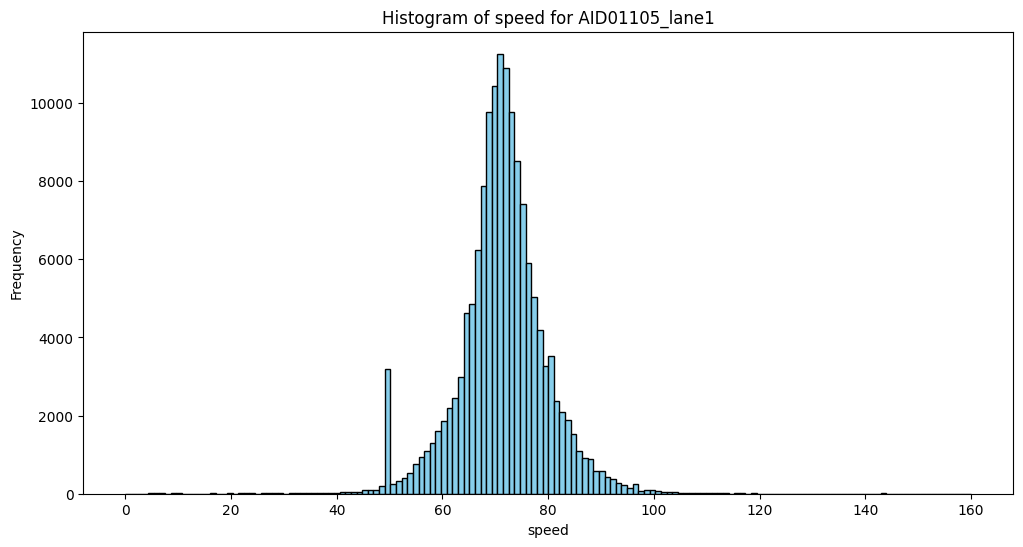

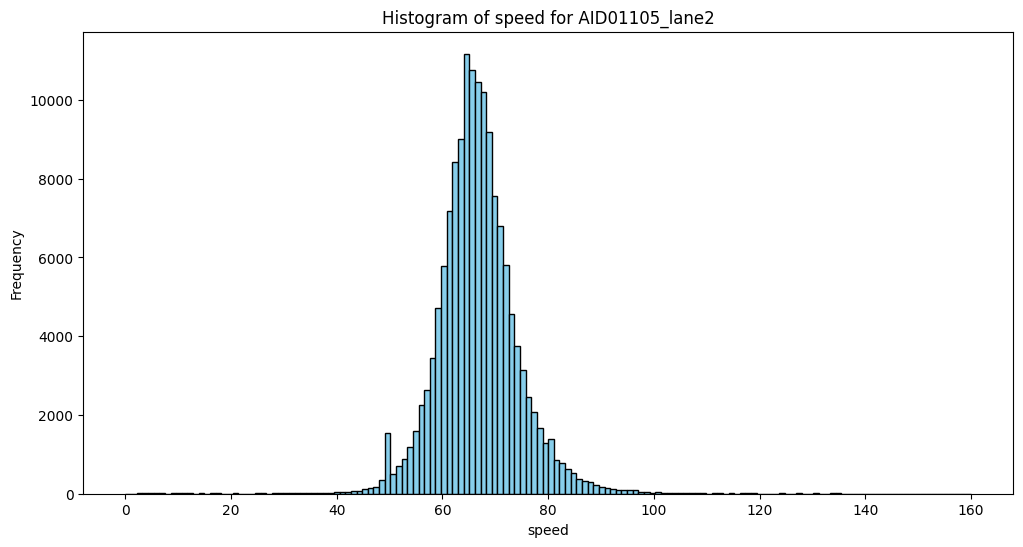

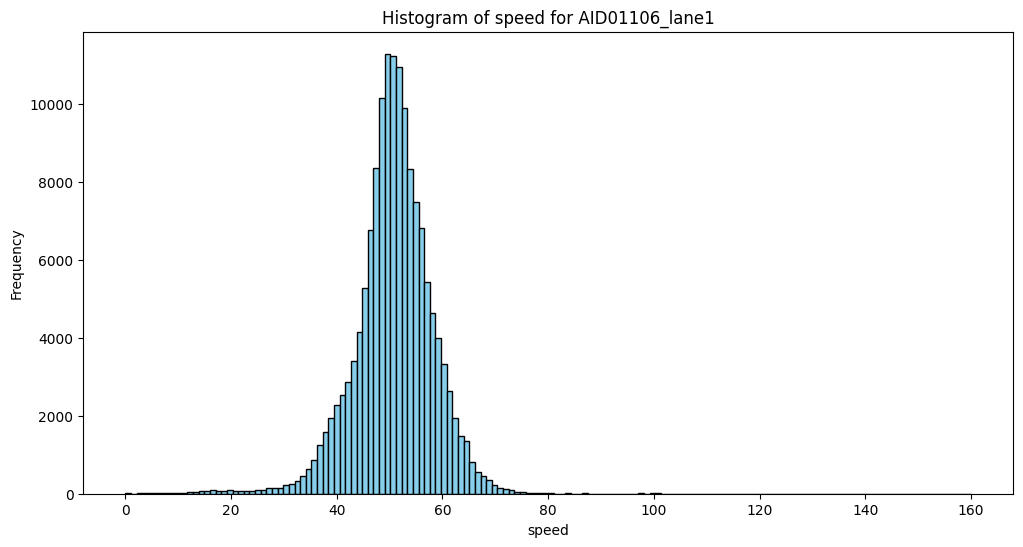

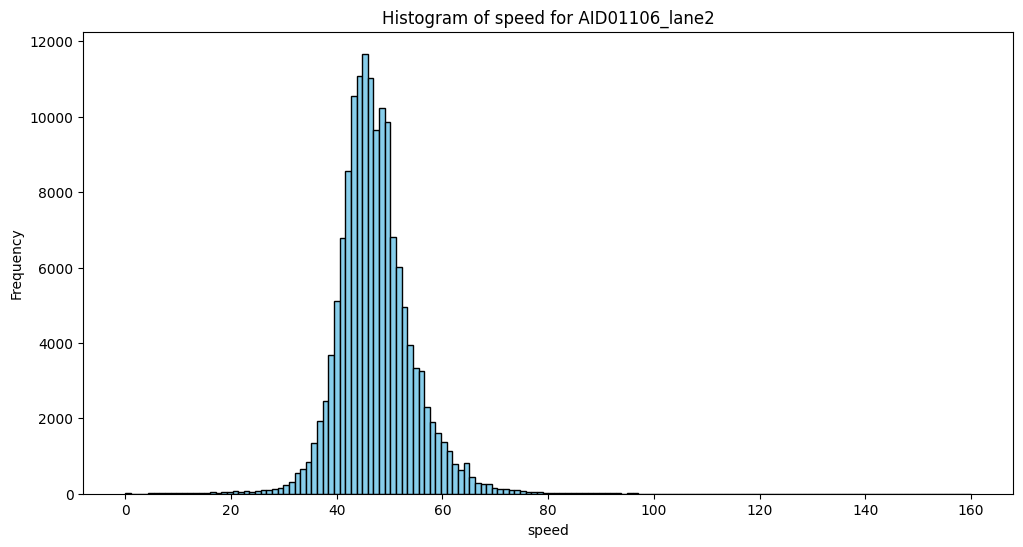

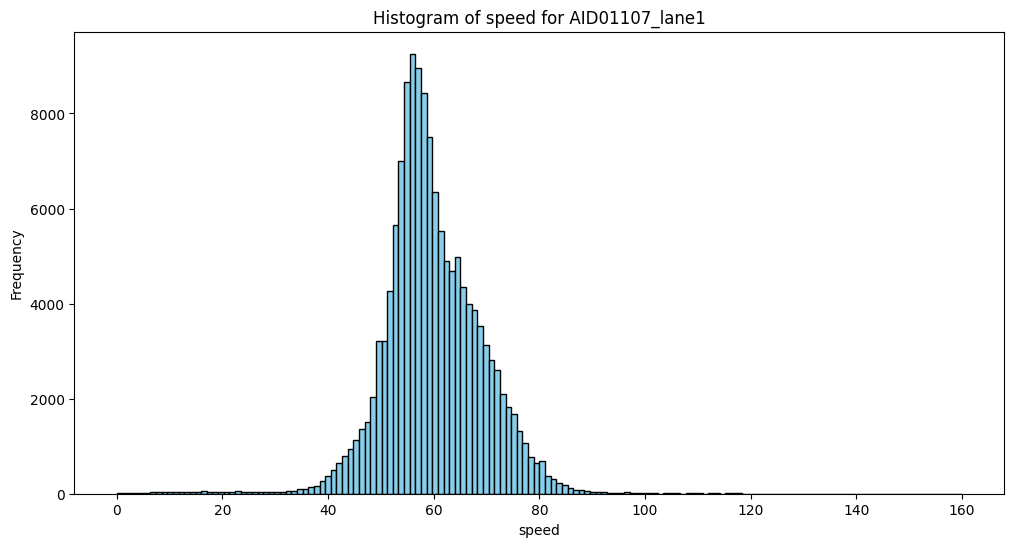

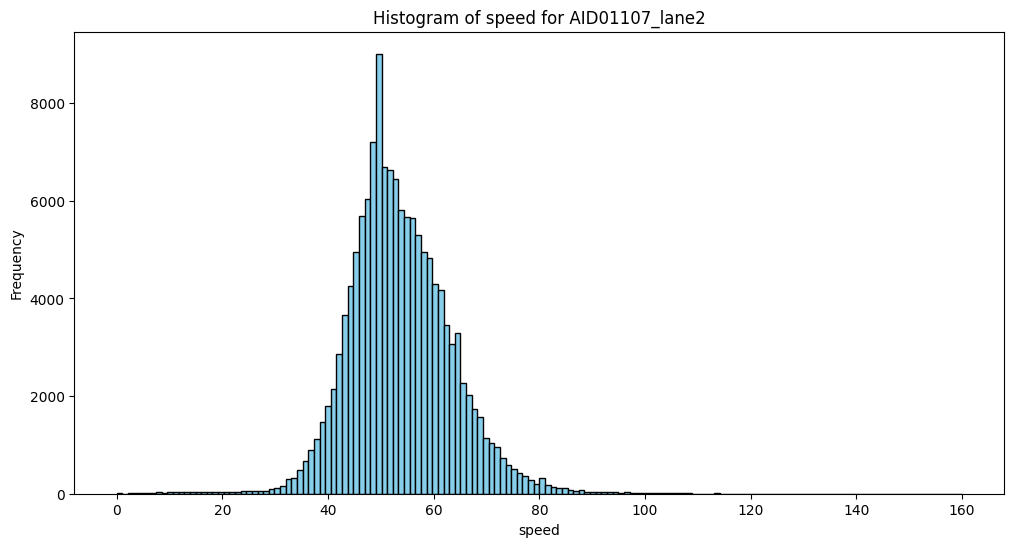

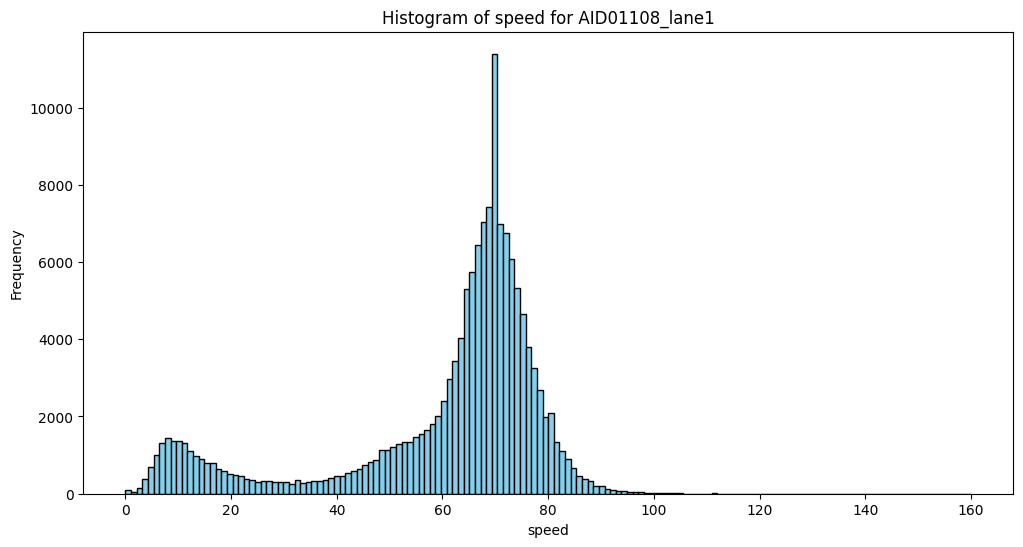

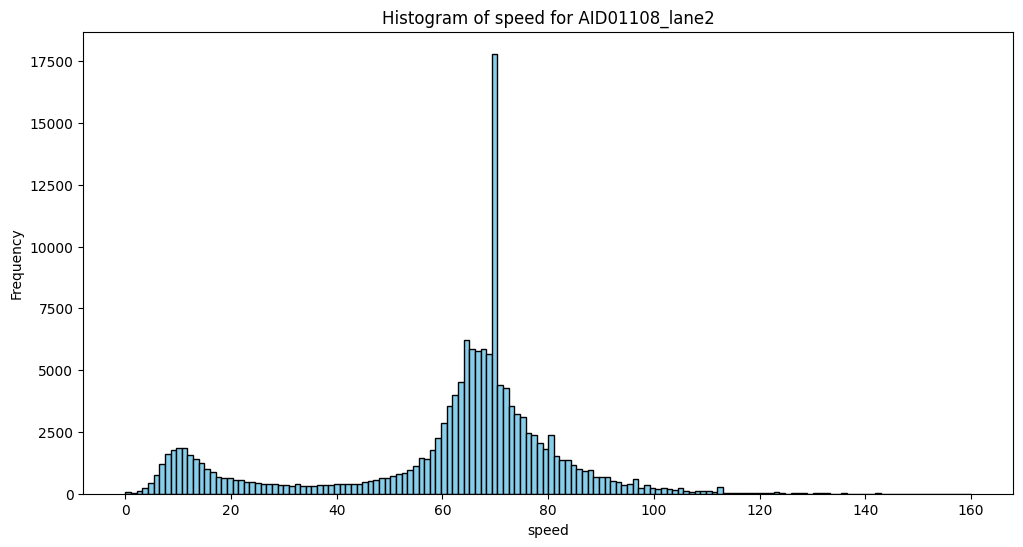

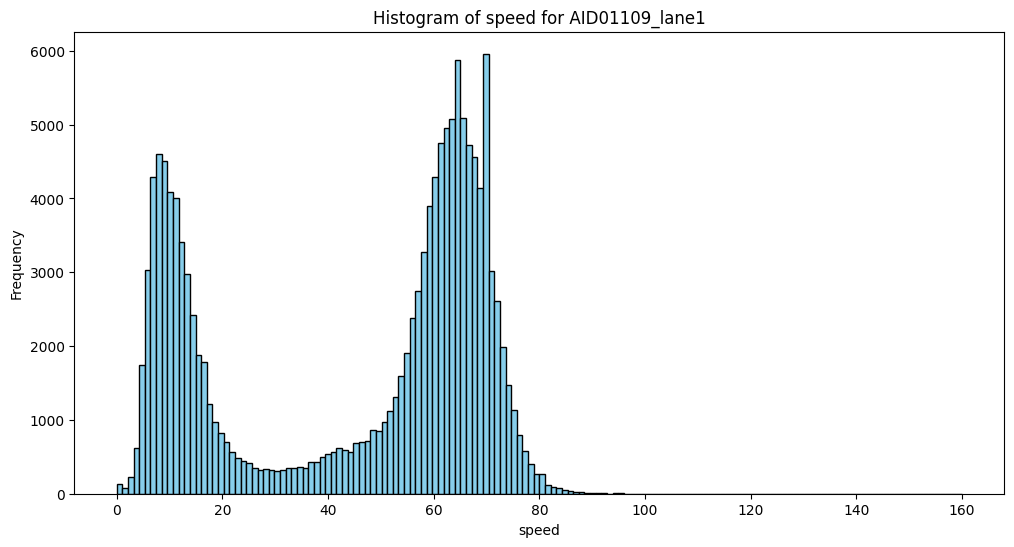

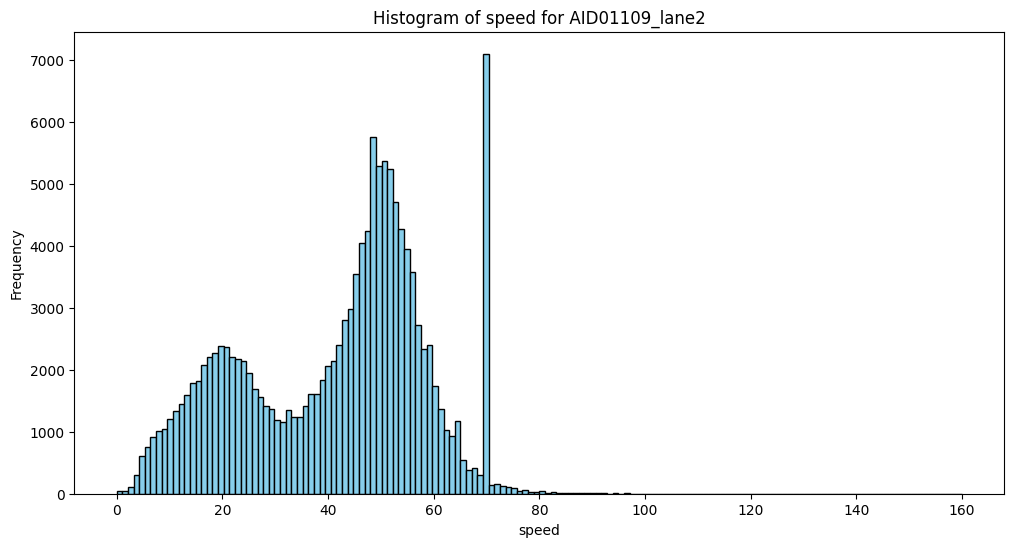

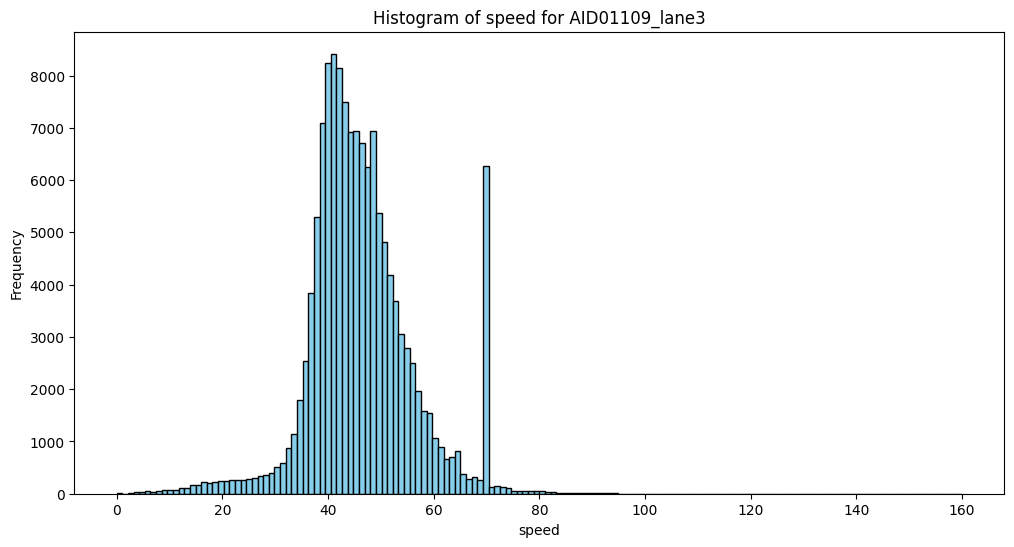

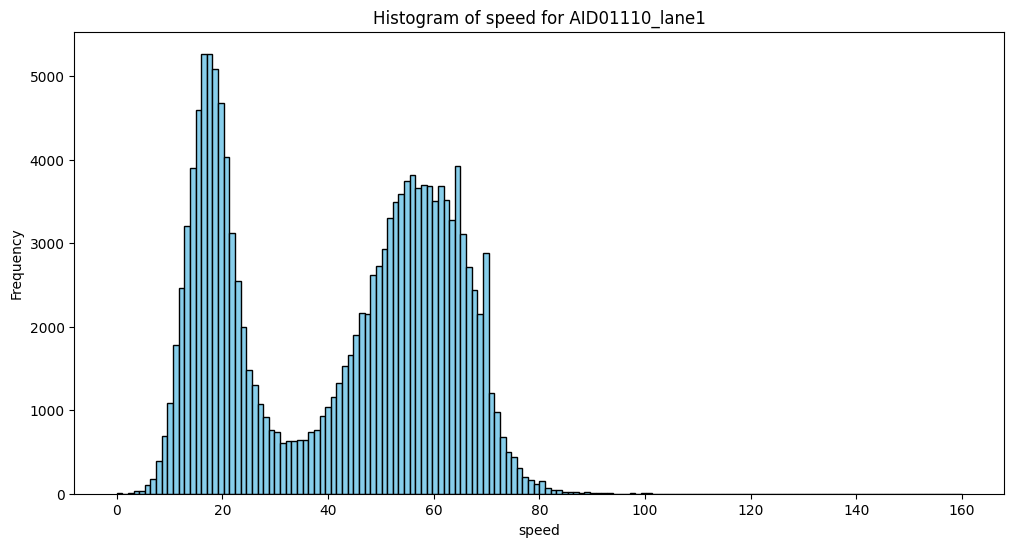

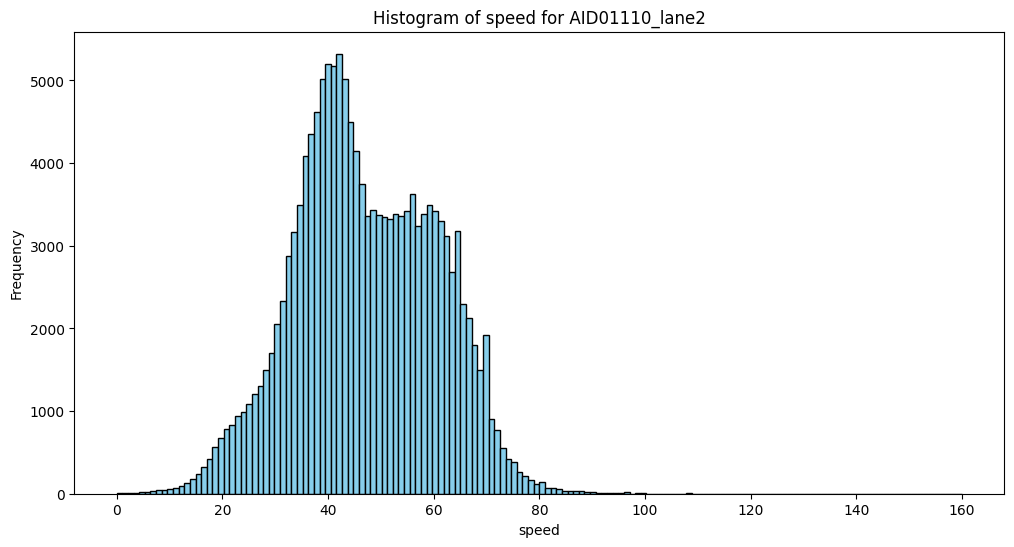

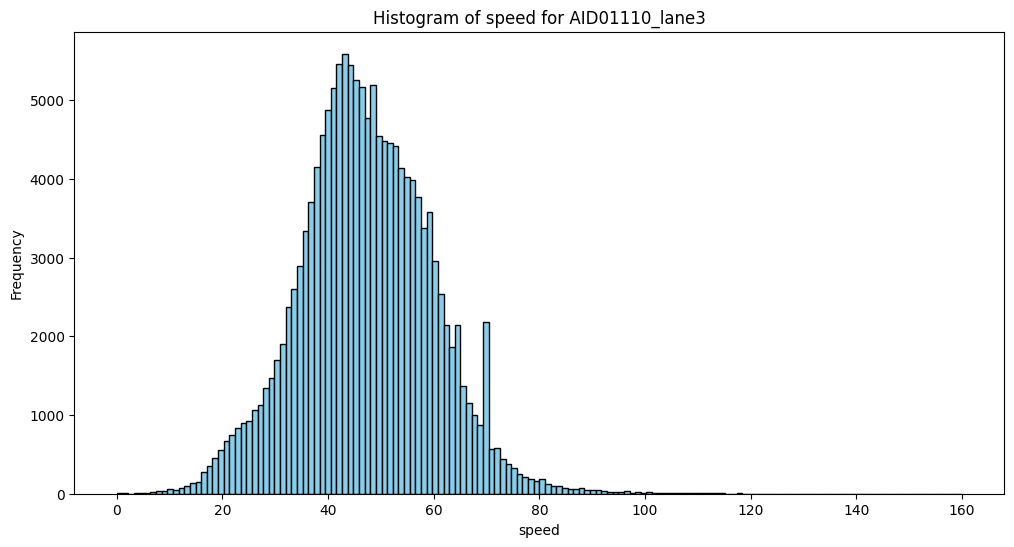

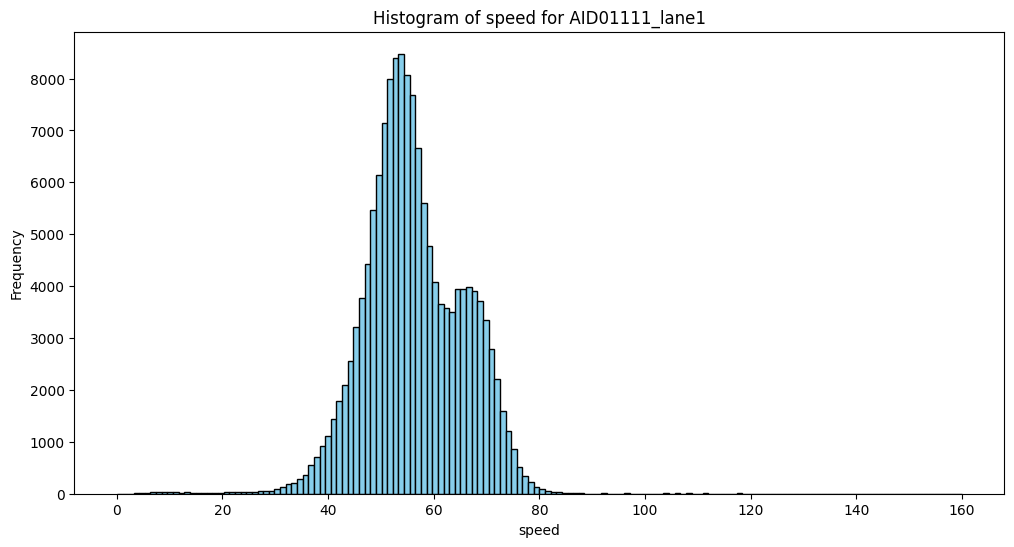

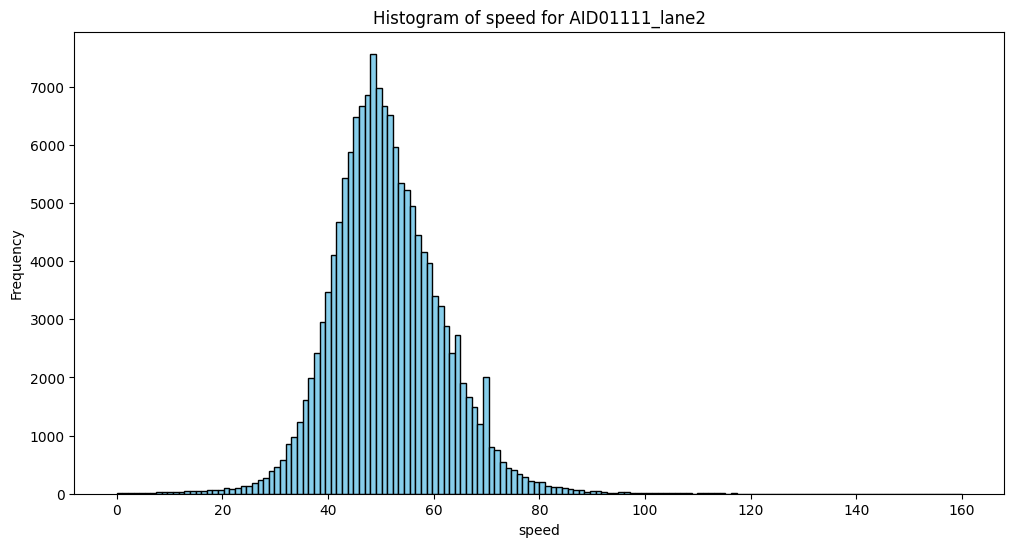

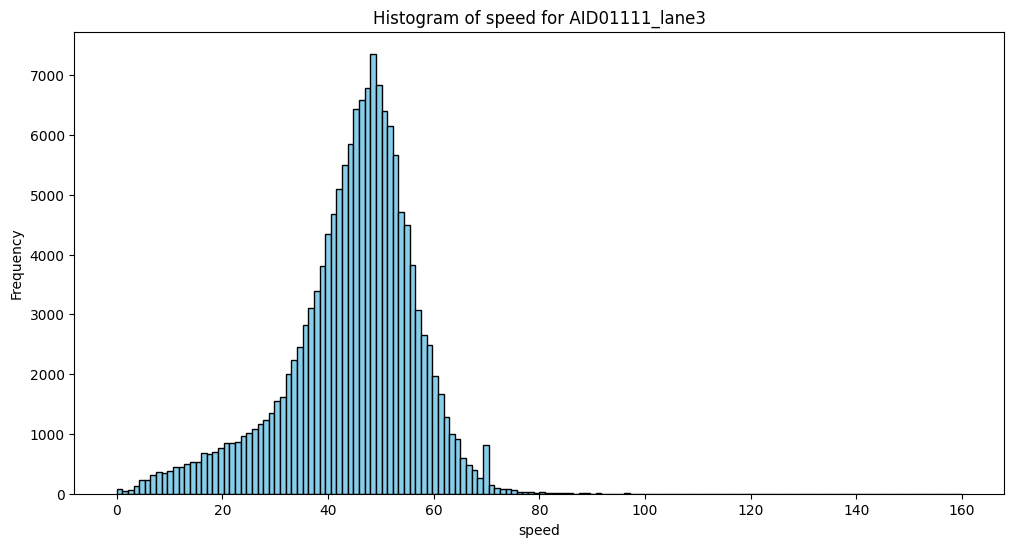

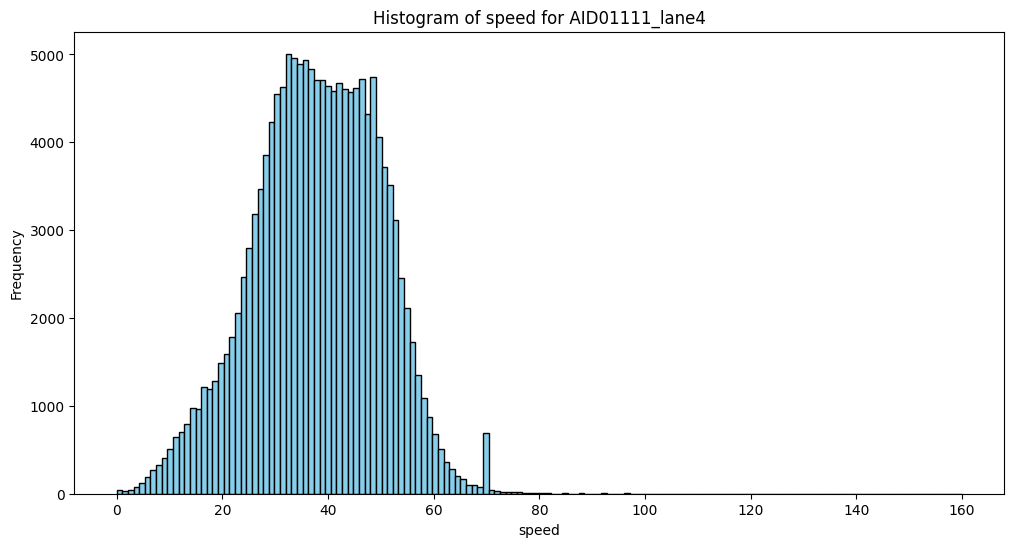

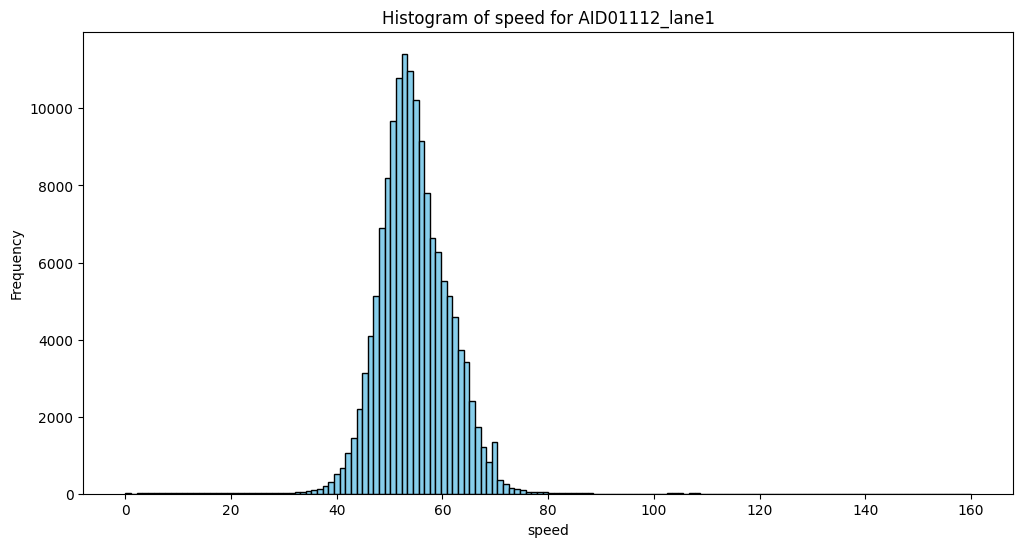

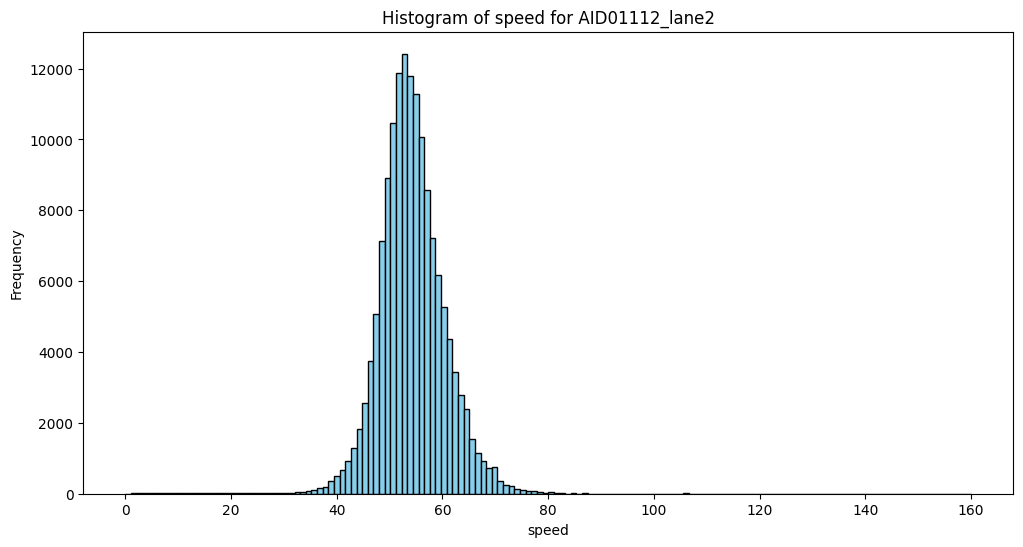

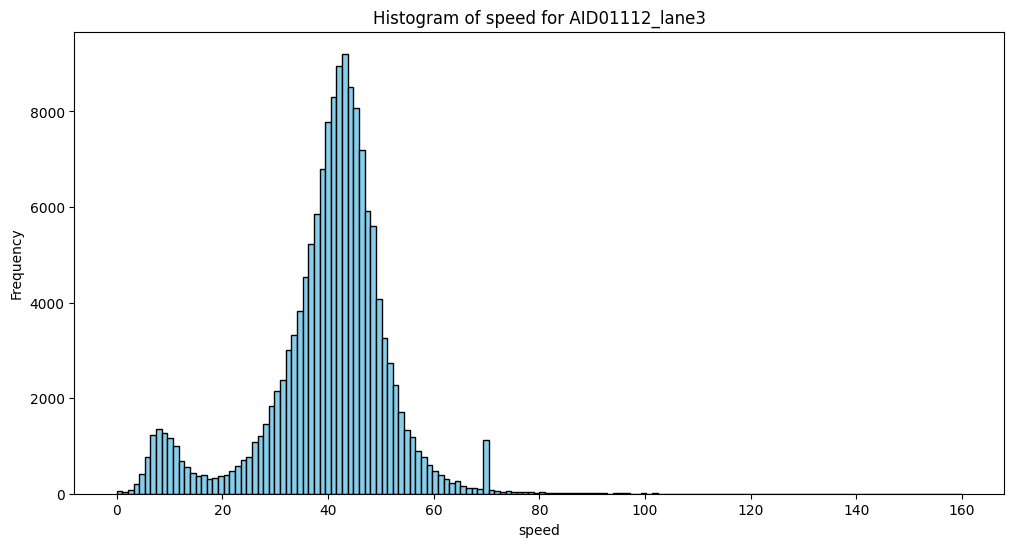

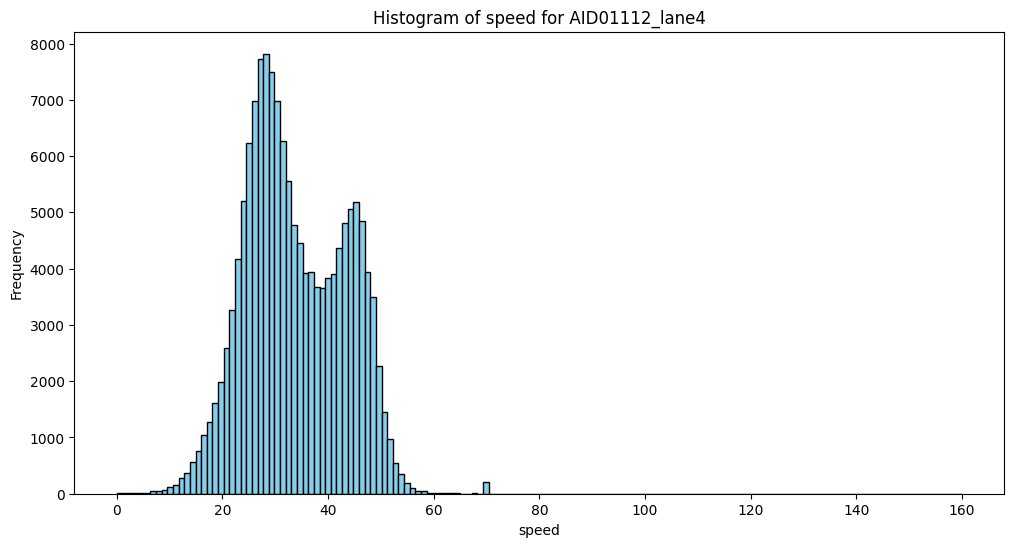

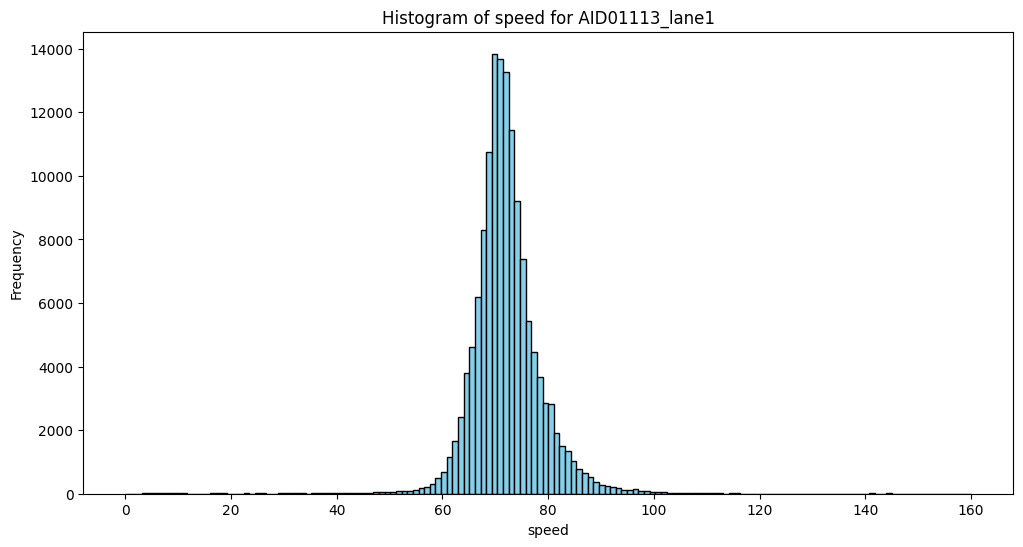

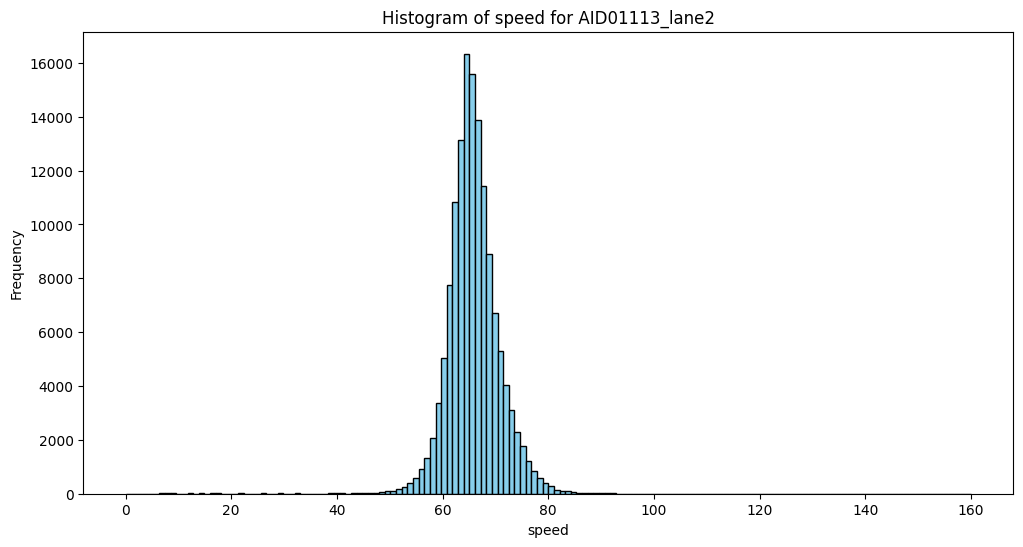

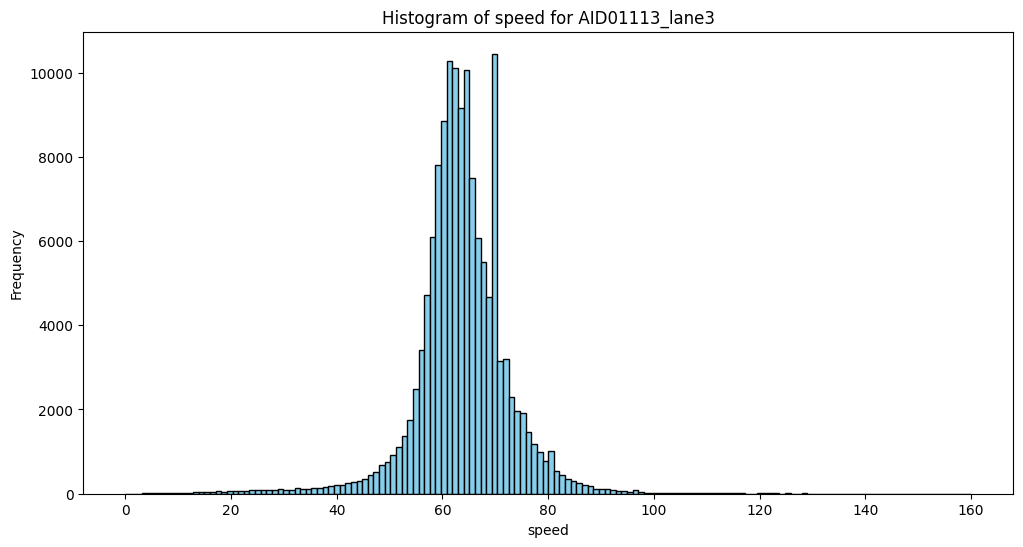

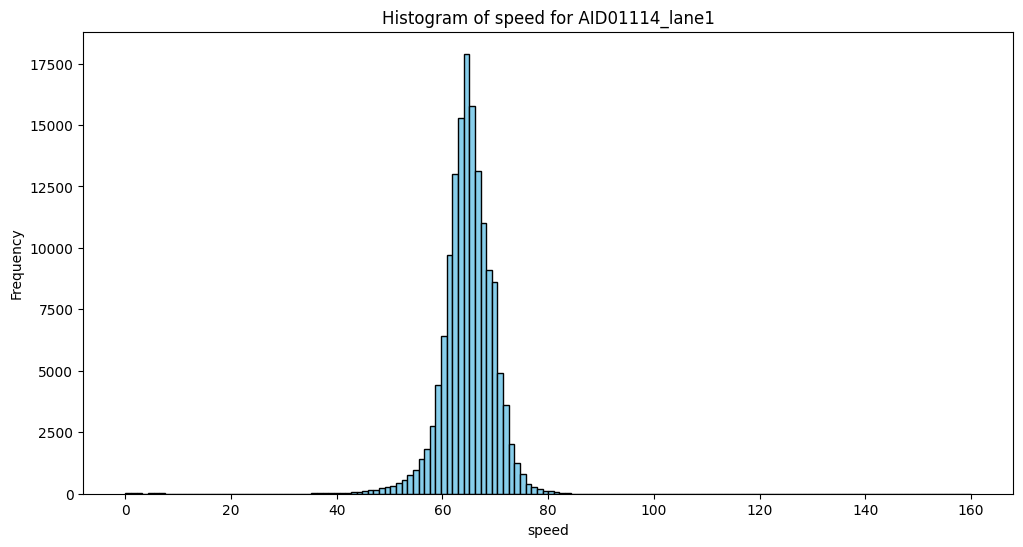

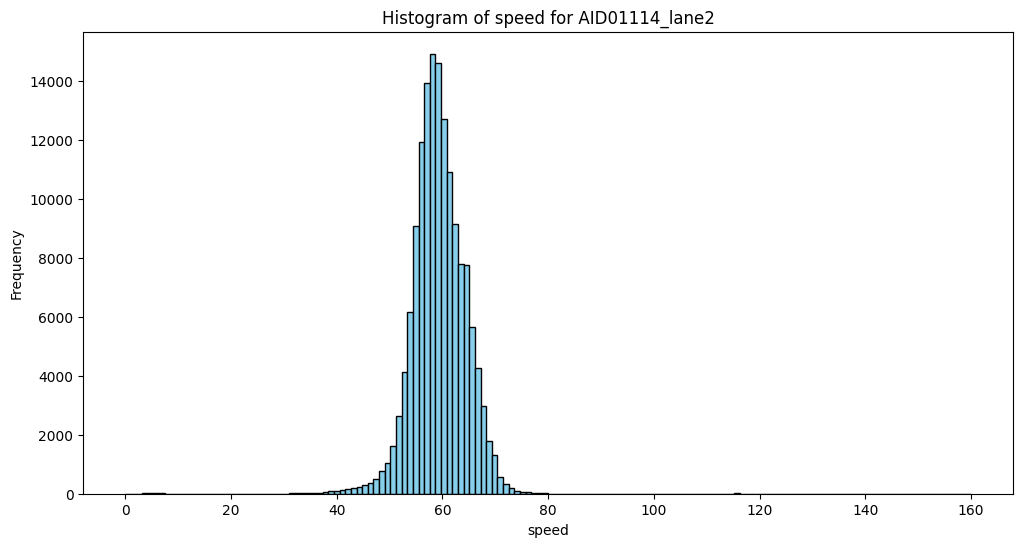

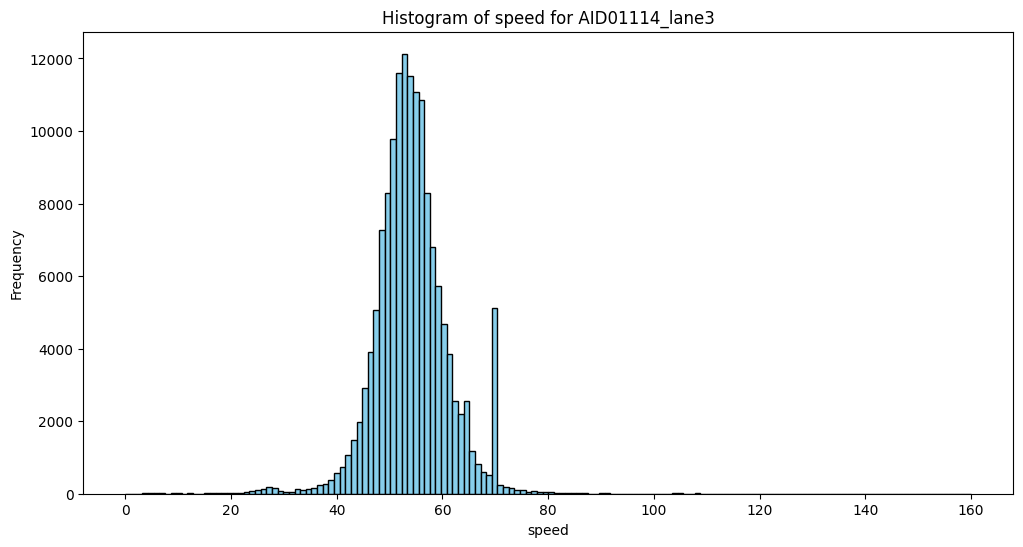

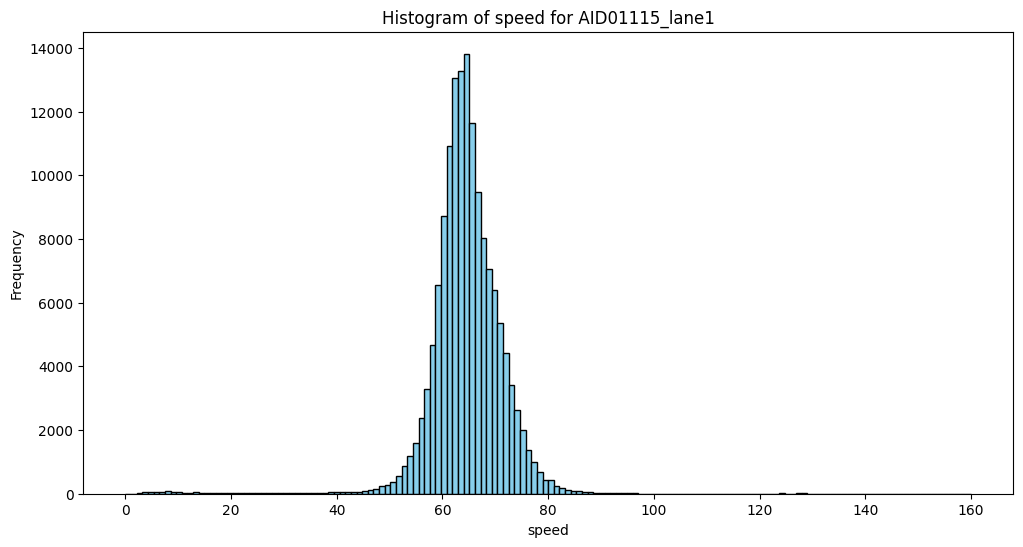

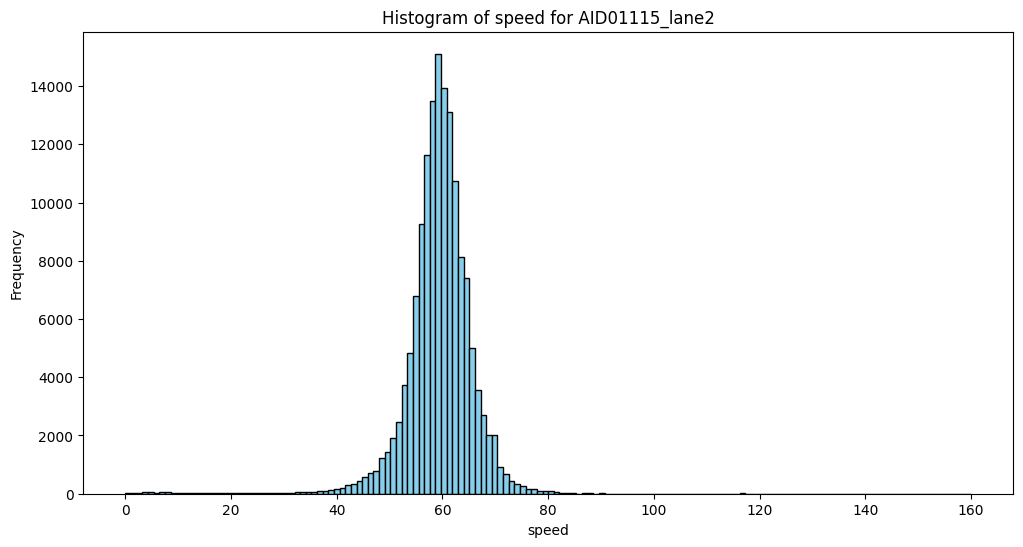

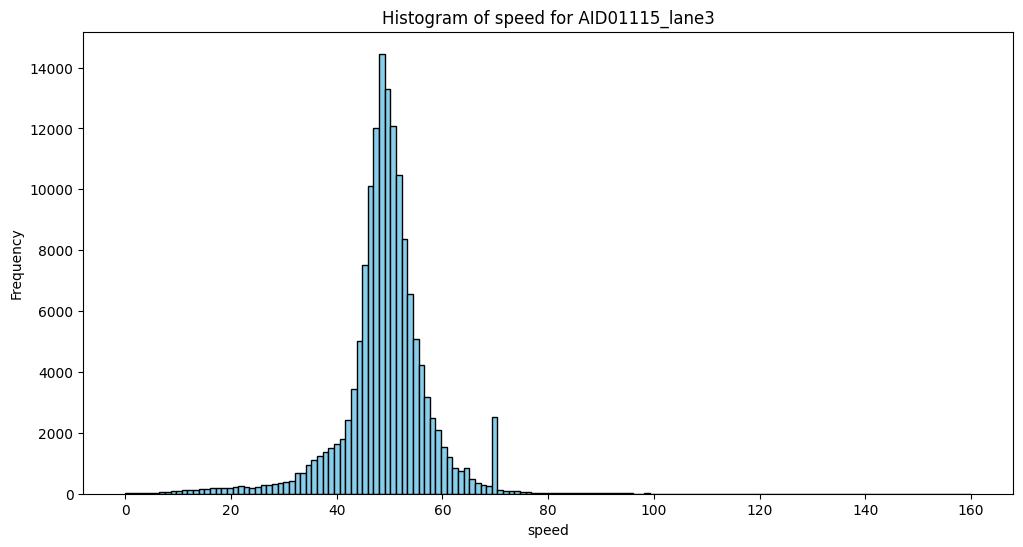

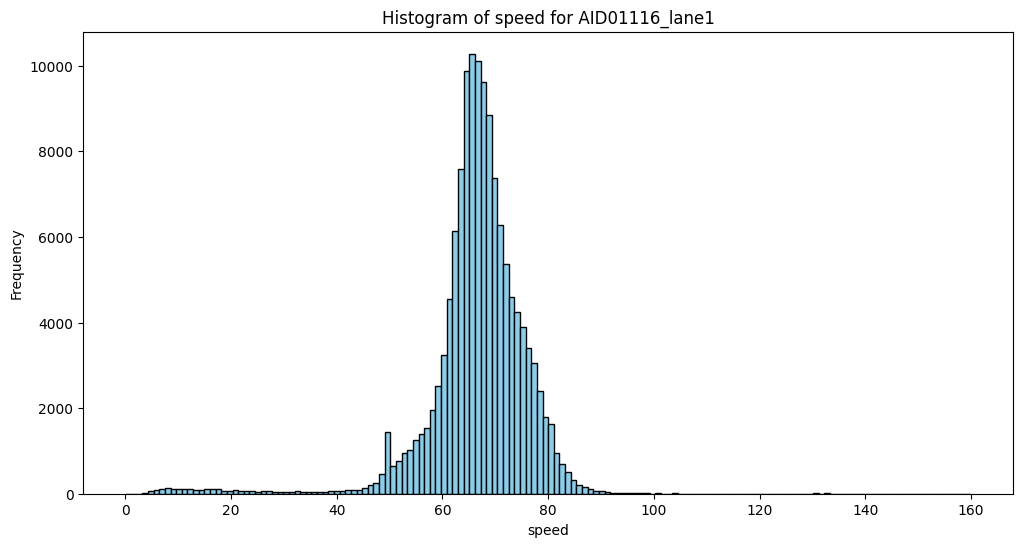

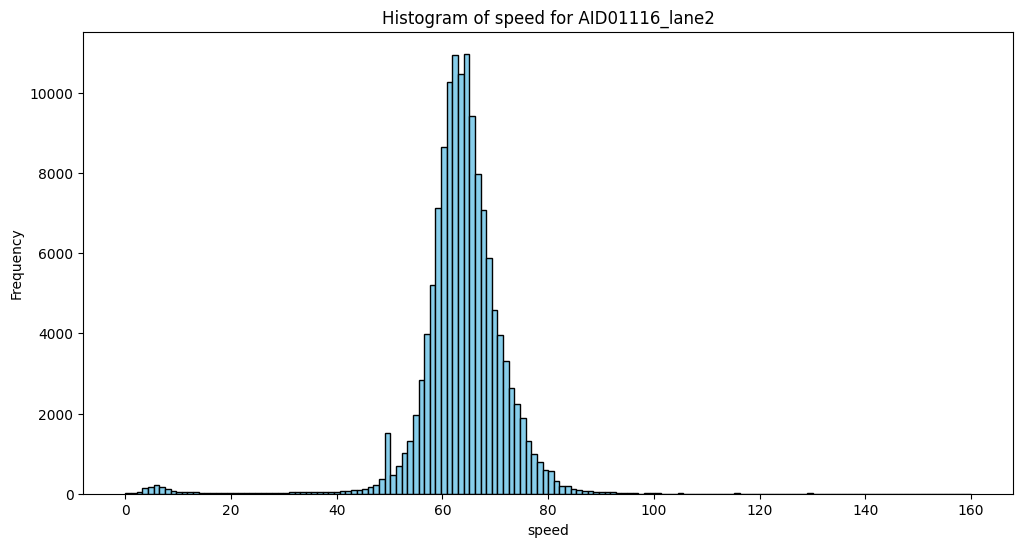

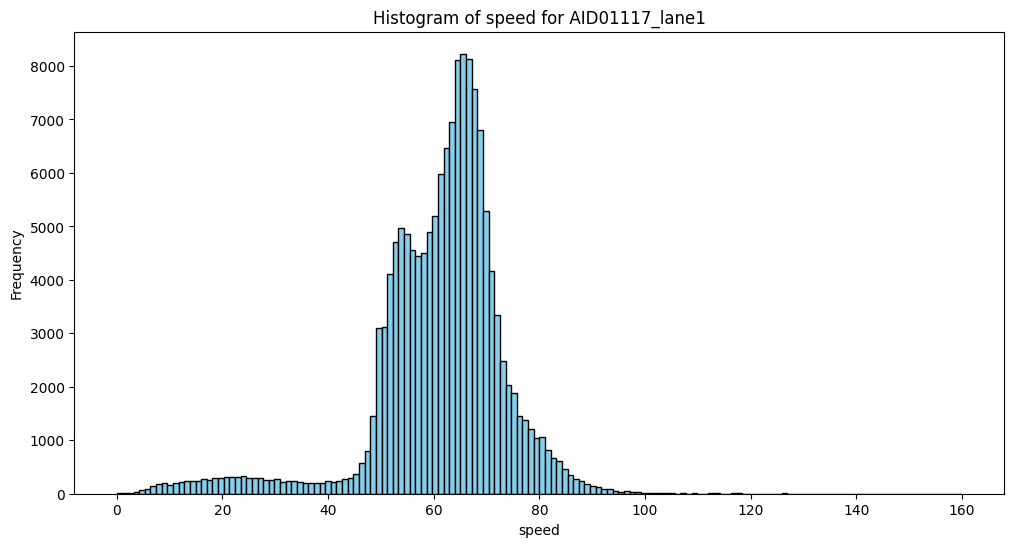

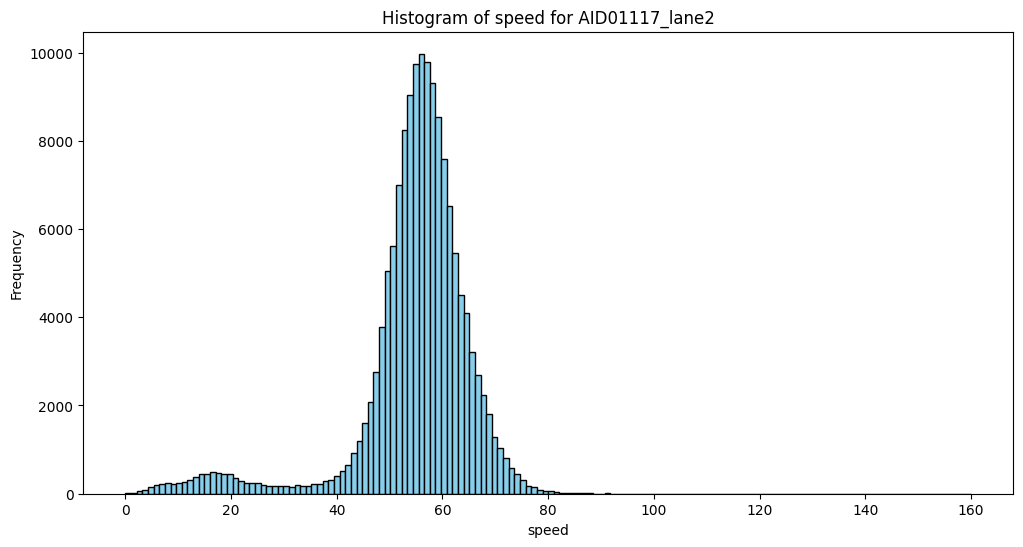

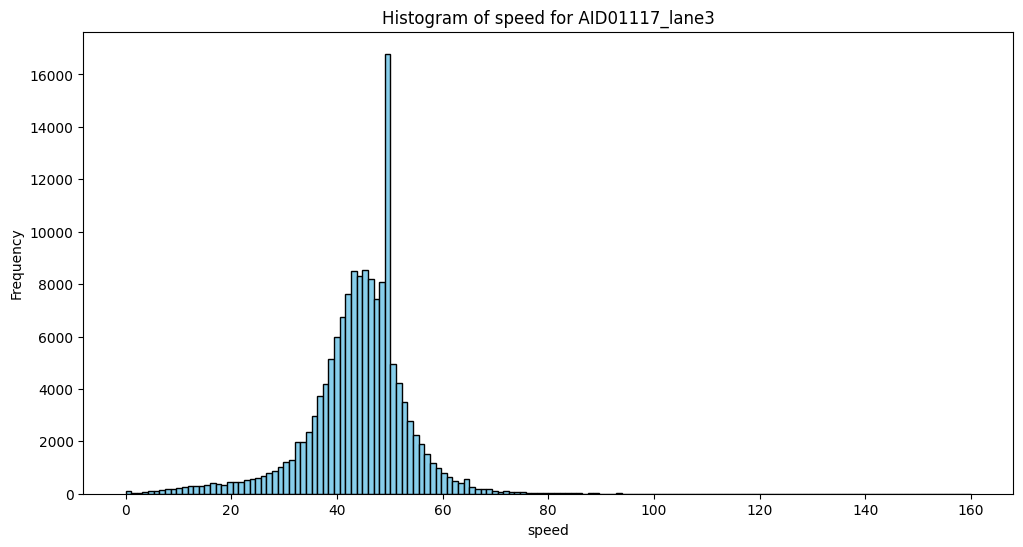

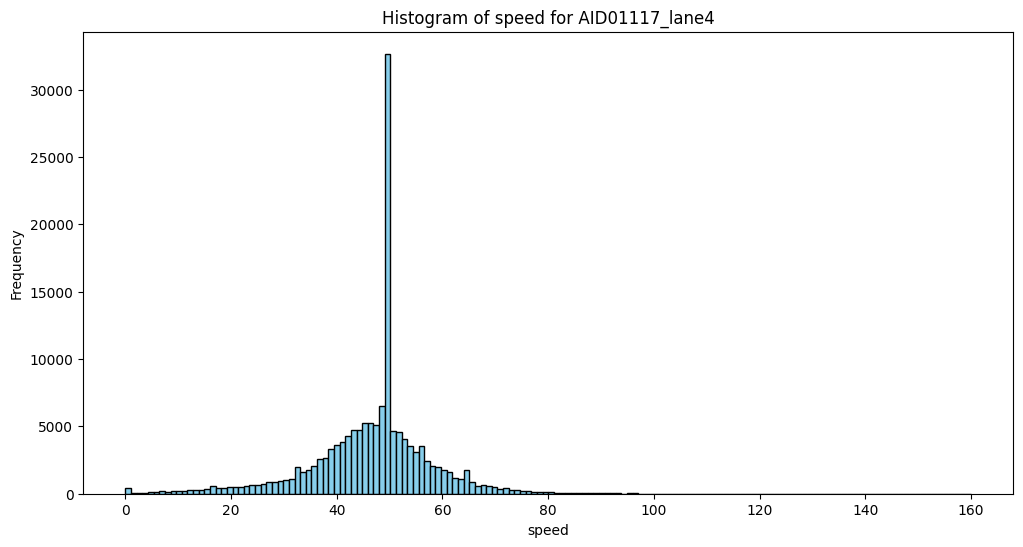

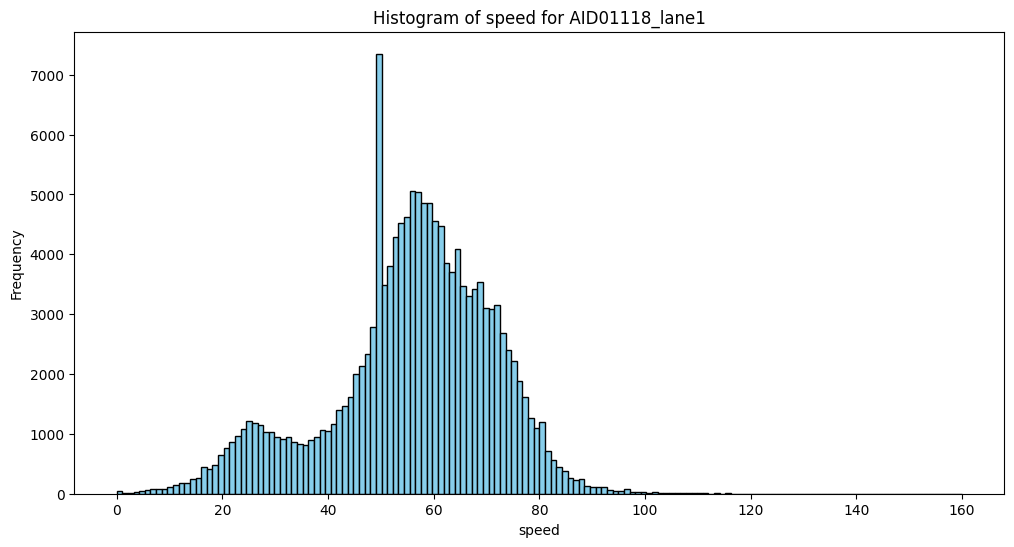

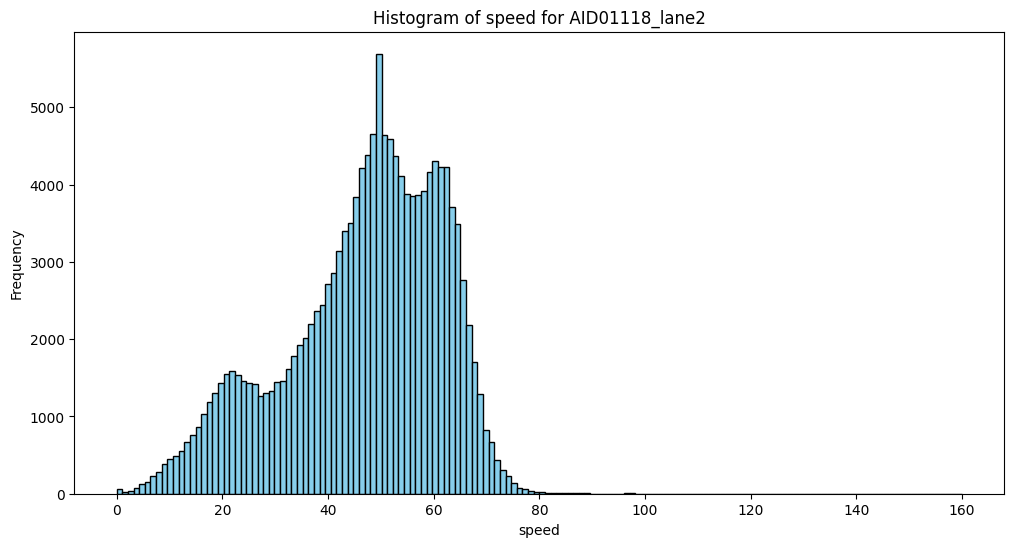

In [15]:
for i in range(50):
    plot_hist(dfs,dfs.columns[i],'speed')

In [16]:
d1 = dfs[pd.to_datetime('2022-05-01 00:02:00'):pd.to_datetime('2022-05-30 00:02:00')]
d2 = dfs[pd.to_datetime('2022-06-01 00:02:00'):pd.to_datetime('2022-06-30 00:02:00')]
d3 = dfs[pd.to_datetime('2022-07-01 00:02:00'):pd.to_datetime('2022-07-30 00:02:00')]
d4 = dfs[pd.to_datetime('2022-08-01 00:02:00'):pd.to_datetime('2022-08-30 00:02:00')]
d5 = dfs[pd.to_datetime('2022-09-01 00:02:00'):pd.to_datetime('2022-09-30 00:02:00')]
d6 = dfs[pd.to_datetime('2022-10-01 00:02:00'):pd.to_datetime('2022-10-30 00:02:00')]
d7 = dfs[pd.to_datetime('2022-11-01 00:02:00'):pd.to_datetime('2022-11-30 00:02:00')]

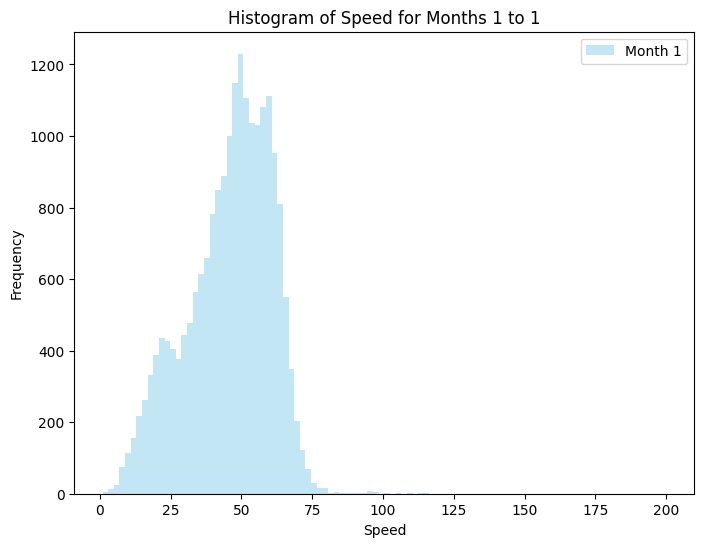

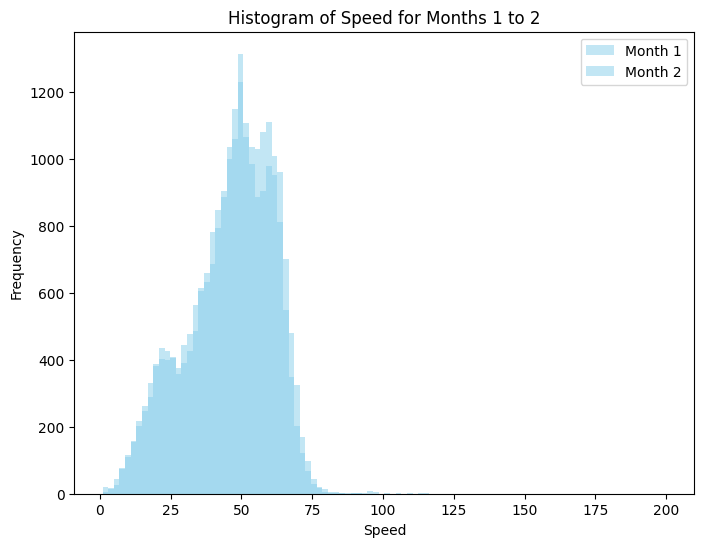

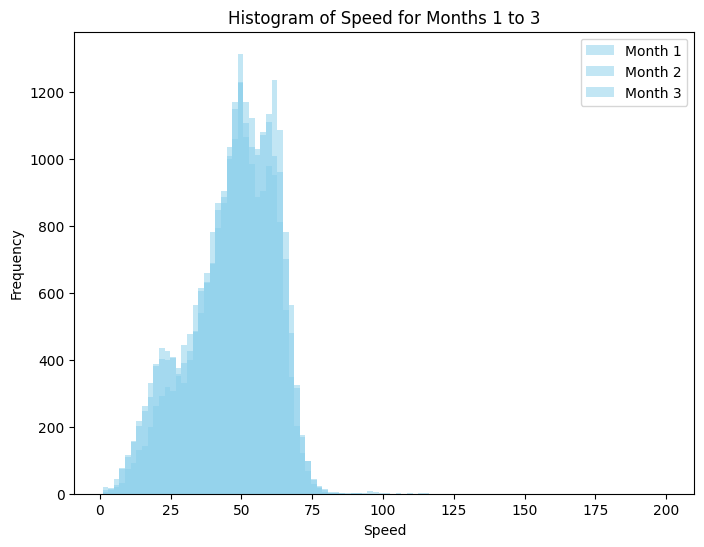

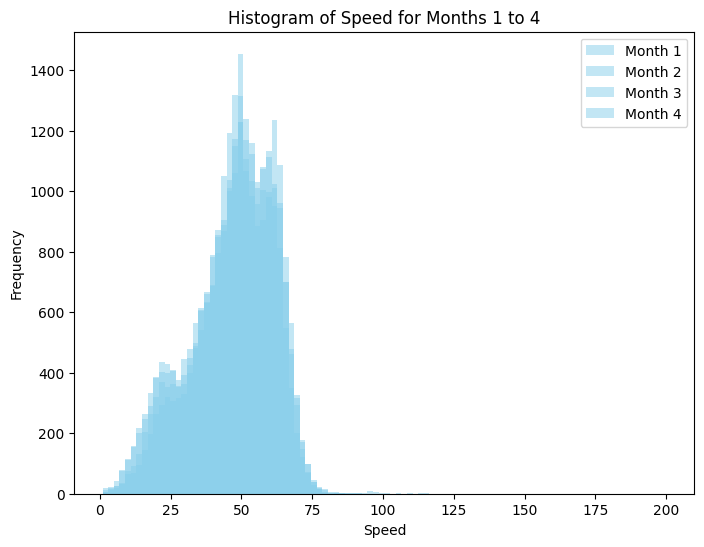

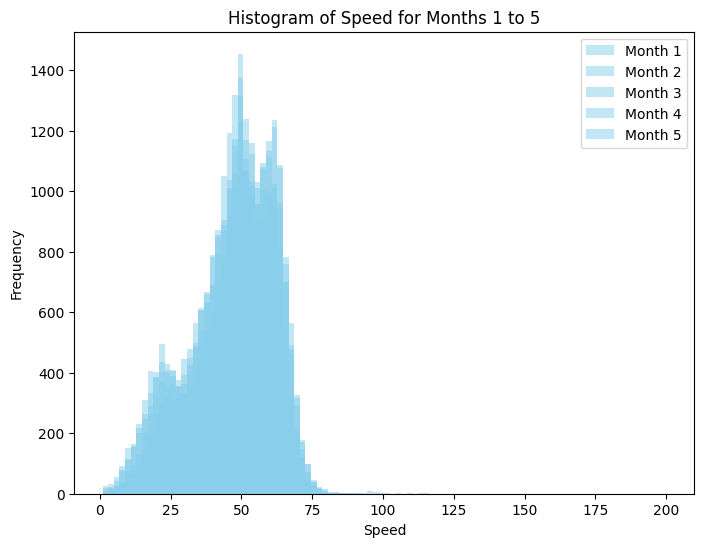

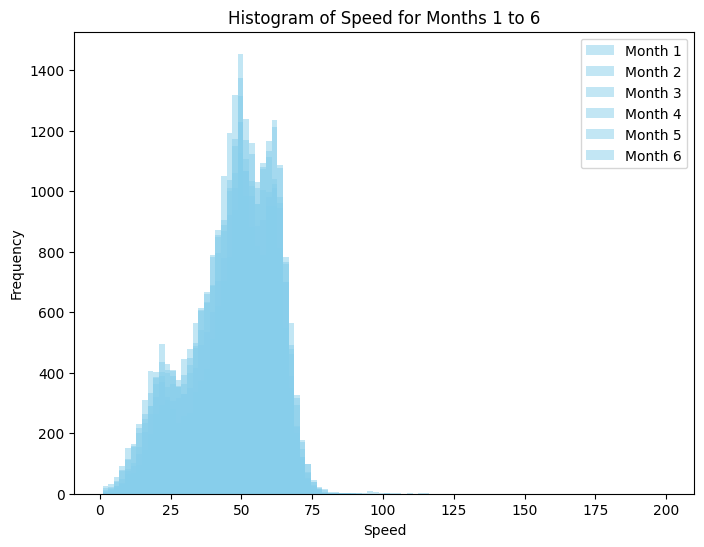

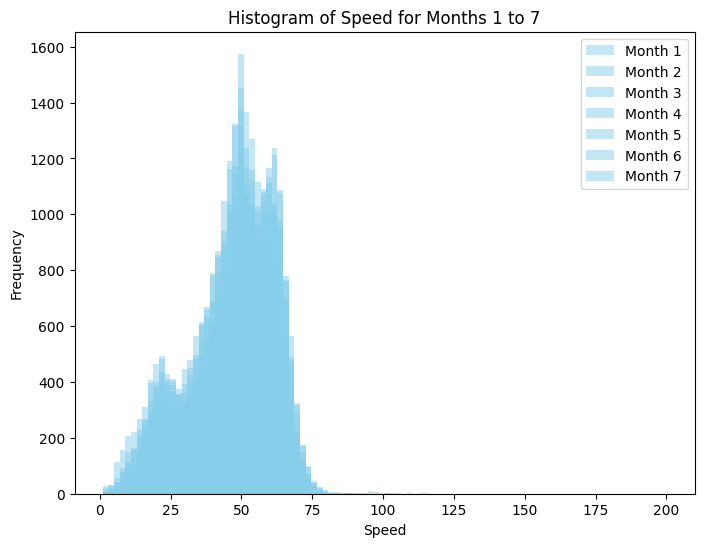

In [17]:
# Create a separate figure for each plot
for i in range(1, 8):
    # Create a new figure and axis object for each plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot the histogram for each month up to i
    for j in range(1, i + 1):
        # Get the corresponding DataFrame
        df = globals()[f'd{j}']
        
        # Plot the histogram for the 'speed' column of the DataFrame
        ax.hist(df['AID01118_lane2'], bins=100, alpha=0.5, label=f'Month {j}',color='skyblue', range=(1, 200))
    
    ax.set_xlabel('Speed')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Histogram of Speed for Months 1 to {i}')
    
    ax.legend()
    
    plt.show()

In [16]:
# # for detector 'AID01101_lane3'
# print(dfs['AID01101_lane3'])
# stl = STL(dfs['AID01101_lane3'])  # The 'seasonal' parameter specifies the length of the seasonal component
# result = stl.fit()

# # Plot the decomposition
# fig = result.plot()

# # Show the plot
# plt.show()

# Cross Detector Analysis

In [18]:
d1 = 'AID01108_lane1'
d2 = 'AID01109_lane1'
d3 = 'AID01110_lane1'

d = [d1,d2,d3]

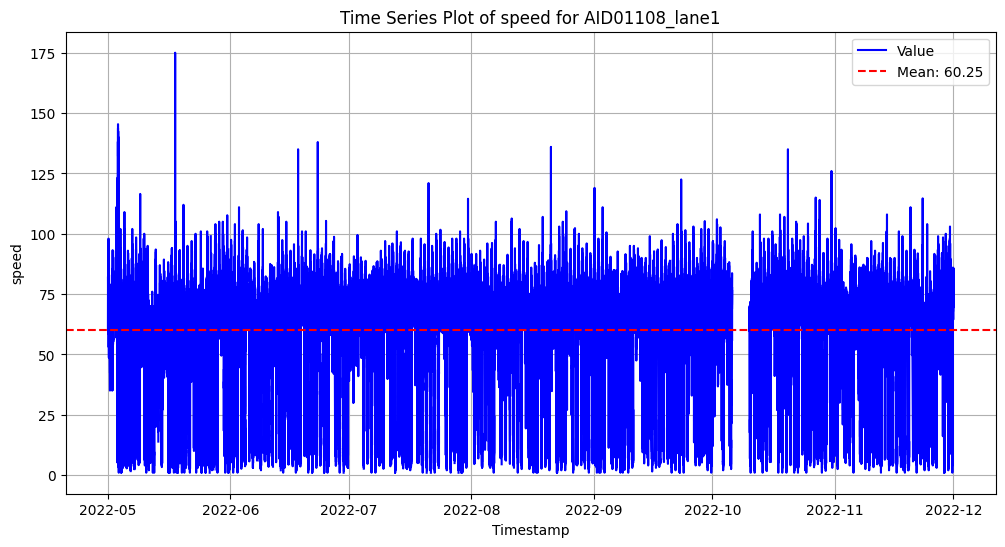

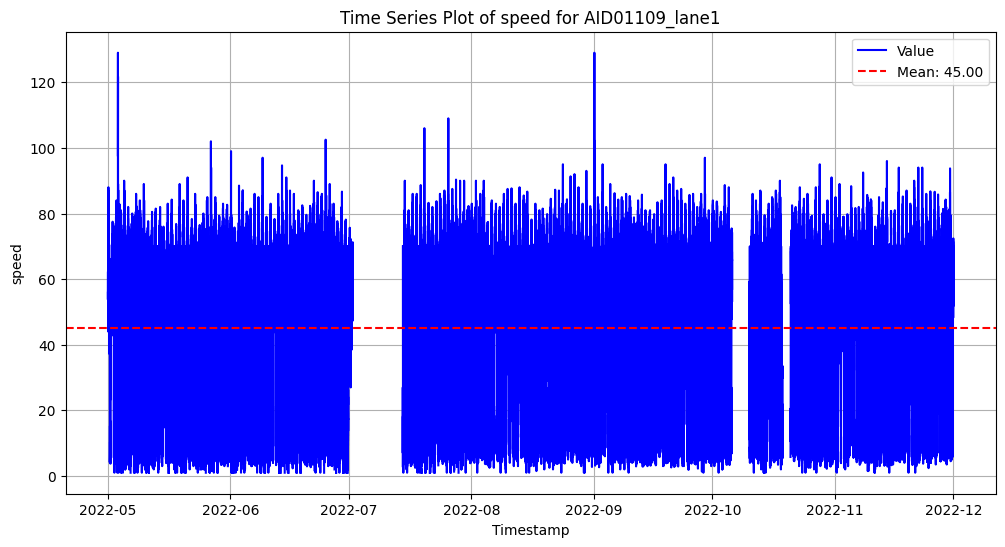

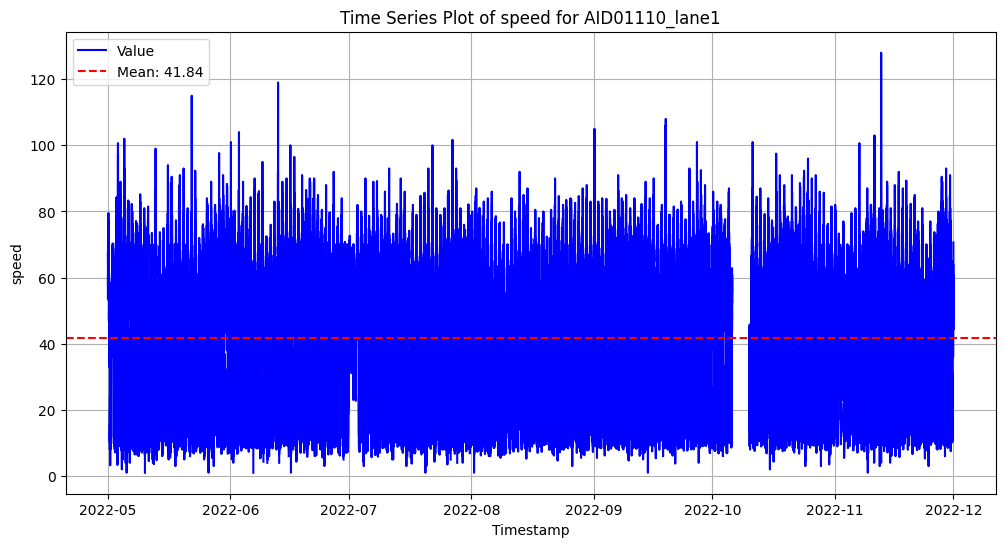

In [19]:
for i in d:
    plot_timeseries(dfs,i,'speed')

In [20]:
print('Speed Correlation')
print(dfs[d1].corr(dfs[d2]))
print(dfs[d1].corr(dfs[d3]))
print(dfs[d2].corr(dfs[d3]))

Speed Correlation
0.621892156807641
0.5909602802225299
0.8765052586372204


In [21]:
print('Flow Correlation')
print(dfv[d1].corr(dfv[d2]))
print(dfv[d1].corr(dfv[d3]))
print(dfv[d2].corr(dfv[d3]))

Flow Correlation
0.7503283849402667
0.620142790413154
0.5404732851885067


In [22]:
print('Density Correlation')
print(dfk[d1].corr(dfk[d2]))
print(dfk[d1].corr(dfk[d3]))
print(dfk[d2].corr(dfk[d3]))

Density Correlation
0.40920066766665875
0.5490496530728161
0.691054195968071


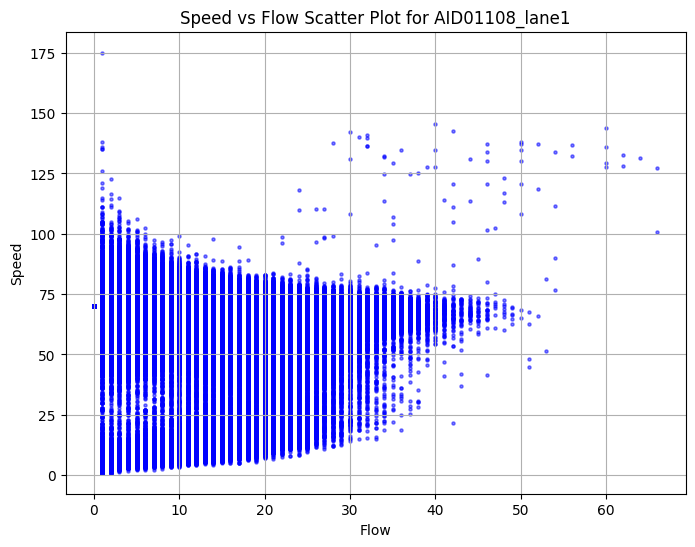

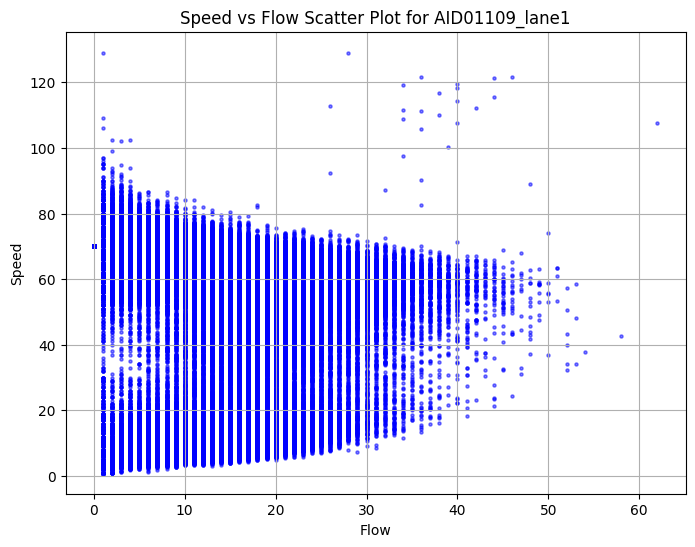

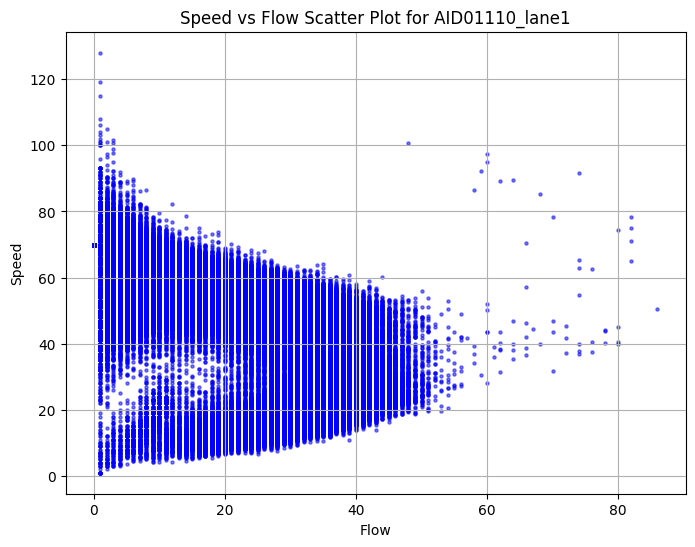

In [23]:
for i in d:
    plot_speed_vs_flow(dfs,dfv,i)

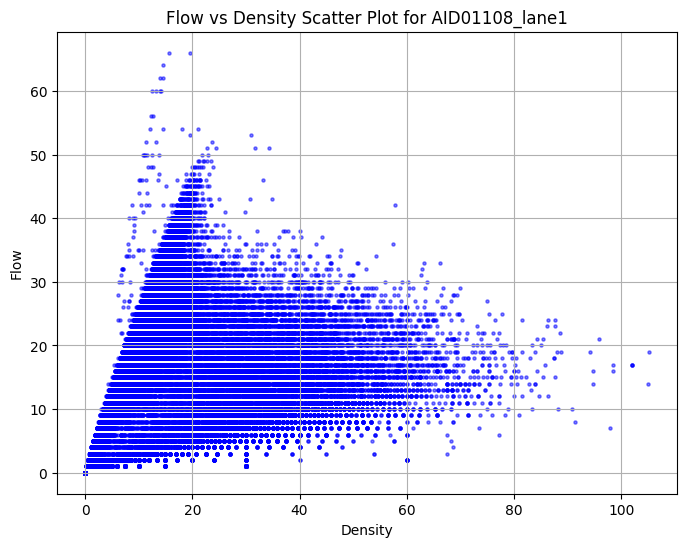

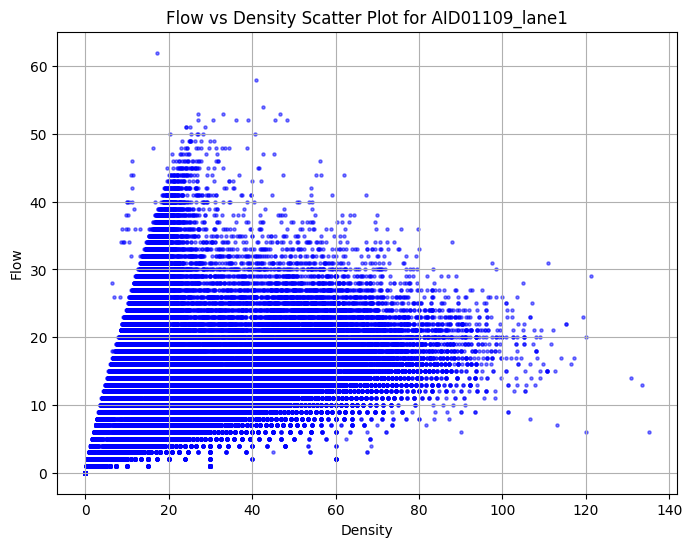

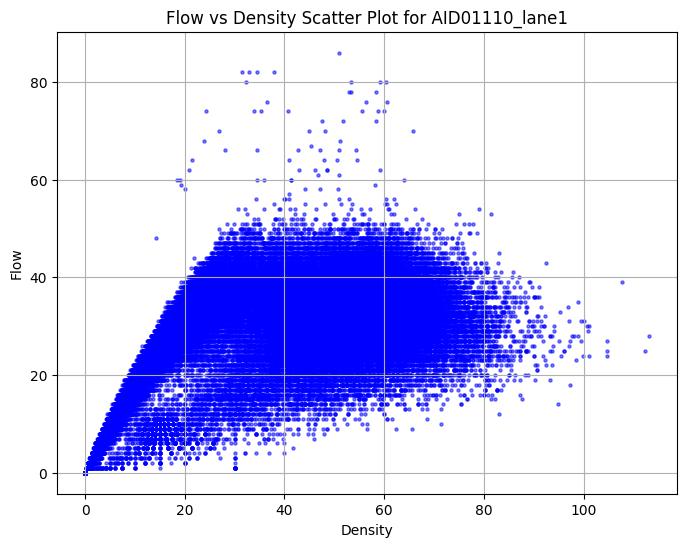

In [24]:
for i in d:
    plot_flow_vs_density(dfv,dfk,i)

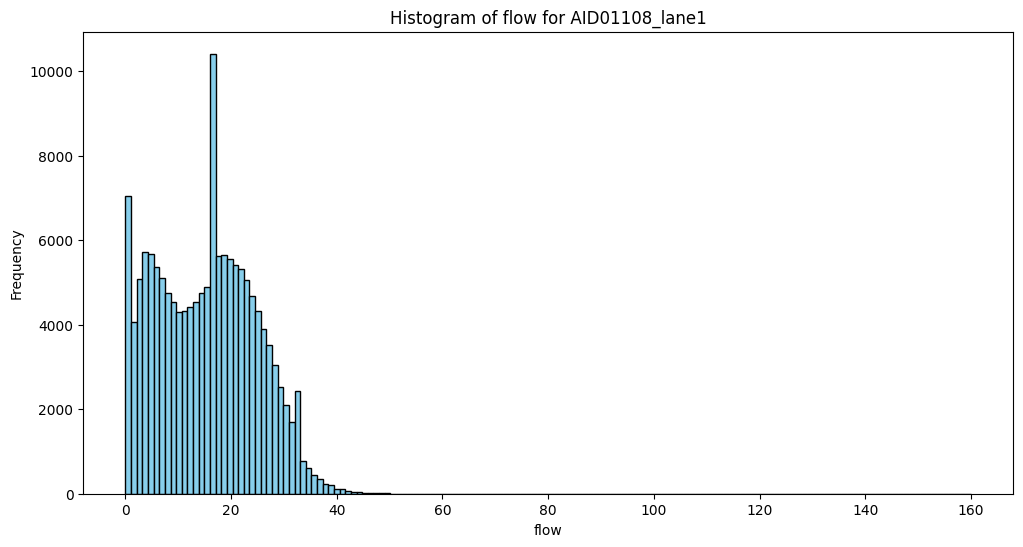

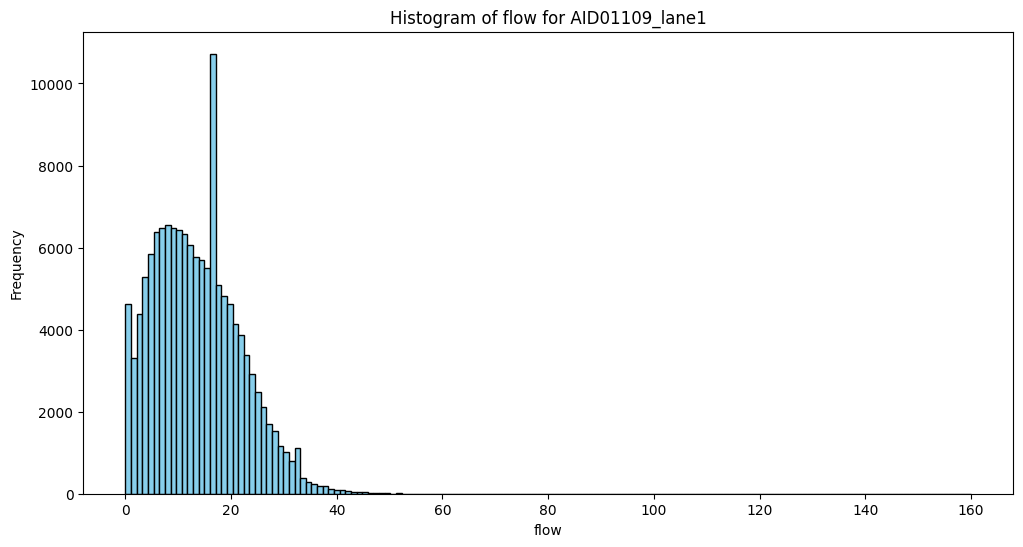

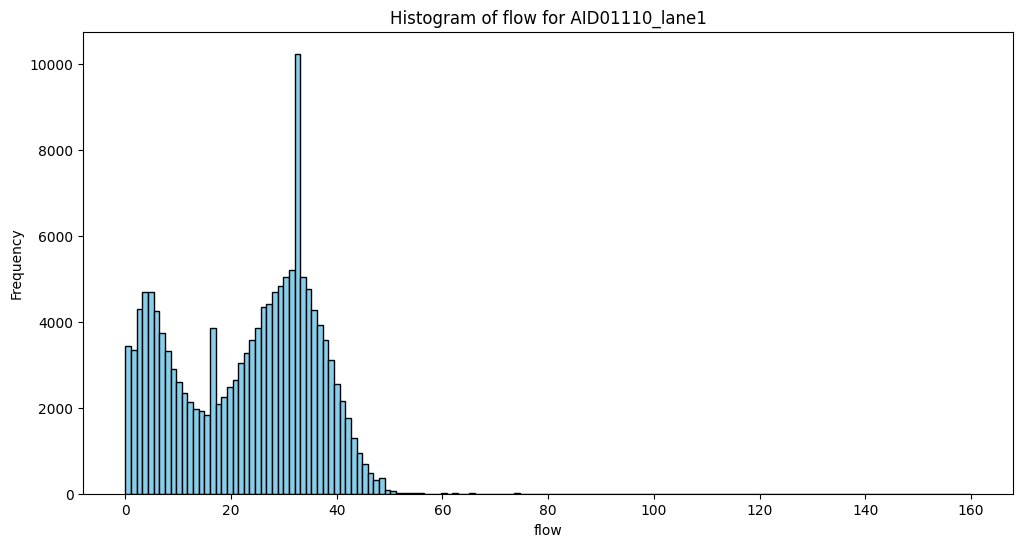

In [25]:
for i in d:
    plot_hist(dfv,i,'flow')

# Different Time Window

In [24]:
dfs_6min = dfs.resample('6min').mean()
dfv_6min = dfv.resample('6min').sum()
dfk_6min = dfk.resample('6min').mean()

dfs_12min = dfs.resample('12min').mean()
dfv_12min = dfv.resample('12min').sum()
dfk_12min = dfk.resample('12min').mean()

dfs_30min = dfs.resample('30min').mean()
dfv_30min = dfv.resample('30min').sum()
dfk_30min = dfk.resample('30min').mean()

dfs_1h = dfs.resample('1h').mean()
dfv_1h = dfv.resample('1h').sum()
dfk_1h = dfk.resample('1h').mean()

dfs_3h = dfs.resample('3h').mean()
dfv_3h = dfv.resample('3h').sum()
dfk_3h = dfk.resample('3h').mean()

dfs_12h = dfs.resample('12h').mean()
dfv_12h = dfv.resample('12h').sum()
dfk_12h = dfk.resample('12h').mean()

dfs_1d = dfs.resample('1d').mean()
dfv_1d = dfv.resample('1d').sum()
dfk_1d = dfk.resample('1d').mean()

In [25]:
def plot_s_f(ax, speed_df, flow_df, column_name):
    ax.scatter(flow_df[column_name], speed_df[column_name], color='blue', alpha=0.5, s=5)  # Plot the scatter plot
    ax.set_title('Speed vs Flow for ' + column_name)  
    ax.set_xlabel('Flow')  
    ax.set_ylabel('Speed')  
    ax.grid(True) 

def plot_s_d(ax, speed_df, density_df, column_name):
    ax.scatter(density_df[column_name], speed_df[column_name], color='blue', alpha=0.5, s=5)  # Plot the scatter plot
    ax.set_title('Speed vs Density for '+column_name) 
    ax.set_xlabel('Density')  
    ax.set_ylabel('Speed') 
    ax.grid(True)  

def plot_f_d(ax, flow_df, density_df, column_name):
    ax.scatter(density_df[column_name], flow_df[column_name], color='blue', alpha=0.5, s=5)  # Plot the scatter plot
    ax.set_title('Flow vs Density for '+column_name)  
    ax.set_xlabel('Density') 
    ax.set_ylabel('Flow')  
    ax.grid(True)  

def plot_histogram(ax, df, detector, type):
    ax.hist(df[detector], bins=150, range=(0, 160), edgecolor='blue', color='skyblue')
    ax.set_title('Histogram of '+ type + ' for ' + detector)
    ax.set_xlabel(type)
    ax.set_ylabel('Frequency')

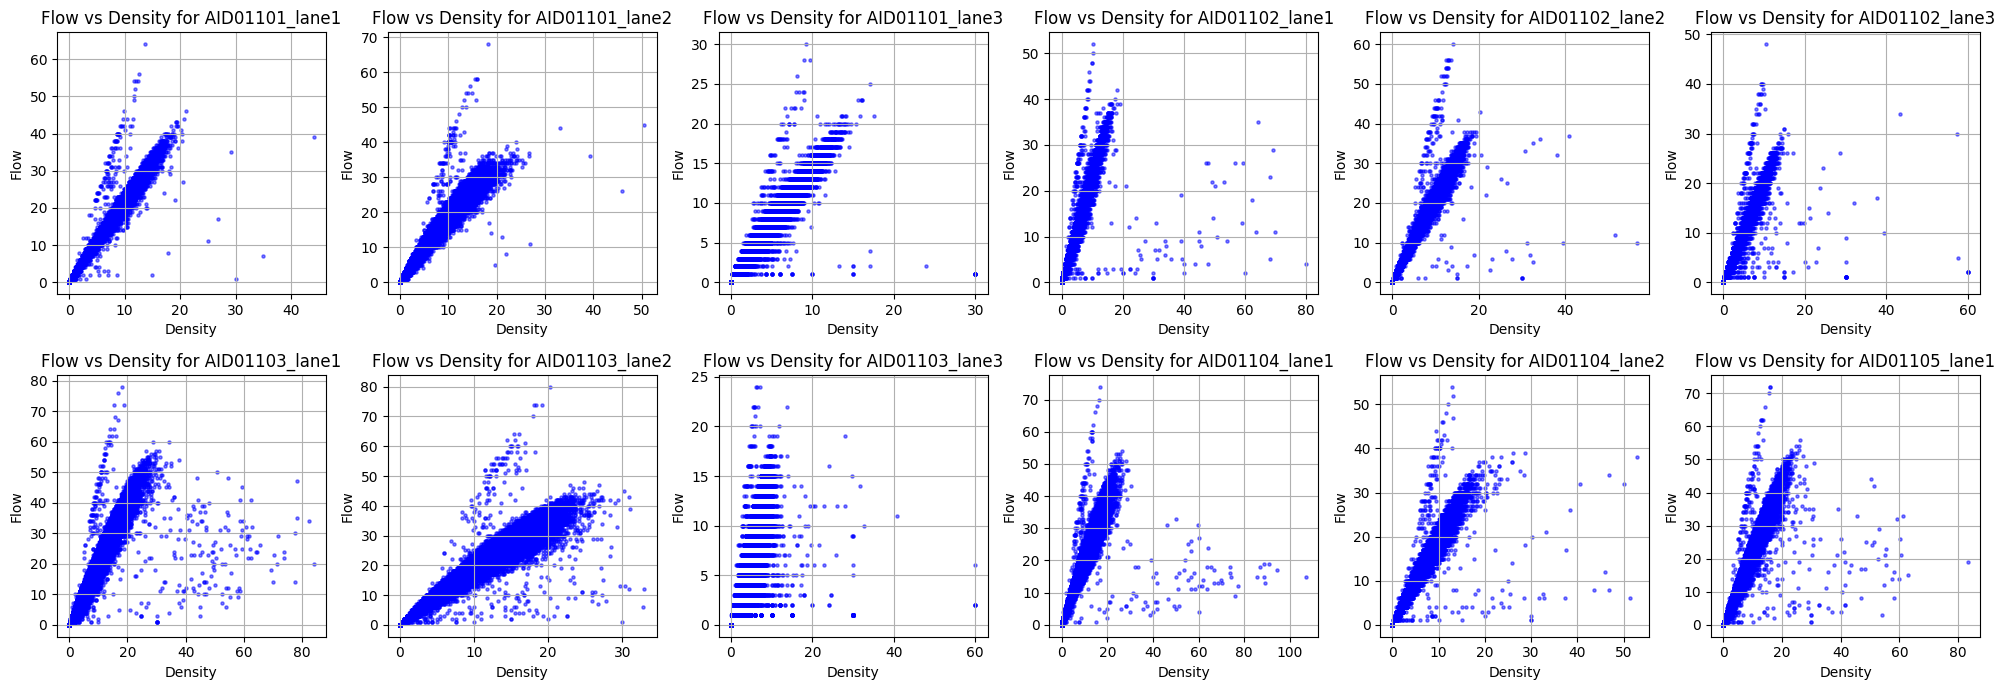

In [26]:
fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(20, 7))

for i, ax in enumerate(axes.flat):
    plot_f_d(ax, dfv, dfk, dfv.columns[i])

plt.tight_layout()
plt.show()

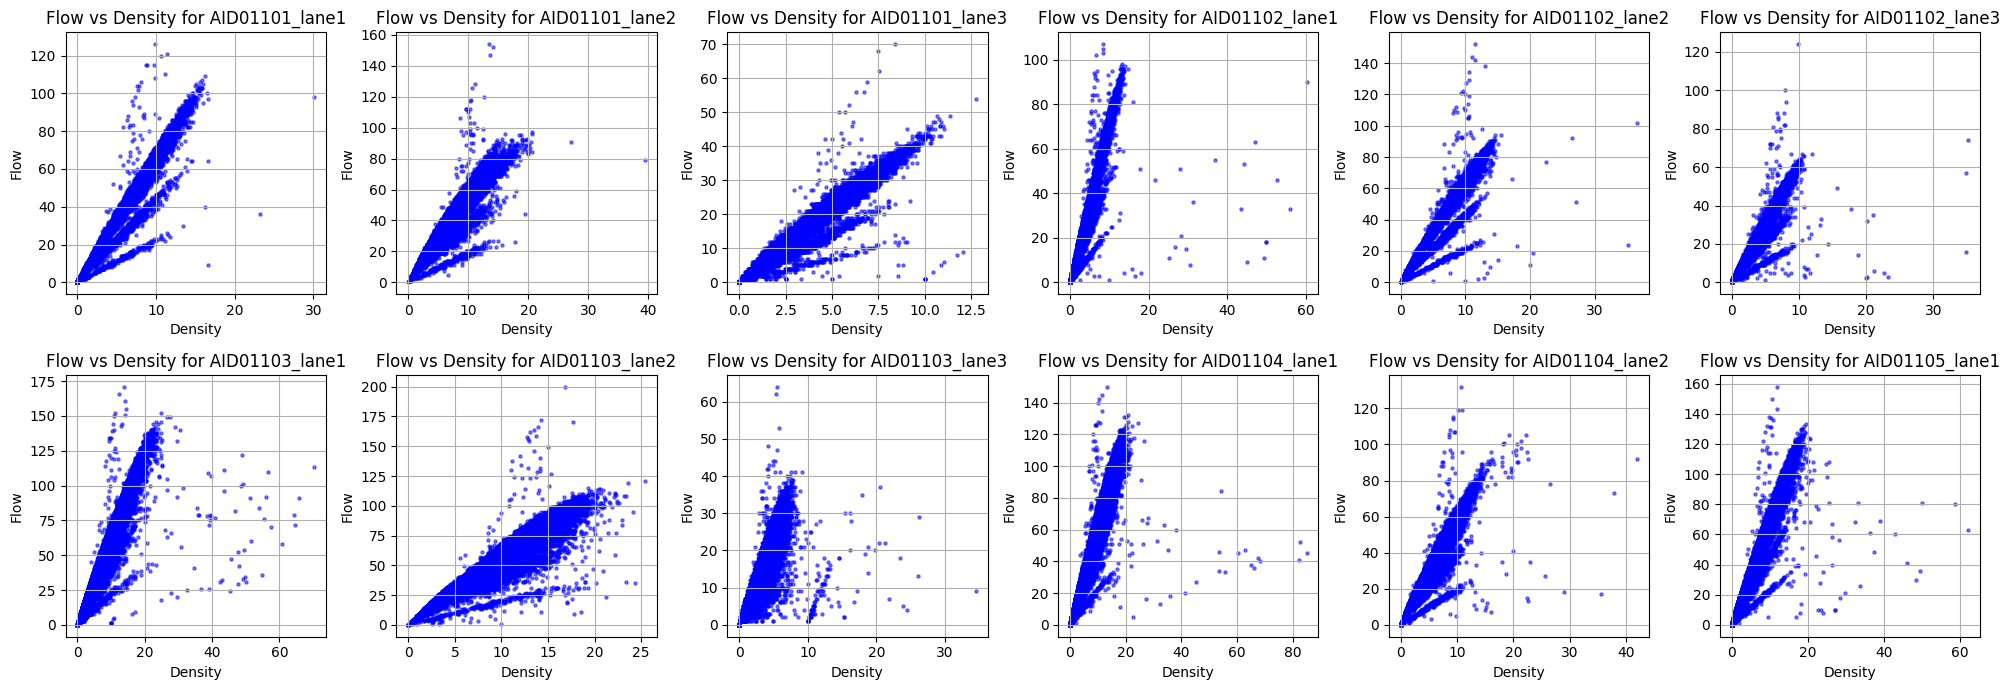

In [27]:
fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(20, 7))

for i, ax in enumerate(axes.flat):
    plot_f_d(ax, dfv_6min, dfk_6min, dfv.columns[i])

plt.tight_layout()
plt.show()

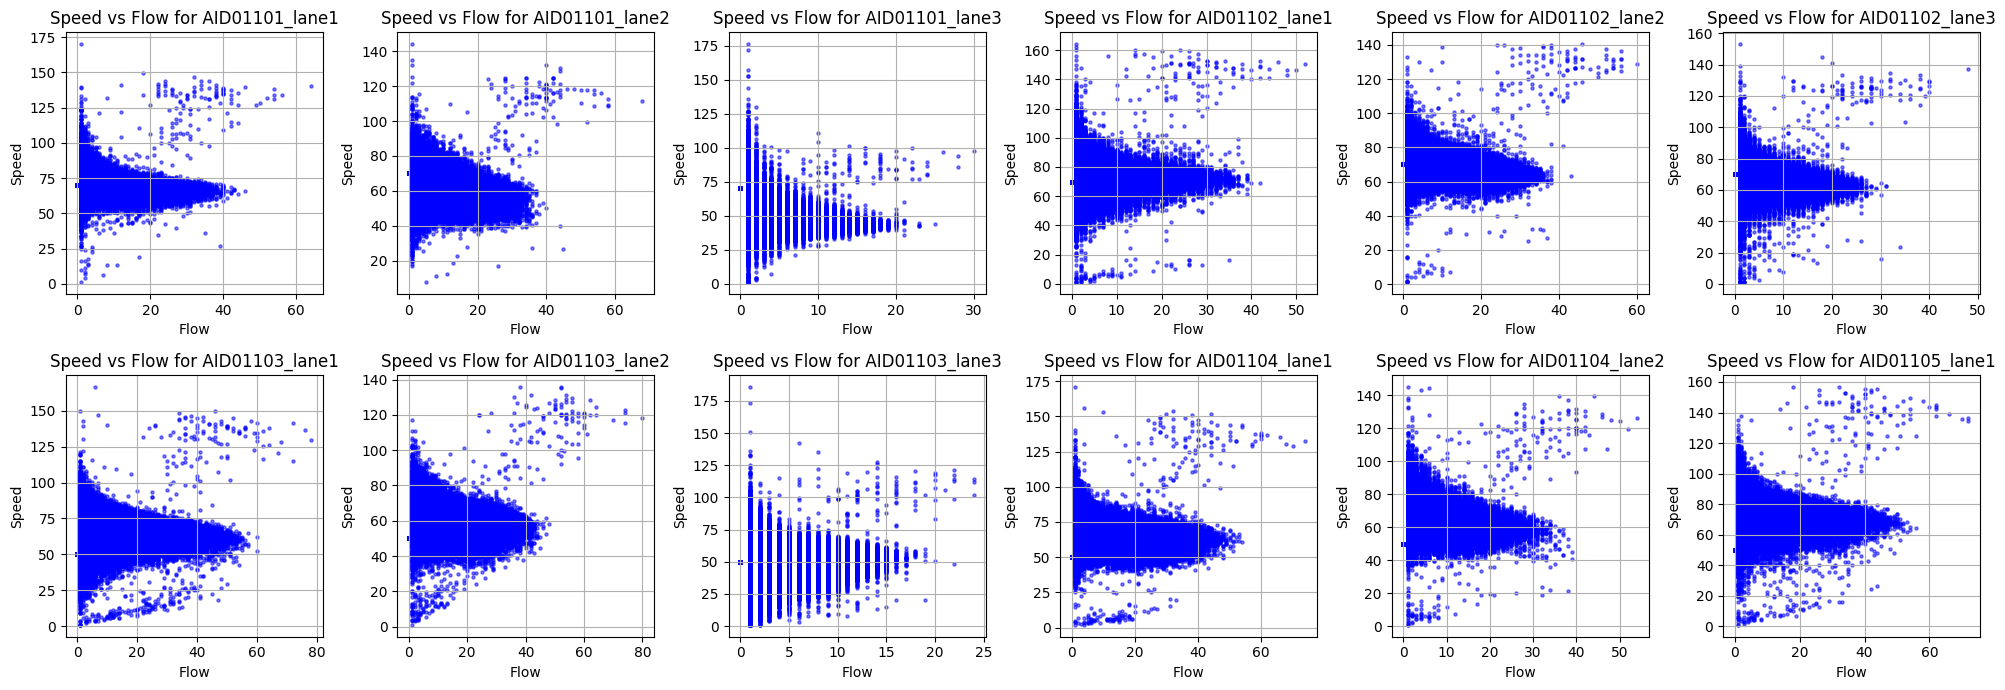

In [28]:
fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(20, 7))

for i, ax in enumerate(axes.flat):
    plot_s_f(ax, dfs, dfv, dfv.columns[i])

plt.tight_layout()
plt.show()

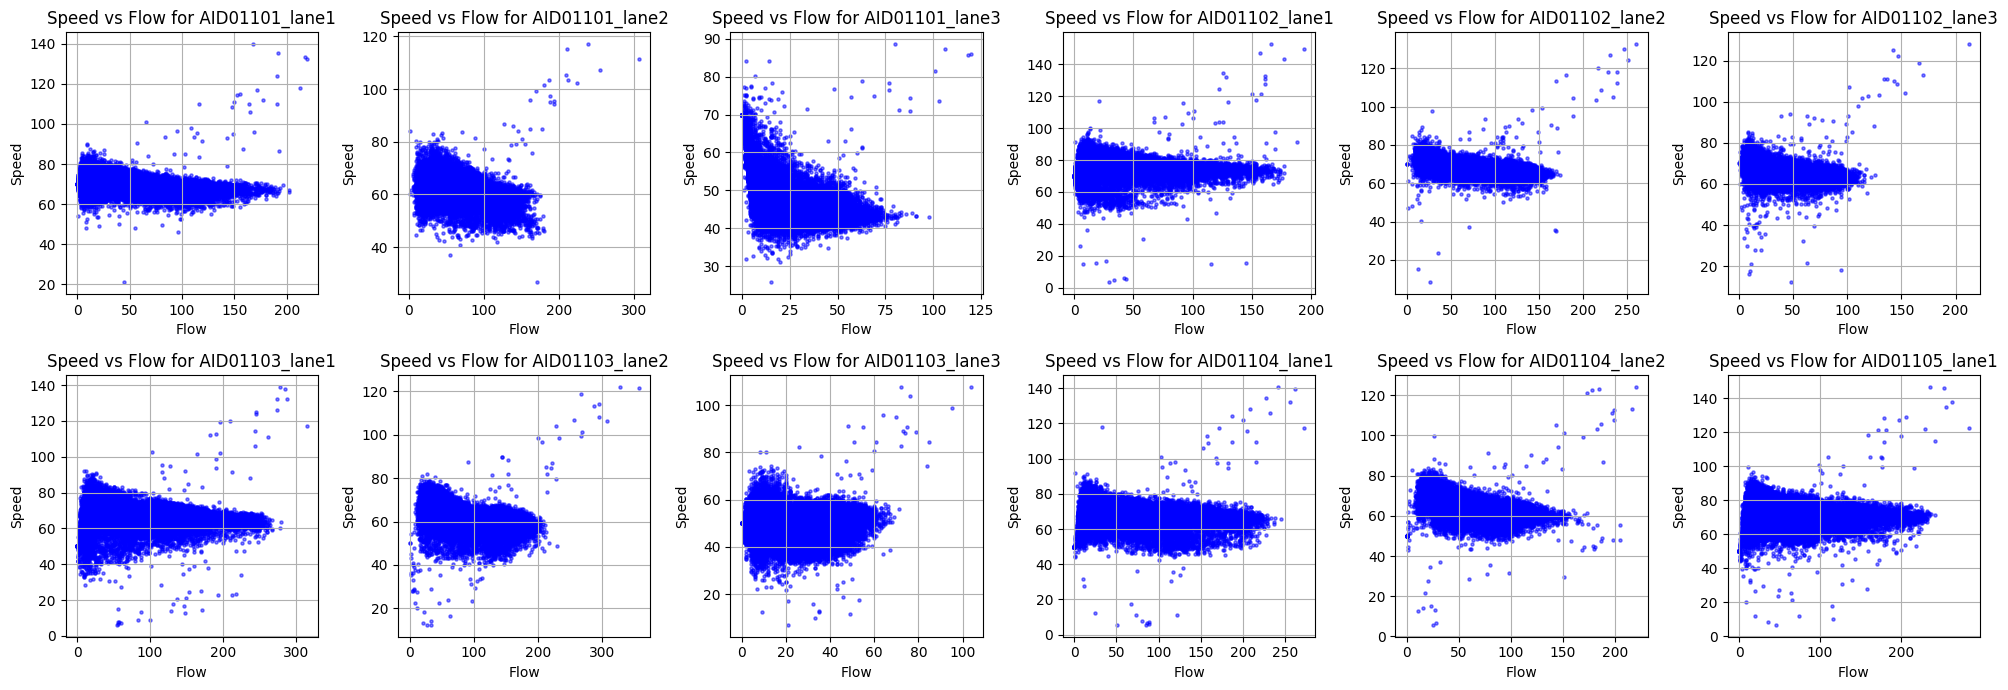

In [29]:
fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(20, 7))

for i, ax in enumerate(axes.flat):
    plot_s_f(ax, dfs_12min, dfv_12min, dfv.columns[i])

plt.tight_layout()
plt.show()

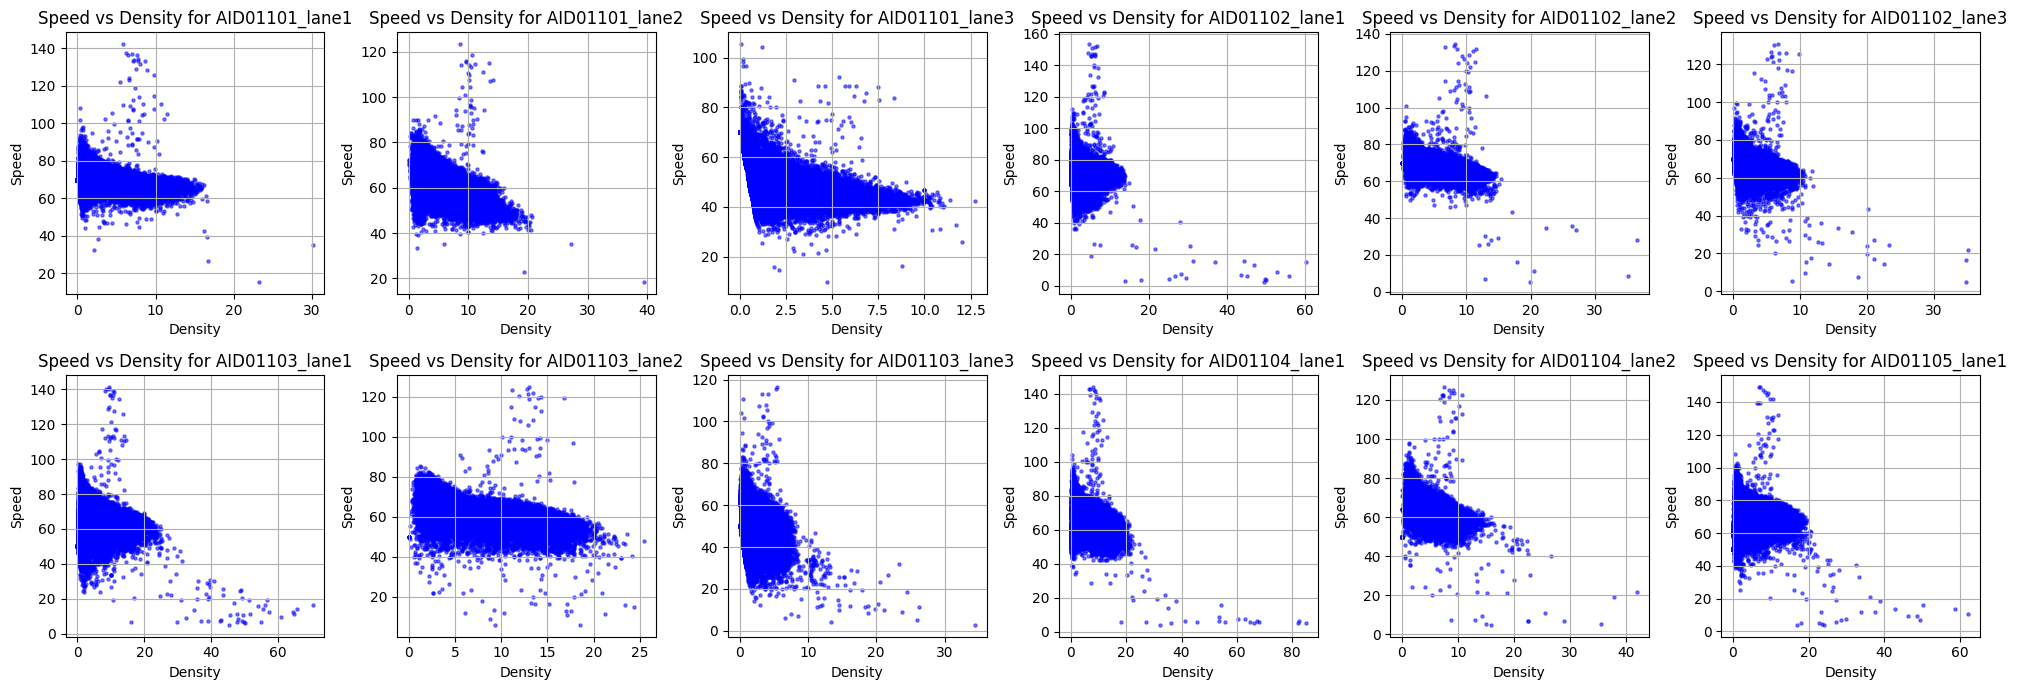

In [30]:
fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(20, 7))

for i, ax in enumerate(axes.flat):
    plot_s_d(ax, dfs_6min, dfk_6min, dfv.columns[i])

plt.tight_layout()
plt.show()

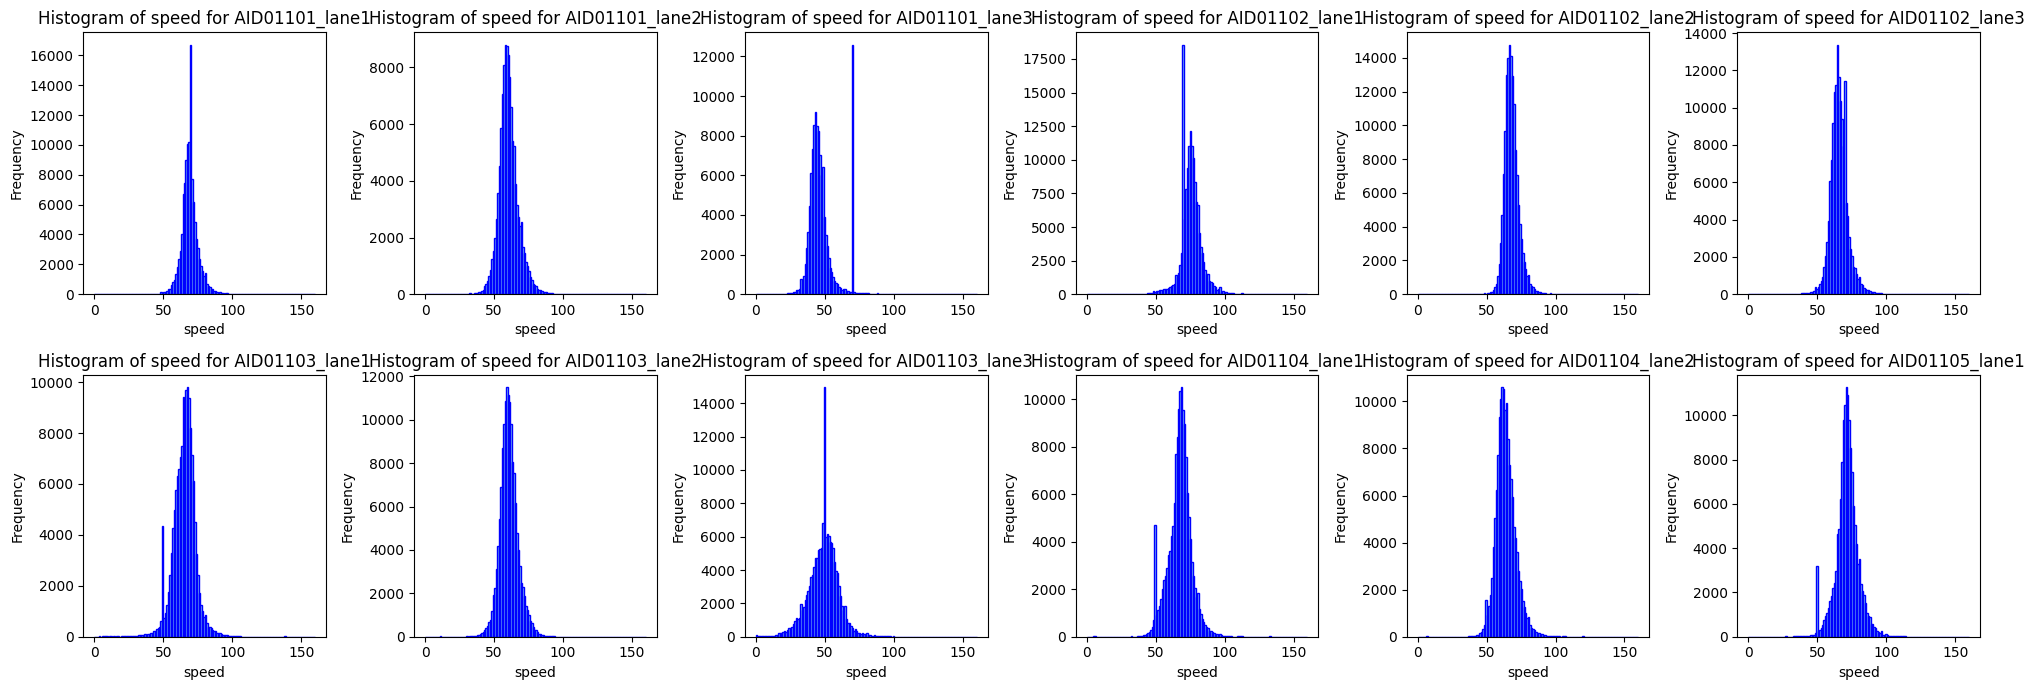

In [31]:
fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(20, 7))
for i, ax in enumerate(axes.flat):
    plot_histogram(ax, dfs, dfs.columns[i], 'speed')

plt.tight_layout()
plt.show()

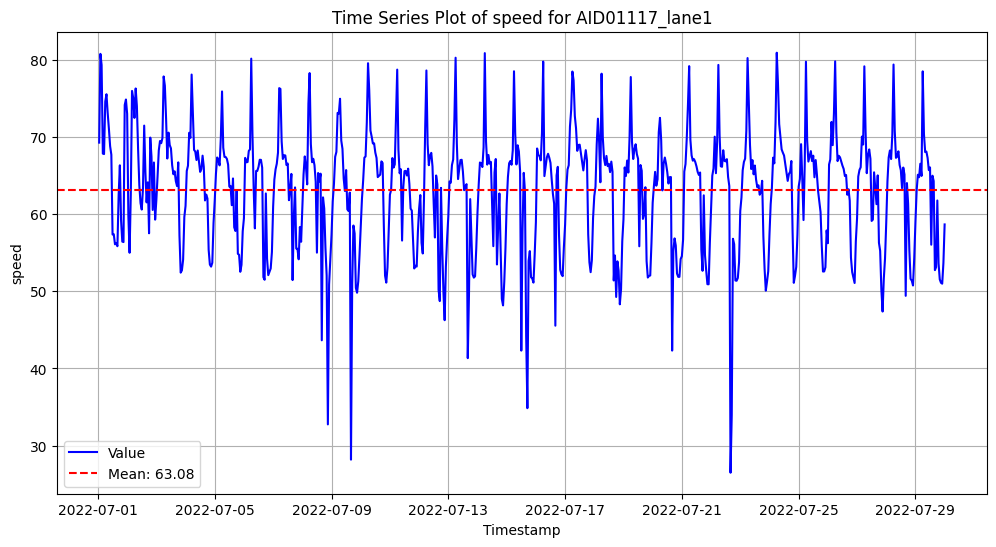

In [32]:
start_date = pd.to_datetime('2022-07-01 00:02:00')
end_date = pd.to_datetime('2022-07-30 00:02:00')
data = dfs_1h[start_date:end_date]

plot_timeseries(data,'AID01117_lane1','speed')

In [26]:
# # for detector 'AID01101_lane3'
# arr = data['AID01117_lane1'].dropna()
# print(arr)

# stl = STL(arr,seasonal=25, period = 21 )  # The 'seasonal' parameter specifies the length of the seasonal component
# result = stl.fit()

# # Plot the decomposition
# fig = result.plot()

# # Show the plot
# plt.show()